
# Aroma-aware model-based design of experiments

This notebook extends the fermentation DOE workflow with an aroma mass-balance layer. The target compounds are:

- ethyl acetate;
- isoamyl acetate;
- ethyl octanoate.

The purpose is not to replace the existing fermentation model. The purpose is to add a measurement model for volatile aroma accumulation and gas-phase loss so that future experiments can identify aroma synthesis parameters without confounding them with physical stripping.

The implementation follows three modeling decisions:

1. Use the current reduced fermentation model as the process backbone.
2. Fix most gas-liquid partition parameters from literature-scale equilibrium information.
3. Estimate aroma synthesis parameters first; leave partition correction factors optional and strongly constrained.



## 1. Experimental information available

For new laboratory fermentations, the available measurements are assumed to be:

- time series of liquid-phase aroma concentration in the fermentation medium;
- online CO2 flow or accumulated CO2;
- one final condensate/trap measurement for each target aroma;
- the same process measurements already considered in the fermentation DOE: biomass, dead biomass, nitrogen, sugars, ethanol, temperature, and manipulated pulses.

The important limitation is that the condensate is not time resolved. A single final condensate sample closes the final gas-loss balance, but it does not reveal when the loss occurred. This is why the gas-liquid equilibrium model must be fixed or treated with a strong prior.



## 2. Literature roles

### Mouret-style gas-liquid mass balance

For each aroma species \(i\), Mouret's key idea is that the total biological production is the sum of what remains in the liquid and what escaped through the gas stream:

$$
P_i(t) = A_{L,i}(t) + A_{loss,i}(t)
$$

where \(A_{L,i}\) is the liquid concentration and \(A_{loss,i}\) is the cumulative gas-phase loss expressed per liquid volume of must.

The exhaust loss is driven by the CO2 flow and the liquid-gas partition relationship:

$$
\frac{d A_{loss,i}}{dt} = Q_{CO_2}(t) C_{G,i}(t)
$$

with:

$$
C_{G,i}(t) = K_i(T,E,\mathbf{x}) A_{L,i}(t)
$$

Therefore:

$$
\frac{d A_{loss,i}}{dt} = Q_{CO_2}(t) K_i(T,E,\mathbf{x}) A_{L,i}(t)
$$

### Henriques-style synthesis layer

Henriques et al. use a dFBA framework where external product formation is constrained through sugar transport and phase-dependent metabolic behavior. In this first implementation, we use a reduced kinetic analogue rather than a full genome-scale dFBA problem:

$$
\frac{d P_i}{dt} = r_{syn,i}(t)
$$

with synthesis proportional to sugar uptake and modulated by nitrogen limitation.

### Luna/UNIFAC equilibrium layer

Luna et al. illustrate how vapor-liquid equilibrium can be closed using activity coefficients, for example through UNIFAC. In this implementation, the detailed UNIFAC calculation is represented by a fixed function:

$$
K_i(T,E,\mathbf{x})
$$

The runner now computes this function offline with the Python packages `thermo` and `chemicals`, using original UNIFAC group assignments where available. The resulting UNIFAC values are then fitted to a smooth log-linear surrogate used inside Pyomo.



## 3. Aroma state model

For each aroma species \(i\), the model introduces three quantities:

$$
A_{L,i}(t) \quad \text{liquid aroma concentration}
$$

$$
A_{loss,i}(t) \quad \text{cumulative aroma stripped by gas}
$$

$$
A_{cond,i}(t_f) \quad \text{final measured condensate/trap amount}
$$

The dynamic balances are:

$$
\frac{d A_{L,i}}{dt} = r_{syn,i}(t) - r_{loss,i}(t)
$$

$$
\frac{d A_{loss,i}}{dt} = r_{loss,i}(t)
$$

The final condensate observation is modeled as:

$$
A_{cond,i}(t_f) = \eta_i A_{loss,i}(t_f)
$$

where \(\eta_i\) is the trap efficiency. In the default DOE run, \(\eta_i\) is fixed. This is necessary because a single terminal condensate sample cannot independently identify \(\eta_i\), a gas-liquid correction factor, and synthesis parameters.



## 4. Synthesis model

The sugar uptake rate is inherited from the fermentation model:

$$
q_S(t) = q_G(t) + q_F(t)
$$

where \(q_G\) and \(q_F\) are positive glucose and fructose uptake rates.

A smooth nitrogen-phase indicator is used:

$$
\phi_N(t) = \frac{N(t)}{N(t) + K_N}
$$

The aroma synthesis rate is:

$$
 r_{syn,i}(t) = \left[k_{i,g}\phi_N(t) + k_{i,s}\left(1 - \phi_N(t)\right)\right] q_S(t)
$$

where:

- \(k_{i,g}\) is the synthesis yield in the nitrogen-rich or growth-associated phase;
- \(k_{i,s}\) is the synthesis yield in the nitrogen-limited or stationary-like phase.

Because isoamyl alcohol is not measured, isoamyl acetate is modeled with the same empirical phase-dependent synthesis form. A precursor-threshold model would be structurally weak without isoamyl alcohol observations.



## 5. Gas-loss model

The CO2 mass production rate from the fermentation model is converted to a volumetric gas flow approximation:

$$
Q_{CO_2}(t) = \frac{22.414}{44.01} r_{CO_2}(t)
$$

where \(r_{CO_2}\) is expressed as grams of CO2 per liter of must per hour.

The UNIFAC-derived liquid-gas equilibrium surrogate used inside Pyomo is:

$$
K_i(T,E) = K_{i,20}\exp\left[a_{T,i}(T - 20) + a_{E,i}(E - 50)\right]
$$

The loss rate is:

$$
 r_{loss,i}(t) = \alpha_i K_i(T,E) Q_{CO_2}(t) A_{L,i}(t)
$$

In the default run:

$$
\alpha_i = 1
$$

and \(\alpha_i\) is not estimated. It can be enabled later for sensitivity analysis, but it should not be released unless trap efficiency is independently calibrated or condensate measurements become time-resolved. The default partition mode is `water_ethanol_total_sugar_as_glucose`: water, ethanol, and total residual sugar are included, with residual sugar represented by the glucose UNIFAC assignment because a direct DDBST original-UNIFAC assignment for fructose was not available in the installed package.


In [1]:

from pathlib import Path
import sys
import subprocess

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name != "pyomo-doe":
    ROOT = ROOT.parent
FERM = ROOT / "fermentation_model"
RESULTS = FERM / "results" / "aroma_campaign_doe"
SCRIPT = FERM / "run_aroma_campaign_doe.py"

sys.path.insert(0, str(FERM))
import run_aroma_campaign_doe as aroma_doe

print("Runner:", SCRIPT)
print("Results:", RESULTS)


Runner: C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\pyomo-doe\fermentation_model\run_aroma_campaign_doe.py
Results: C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\pyomo-doe\fermentation_model\results\aroma_campaign_doe



## 6. Pyomo DoE workflow

The runner builds a labeled Pyomo model with aroma synthesis parameters as unknown parameters. The local Fisher information matrix is computed using:

```python
DesignOfExperiments(...).compute_FIM(method="sequential")
```

A weak literature prior is included as a diagonal FIM:

$$
F_{prior} = \frac{1}{CV_{prior}^2} I
$$

The candidate score combines D-optimality, worst-parameter protection, and conditioning:

$$
\Phi = \log\det(F) + 10\overline{R} + 20R_{worst} + 2\log\left(\frac{\lambda_{min}}{\lambda_{max}}\right)
$$

where \(R\) is the variance reduction relative to the literature prior.


In [2]:

RUN_LONG_AROMA_DOE = False

if RUN_LONG_AROMA_DOE:
    subprocess.run([sys.executable, str(SCRIPT), "--campaign-size", "9"], cwd=str(ROOT), check=True)

selected = pd.read_csv(RESULTS / "aroma_campaign_selected.csv")
ranking = pd.read_csv(RESULTS / "aroma_candidate_ranking.csv")
protocols = pd.read_csv(RESULTS / "aroma_campaign_protocols.csv")
pulses = pd.read_csv(RESULTS / "aroma_campaign_pulses.csv")
param_reduction = pd.read_csv(RESULTS / "aroma_campaign_parameter_reduction.csv")
metadata = pd.read_json(RESULTS / "aroma_campaign_metadata.json", typ="series")

metadata


campaign_size                                                              9
step                                                                    0.01
pulse_slots                                                                3
liquid_interval_h                                                       12.0
co2_interval_h                                                           6.0
prior_cv                                                                 2.0
include_partition_alpha                                                False
parameters                 [k_EA_growth, k_EA_stationary, k_IAA_growth, k...
n_candidates                                                              13
n_successful_candidates                                                   13
partition_model            {'ethyl_acetate': {'K20': 0.004436873104876, '...
partition_mode                          water_ethanol_total_sugar_as_glucose
unifac_assignments         {'water': {'name': 'water', 'CAS': '7732-18-5'...


## 7. Selected campaign

The selected campaign keeps the same manipulation classes used in the fermentation DOE:

- temperature setpoint profiles;
- initial synthetic must composition;
- pulses of nitrogen, glucose, fructose, ethanol, and viable biomass.

Additional aroma-specific designs are included to separate synthesis from stripping, especially through low-to-high and high-to-low temperature switches.


In [3]:

selected_cols = [
    "campaign_order", "candidate", "family", "horizon_h", "temperature_c",
    "campaign_logdet", "campaign_min_relative_eigenvalue", "campaign_condition_number",
    "mean_var_reduction", "worst_var_reduction", "rationale",
]
selected[selected_cols]


,campaign_order,candidate,family,horizon_h,temperature_c,campaign_logdet,campaign_min_relative_eigenvalue,campaign_condition_number,mean_var_reduction,worst_var_reduction,rationale
0,1,cold_synthesis_hot_stripping,aroma_partition,192.0,"15, 16, 24, 25",29.369104,0.000373,2683.571248,0.970138,0.915764,Low-temperature synthesis window followed by h...
1,2,low_temp_growth_separation_plus_co2,legacy_plus,168.0,"15, 17, 20, 22",32.868544,0.000462,2164.526750,0.985110,0.957398,"Previous robust N/T design, now measured with ..."
2,3,hot_synthesis_cold_retention,aroma_partition,192.0,"24, 25, 17, 15",35.953203,0.000358,2794.551969,0.989900,0.970962,High-temperature production window followed by...
3,4,fructose_rich_iG_probe,sugar_initial,192.0,"18, 20, 24, 22",37.713877,0.000330,3029.936210,0.992162,0.977432,Fructose-rich must plus glucose pulse separate...
4,5,high_biomass_low_N_maintenance,maintenance,168.0,"16, 18, 20, 18",38.555787,0.000358,2793.598965,0.993465,0.981128,High biomass and low N create low-growth sugar...
5,6,glucose_rich_growth_yield,sugar_initial,168.0,"18, 22, 24, 20",39.459048,0.000344,2910.517255,0.994263,0.983426,High glucose must isolates glucose growth/ferm...
6,7,combined_stress_long_horizon,integrated,240.0,"15, 22, 25, 18",40.350309,0.000304,3292.185239,0.994743,0.984796,Broad stress/input design for integrated all-p...
7,8,viable_biomass_step,biomass_input,168.0,"18, 22, 22, 18",40.933456,0.000291,3441.701010,0.995123,0.985895,Known viable biomass addition tests whether ra...
8,9,ethanol_partition_late_pulse,aroma_partition,216.0,"18, 20, 24, 22",41.464030,0.000272,3682.624471,0.995382,0.986643,Late ethanol pulse perturbs partition without ...


In [4]:

protocol_cols = [
    "candidate", "family", "horizon_h", "temperature_c",
    "X0", "N0", "G0", "F0", "E0", "Xd0", "rationale",
]
protocols[protocol_cols]


,candidate,family,horizon_h,temperature_c,X0,N0,G0,F0,E0,Xd0,rationale
0,cold_synthesis_hot_stripping,aroma_partition,192.0,"15, 16, 24, 25",0.50,0.240,95.0,95.0,0.0,0.0,Low-temperature synthesis window followed by h...
1,low_temp_growth_separation_plus_co2,legacy_plus,168.0,"15, 17, 20, 22",0.55,0.240,75.0,70.0,0.0,0.0,"Previous robust N/T design, now measured with ..."
2,hot_synthesis_cold_retention,aroma_partition,192.0,"24, 25, 17, 15",0.50,0.240,95.0,95.0,0.0,0.0,High-temperature production window followed by...
3,fructose_rich_iG_probe,sugar_initial,192.0,"18, 20, 24, 22",0.45,0.260,25.0,150.0,0.0,0.0,Fructose-rich must plus glucose pulse separate...
4,high_biomass_low_N_maintenance,maintenance,168.0,"16, 18, 20, 18",2.20,0.025,70.0,70.0,15.0,0.0,High biomass and low N create low-growth sugar...
5,glucose_rich_growth_yield,sugar_initial,168.0,"18, 22, 24, 20",0.45,0.260,150.0,25.0,0.0,0.0,High glucose must isolates glucose growth/ferm...
6,combined_stress_long_horizon,integrated,240.0,"15, 22, 25, 18",0.70,0.200,110.0,110.0,15.0,0.0,Broad stress/input design for integrated all-p...
7,viable_biomass_step,biomass_input,168.0,"18, 22, 22, 18",0.30,0.220,90.0,90.0,0.0,0.0,Known viable biomass addition tests whether ra...
8,ethanol_partition_late_pulse,aroma_partition,216.0,"18, 20, 24, 22",0.65,0.200,85.0,85.0,10.0,0.0,Late ethanol pulse perturbs partition without ...


In [5]:

pulses.sort_values(["candidate", "channel", "time_h"])


,candidate,family,channel,time_h,amount
2,cold_synthesis_hot_stripping,aroma_partition,G,96.0,35.000
0,cold_synthesis_hot_stripping,aroma_partition,N,0.0,0.080
1,cold_synthesis_hot_stripping,aroma_partition,N,48.0,0.050
22,combined_stress_long_horizon,integrated,E,120.0,20.000
21,combined_stress_long_horizon,integrated,F,96.0,25.000
20,combined_stress_long_horizon,integrated,G,72.0,25.000
18,combined_stress_long_horizon,integrated,N,0.0,0.050
19,combined_stress_long_horizon,integrated,N,60.0,0.050
28,ethanol_partition_late_pulse,aroma_partition,E,108.0,25.000
27,ethanol_partition_late_pulse,aroma_partition,G,72.0,30.000



## 8. Candidate ranking

The ranking below is single-candidate performance relative to the literature prior. The greedy campaign can still select candidates that are not individually top-ranked when they add complementary information to parameters that remain weak after earlier selections.


In [6]:

ranking_cols = [
    "candidate", "family", "horizon_h", "score", "combined_logdet",
    "combined_min_relative_eigenvalue", "combined_condition_number",
    "mean_var_reduction", "worst_var_reduction", "status", "error",
]
ranking[ranking_cols].head(15)


,candidate,family,horizon_h,score,combined_logdet,combined_min_relative_eigenvalue,combined_condition_number,mean_var_reduction,worst_var_reduction,status,error
0,cold_synthesis_hot_stripping,aroma_partition,192.0,41.595949,29.369104,0.000373,2683.571248,0.970138,0.915764,ok,NaN
1,fructose_rich_iG_probe,sugar_initial,192.0,41.149412,29.640514,0.000285,3503.097561,0.967447,0.907862,ok,NaN
2,low_temp_growth_separation_plus_co2,legacy_plus,168.0,40.280661,27.469534,0.000561,1783.947222,0.966585,0.905922,ok,NaN
3,glucose_rich_growth_yield,sugar_initial,168.0,38.714028,27.815820,0.000298,3354.716148,0.956709,0.878368,ok,NaN
4,viable_biomass_step,biomass_input,168.0,36.197913,26.872791,0.000223,4488.036865,0.941186,0.836580,ok,NaN
5,combined_stress_long_horizon,integrated,240.0,35.295370,27.613713,0.000130,7667.684253,0.931703,0.812708,ok,NaN
6,hot_synthesis_cold_retention,aroma_partition,192.0,34.356967,27.618850,0.000105,9511.309257,0.924268,0.790796,ok,NaN
7,ethanol_partition_late_pulse,aroma_partition,216.0,33.731707,26.438962,0.000147,6785.274755,0.921820,0.785978,ok,NaN
8,ethanol_initial_challenge,ethanol,192.0,31.720367,25.232191,0.000156,6417.496433,0.906447,0.747864,ok,NaN
9,glucose_pulse_after_N_depletion,pulse_separation,192.0,16.080294,19.914206,0.000118,8444.333624,0.726499,0.349180,ok,NaN



## 9. Parameter estimability gain

The default target vector estimates two synthesis yields per compound:

$$
\theta_A = \{k_{EA,g}, k_{EA,s}, k_{IAA,g}, k_{IAA,s}, k_{EO,g}, k_{EO,s}\}
$$

Partition correction factors are not included in this default target vector.


In [7]:

param_reduction.sort_values("campaign_var_reduction", ascending=True)


,parameter,group,campaign_var_ratio,campaign_var_reduction
4,k_EO_growth,synthesis,0.013357,0.986643
0,k_EA_growth,synthesis,0.008384,0.991616
2,k_IAA_growth,synthesis,0.005891,0.994109
1,k_EA_stationary,synthesis,0.000034,0.999966
5,k_EO_stationary,synthesis,0.000029,0.999971
3,k_IAA_stationary,synthesis,0.000011,0.999989


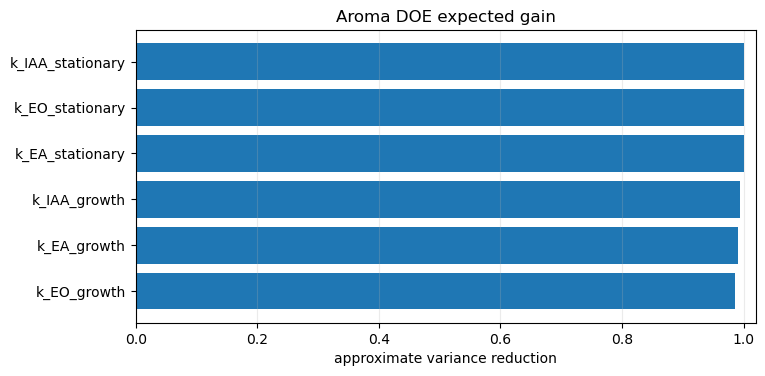

In [8]:

fig, ax = plt.subplots(figsize=(8, 3.8))
plot_df = param_reduction.sort_values("campaign_var_reduction")
ax.barh(plot_df["parameter"], plot_df["campaign_var_reduction"], color="tab:blue")
ax.set_xlabel("approximate variance reduction")
ax.set_xlim(0, 1.02)
ax.grid(axis="x", alpha=0.25)
ax.set_title("Aroma DOE expected gain")
plt.show()



## 10. Manipulated inputs

The following plots show the manipulated inputs for the selected campaign. Pulses are represented as impulse-like additions in the protocol and as 3 h Gaussian input functions inside the model.


aroma_campaign_inputs_cold_synthesis_hot_stripping.png


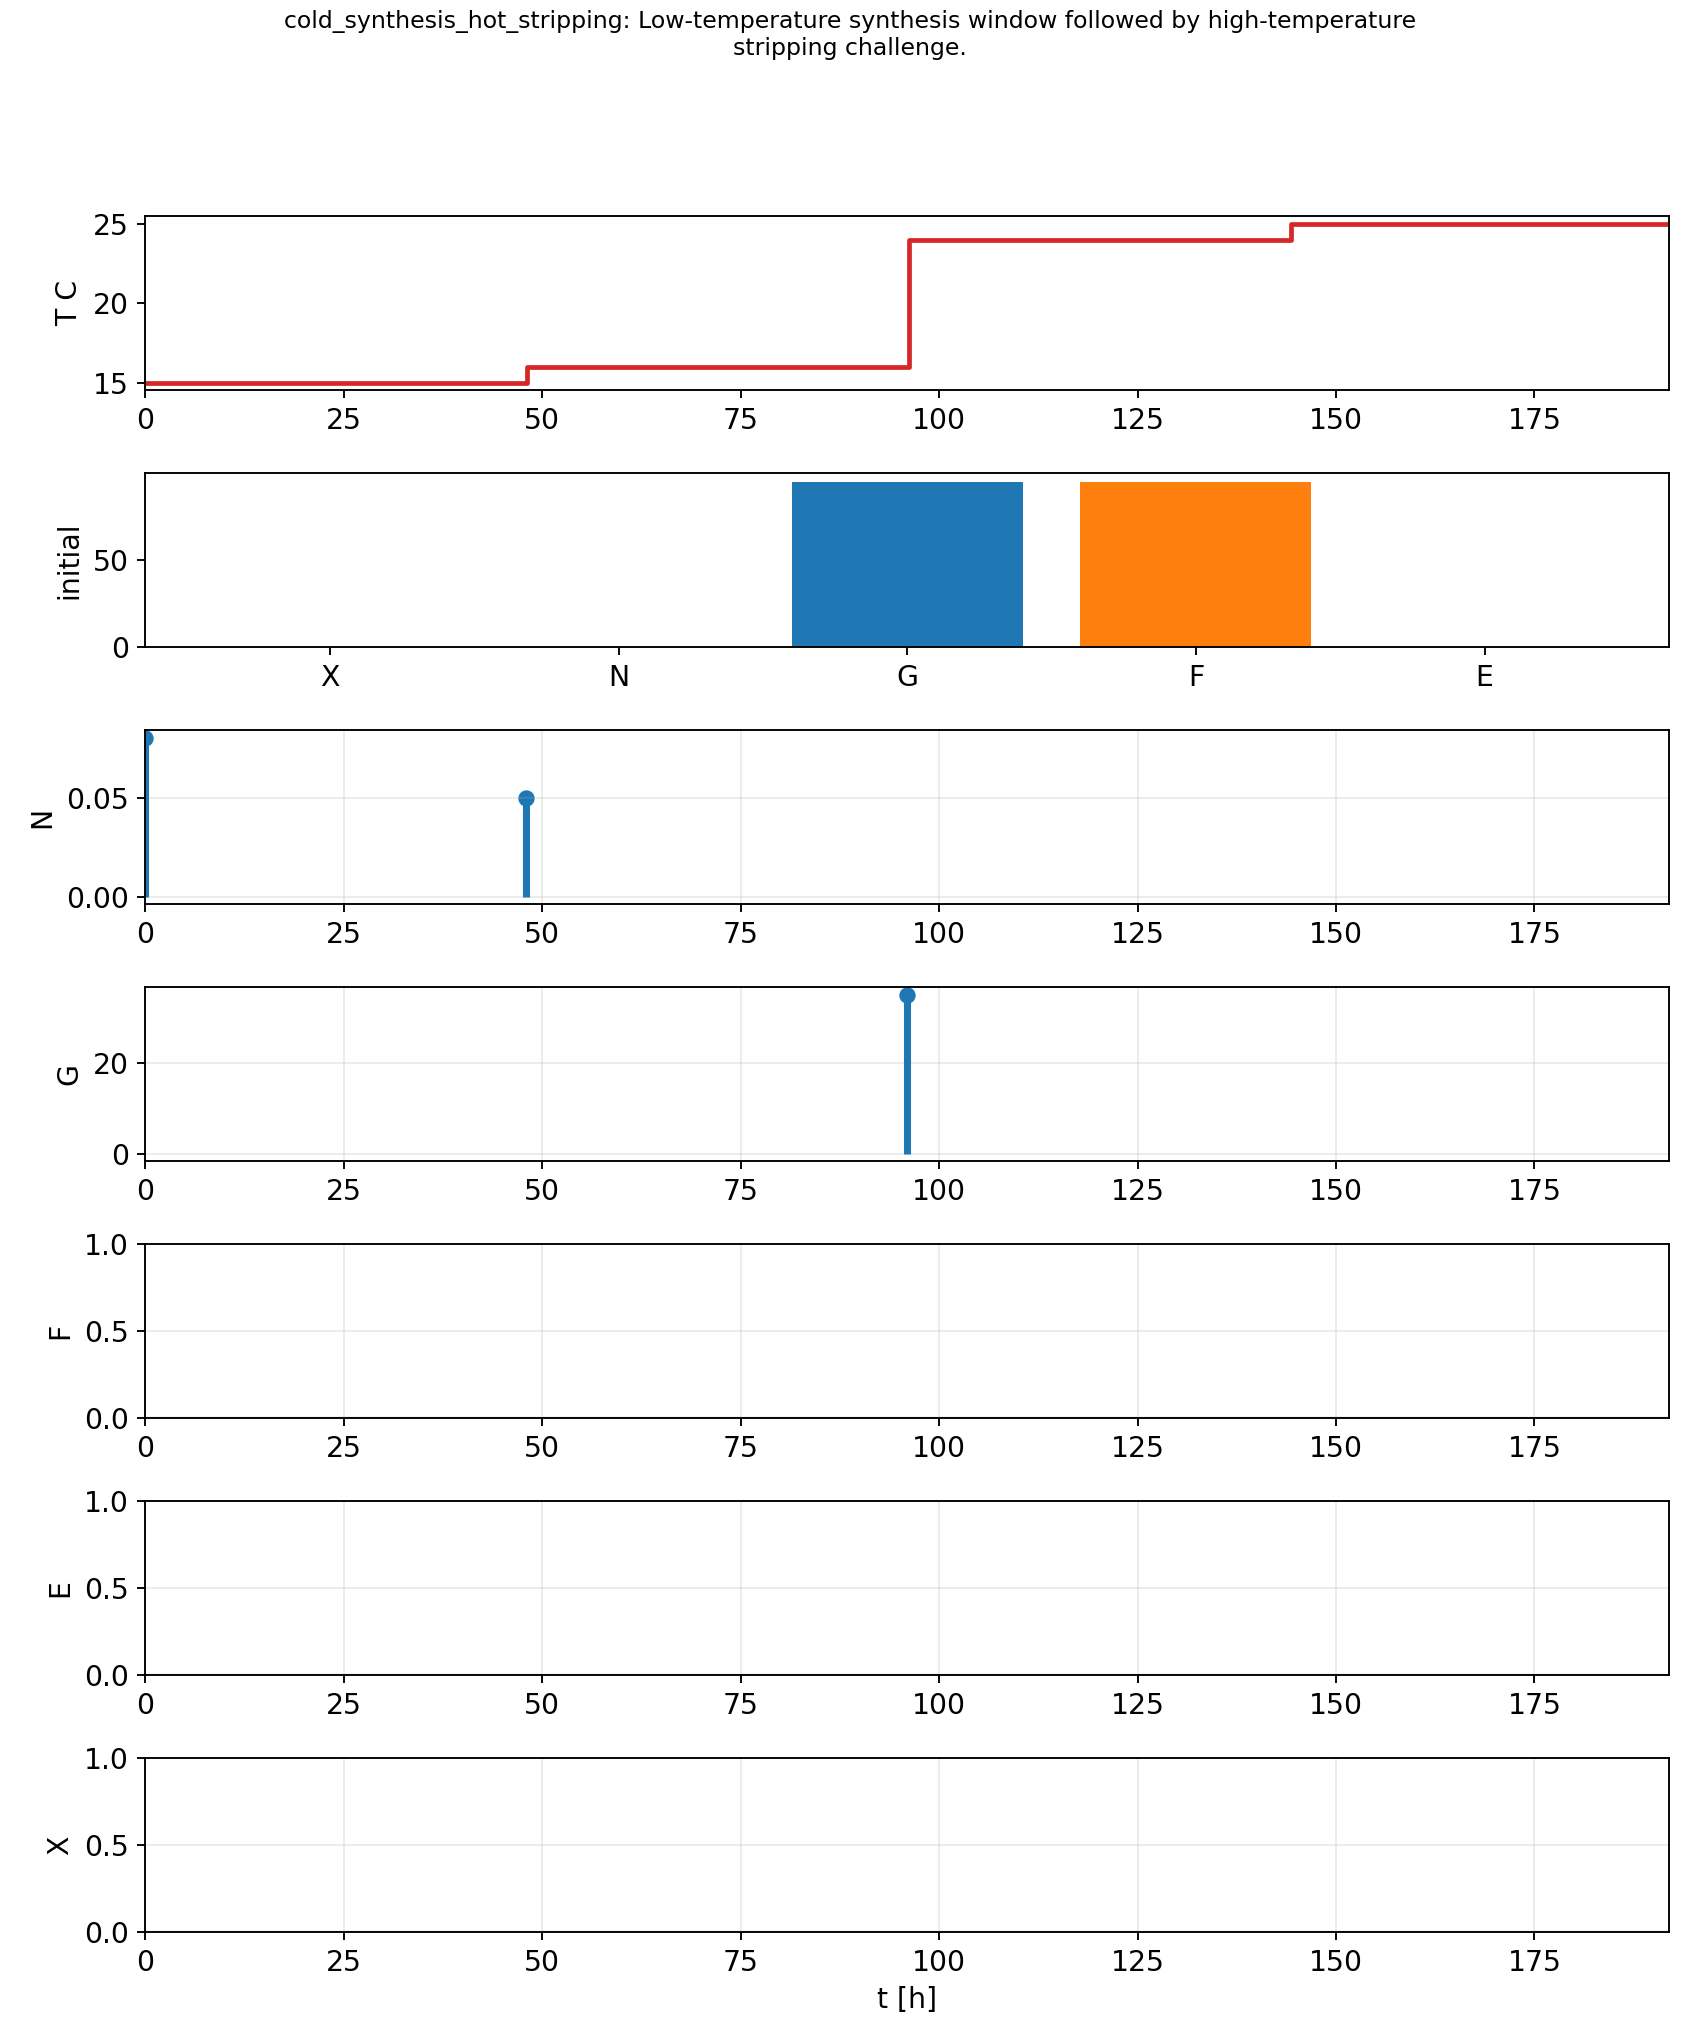

aroma_campaign_inputs_low_temp_growth_separation_plus_co2.png


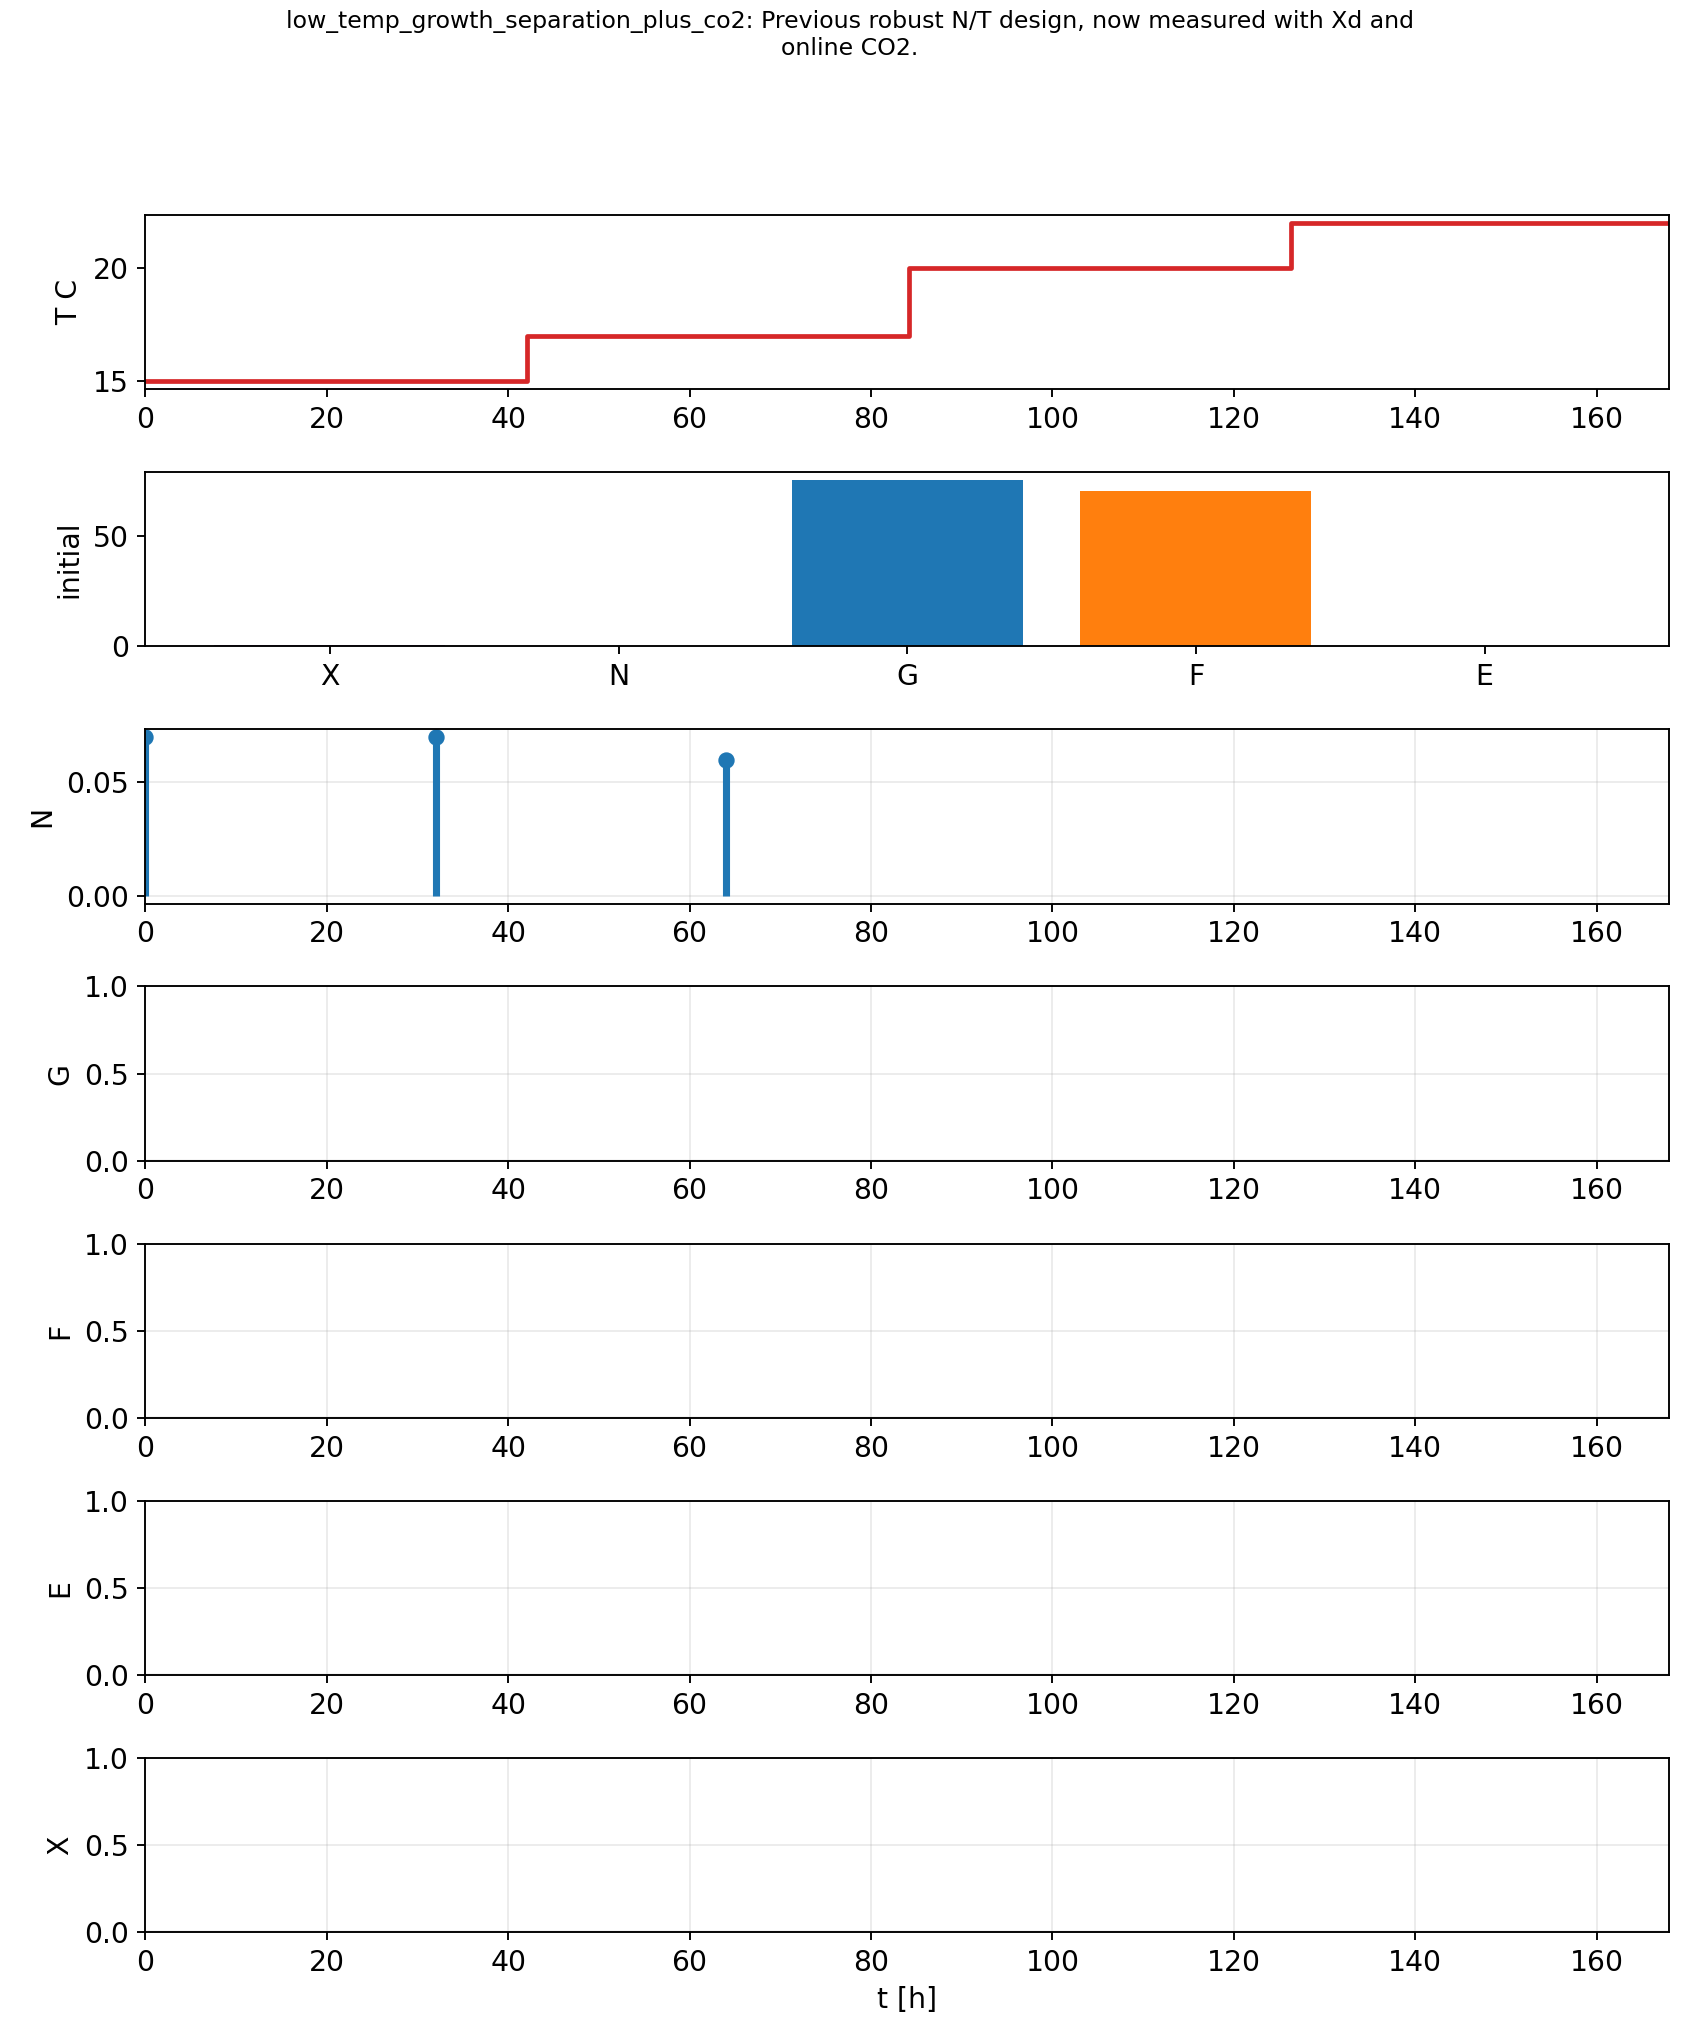

aroma_campaign_inputs_hot_synthesis_cold_retention.png


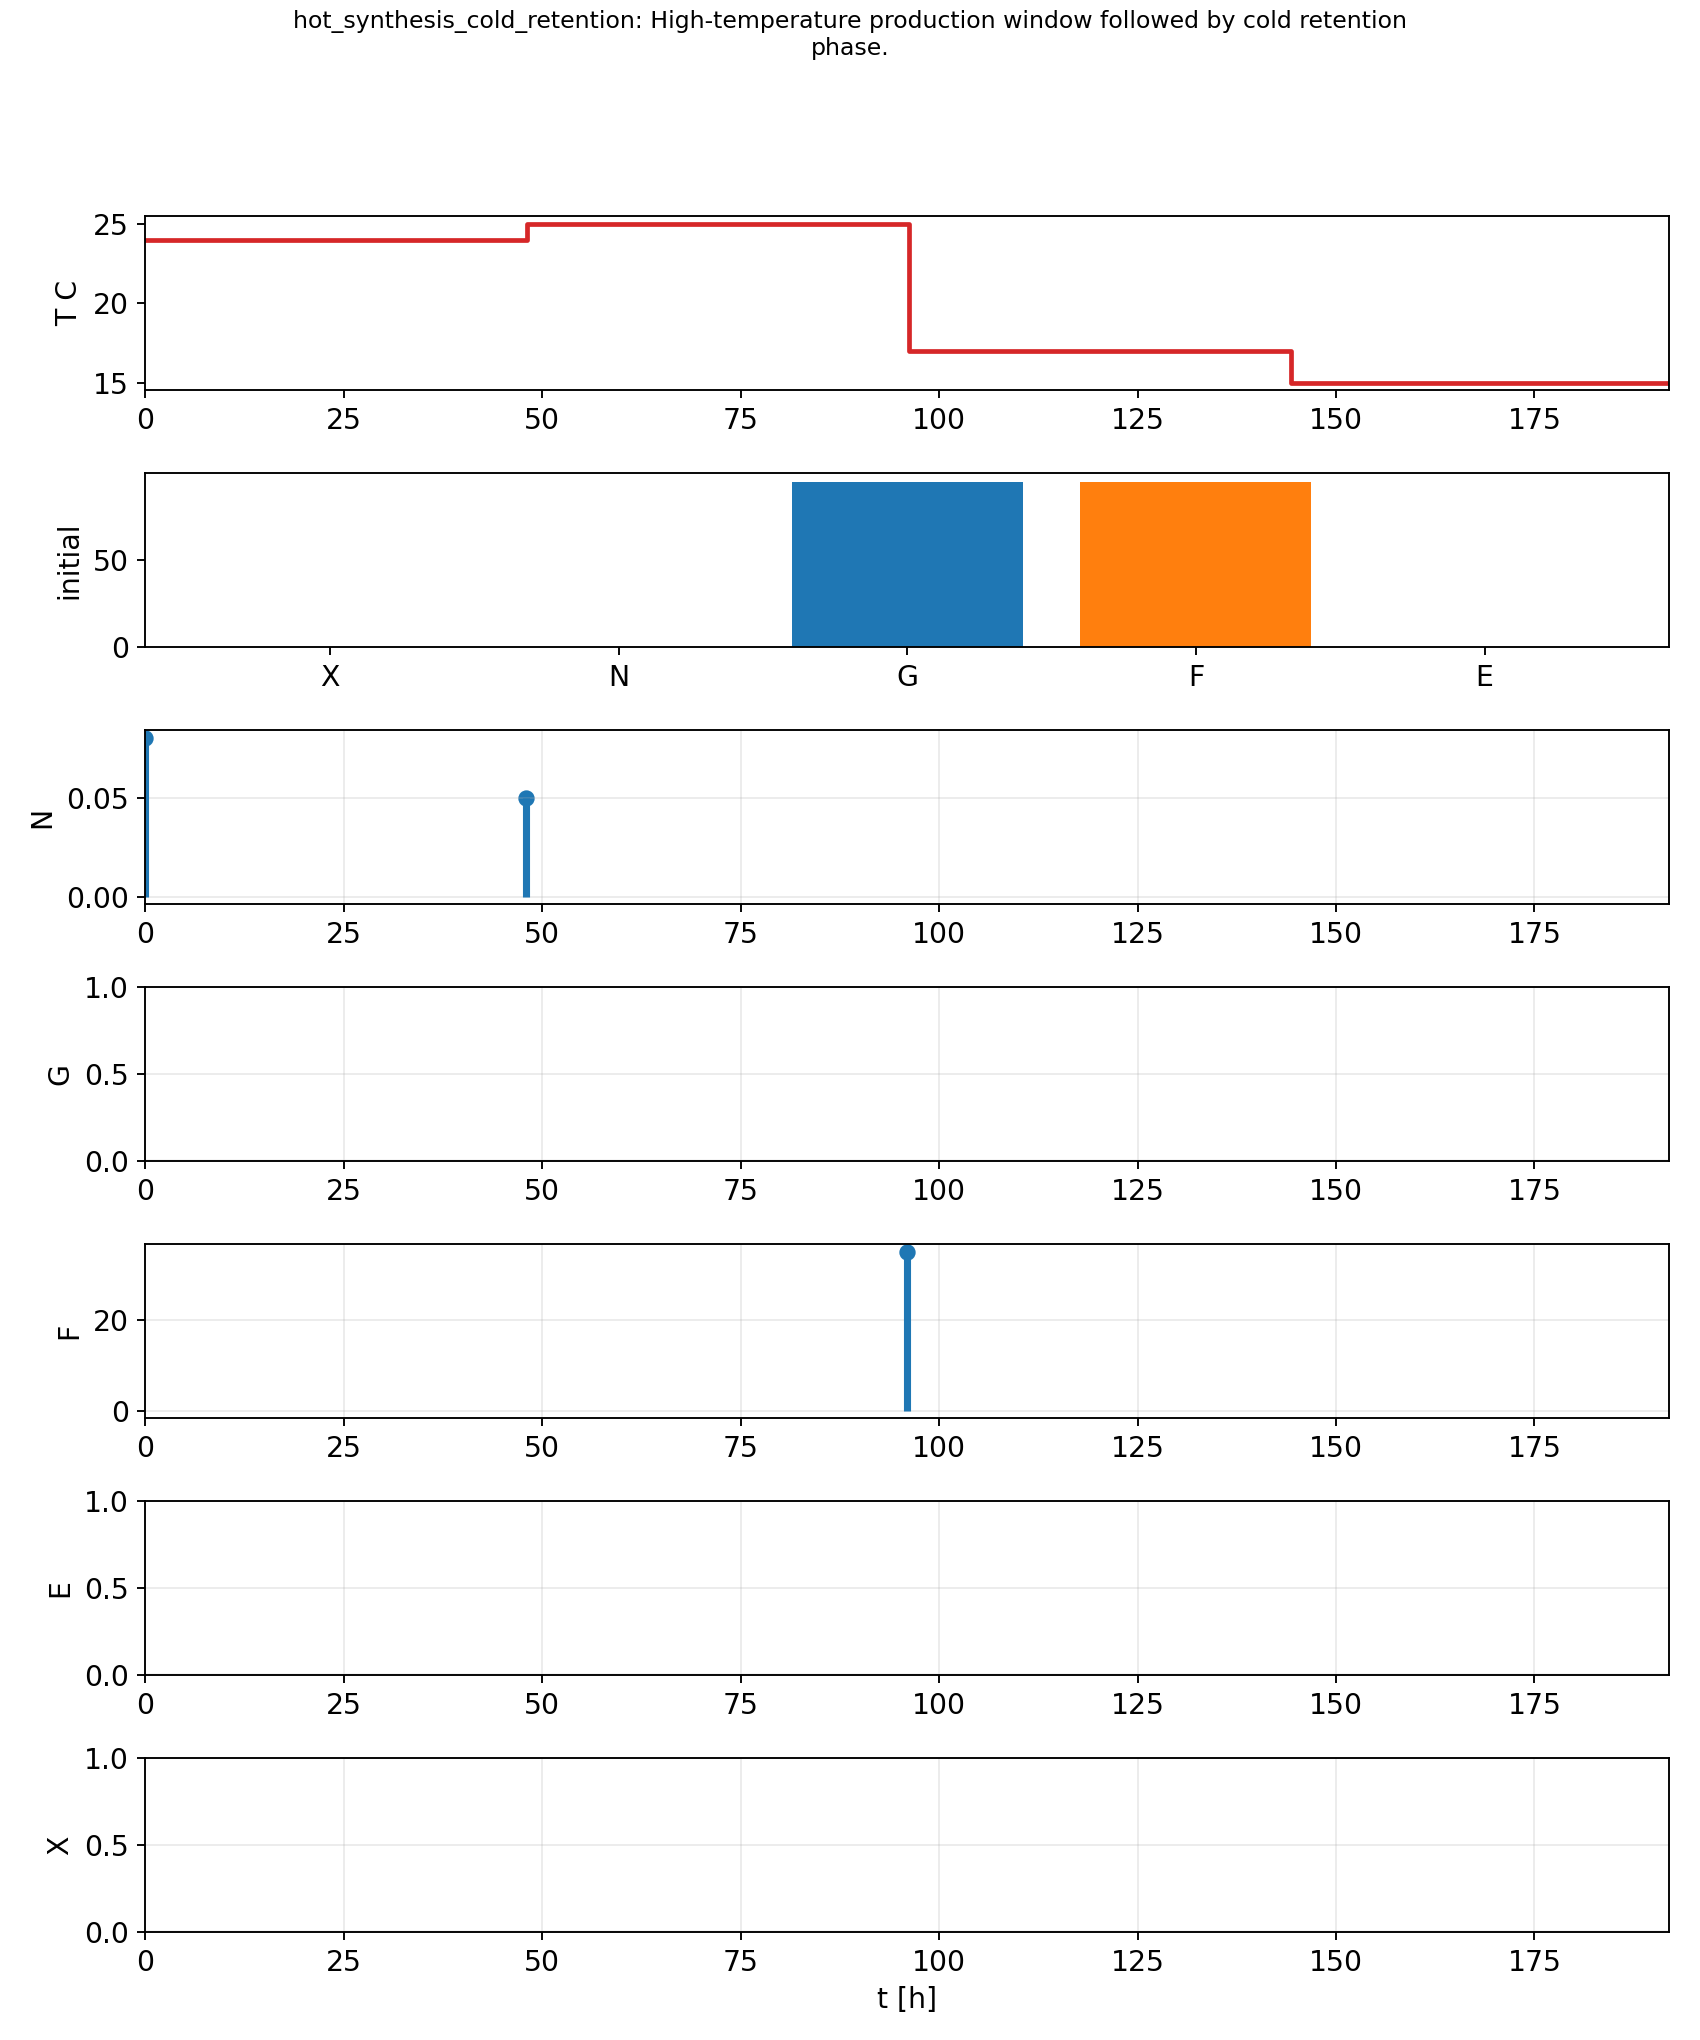

aroma_campaign_inputs_fructose_rich_iG_probe.png


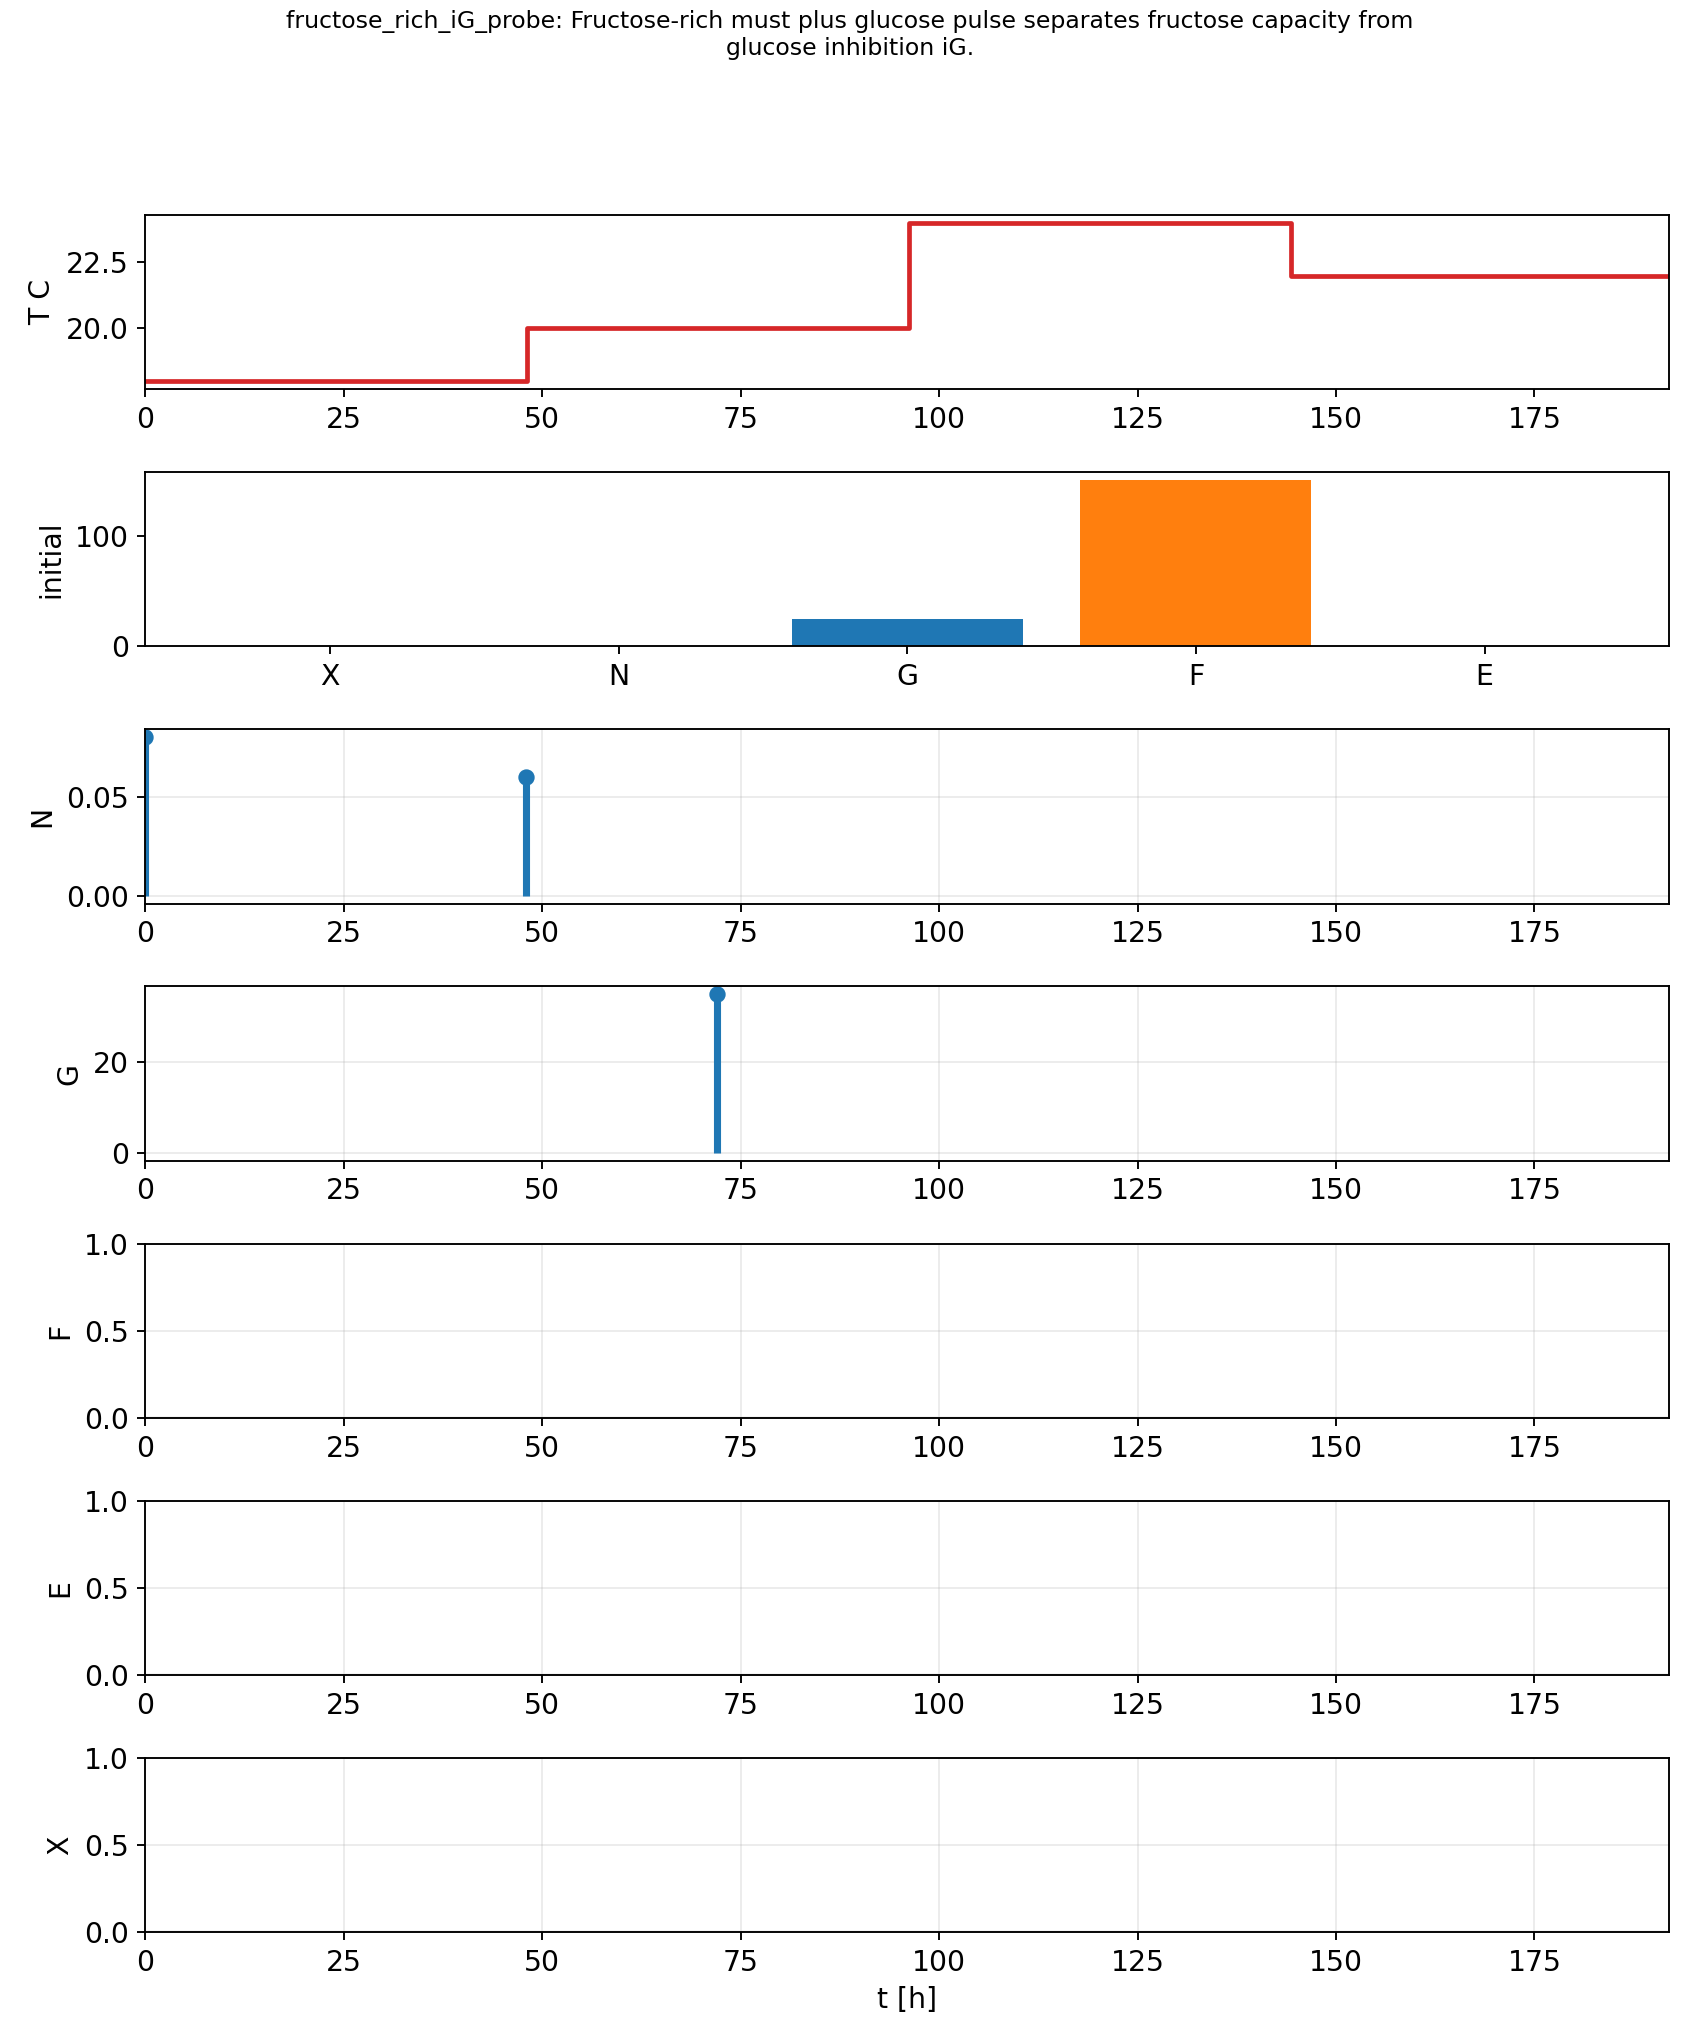

aroma_campaign_inputs_high_biomass_low_N_maintenance.png


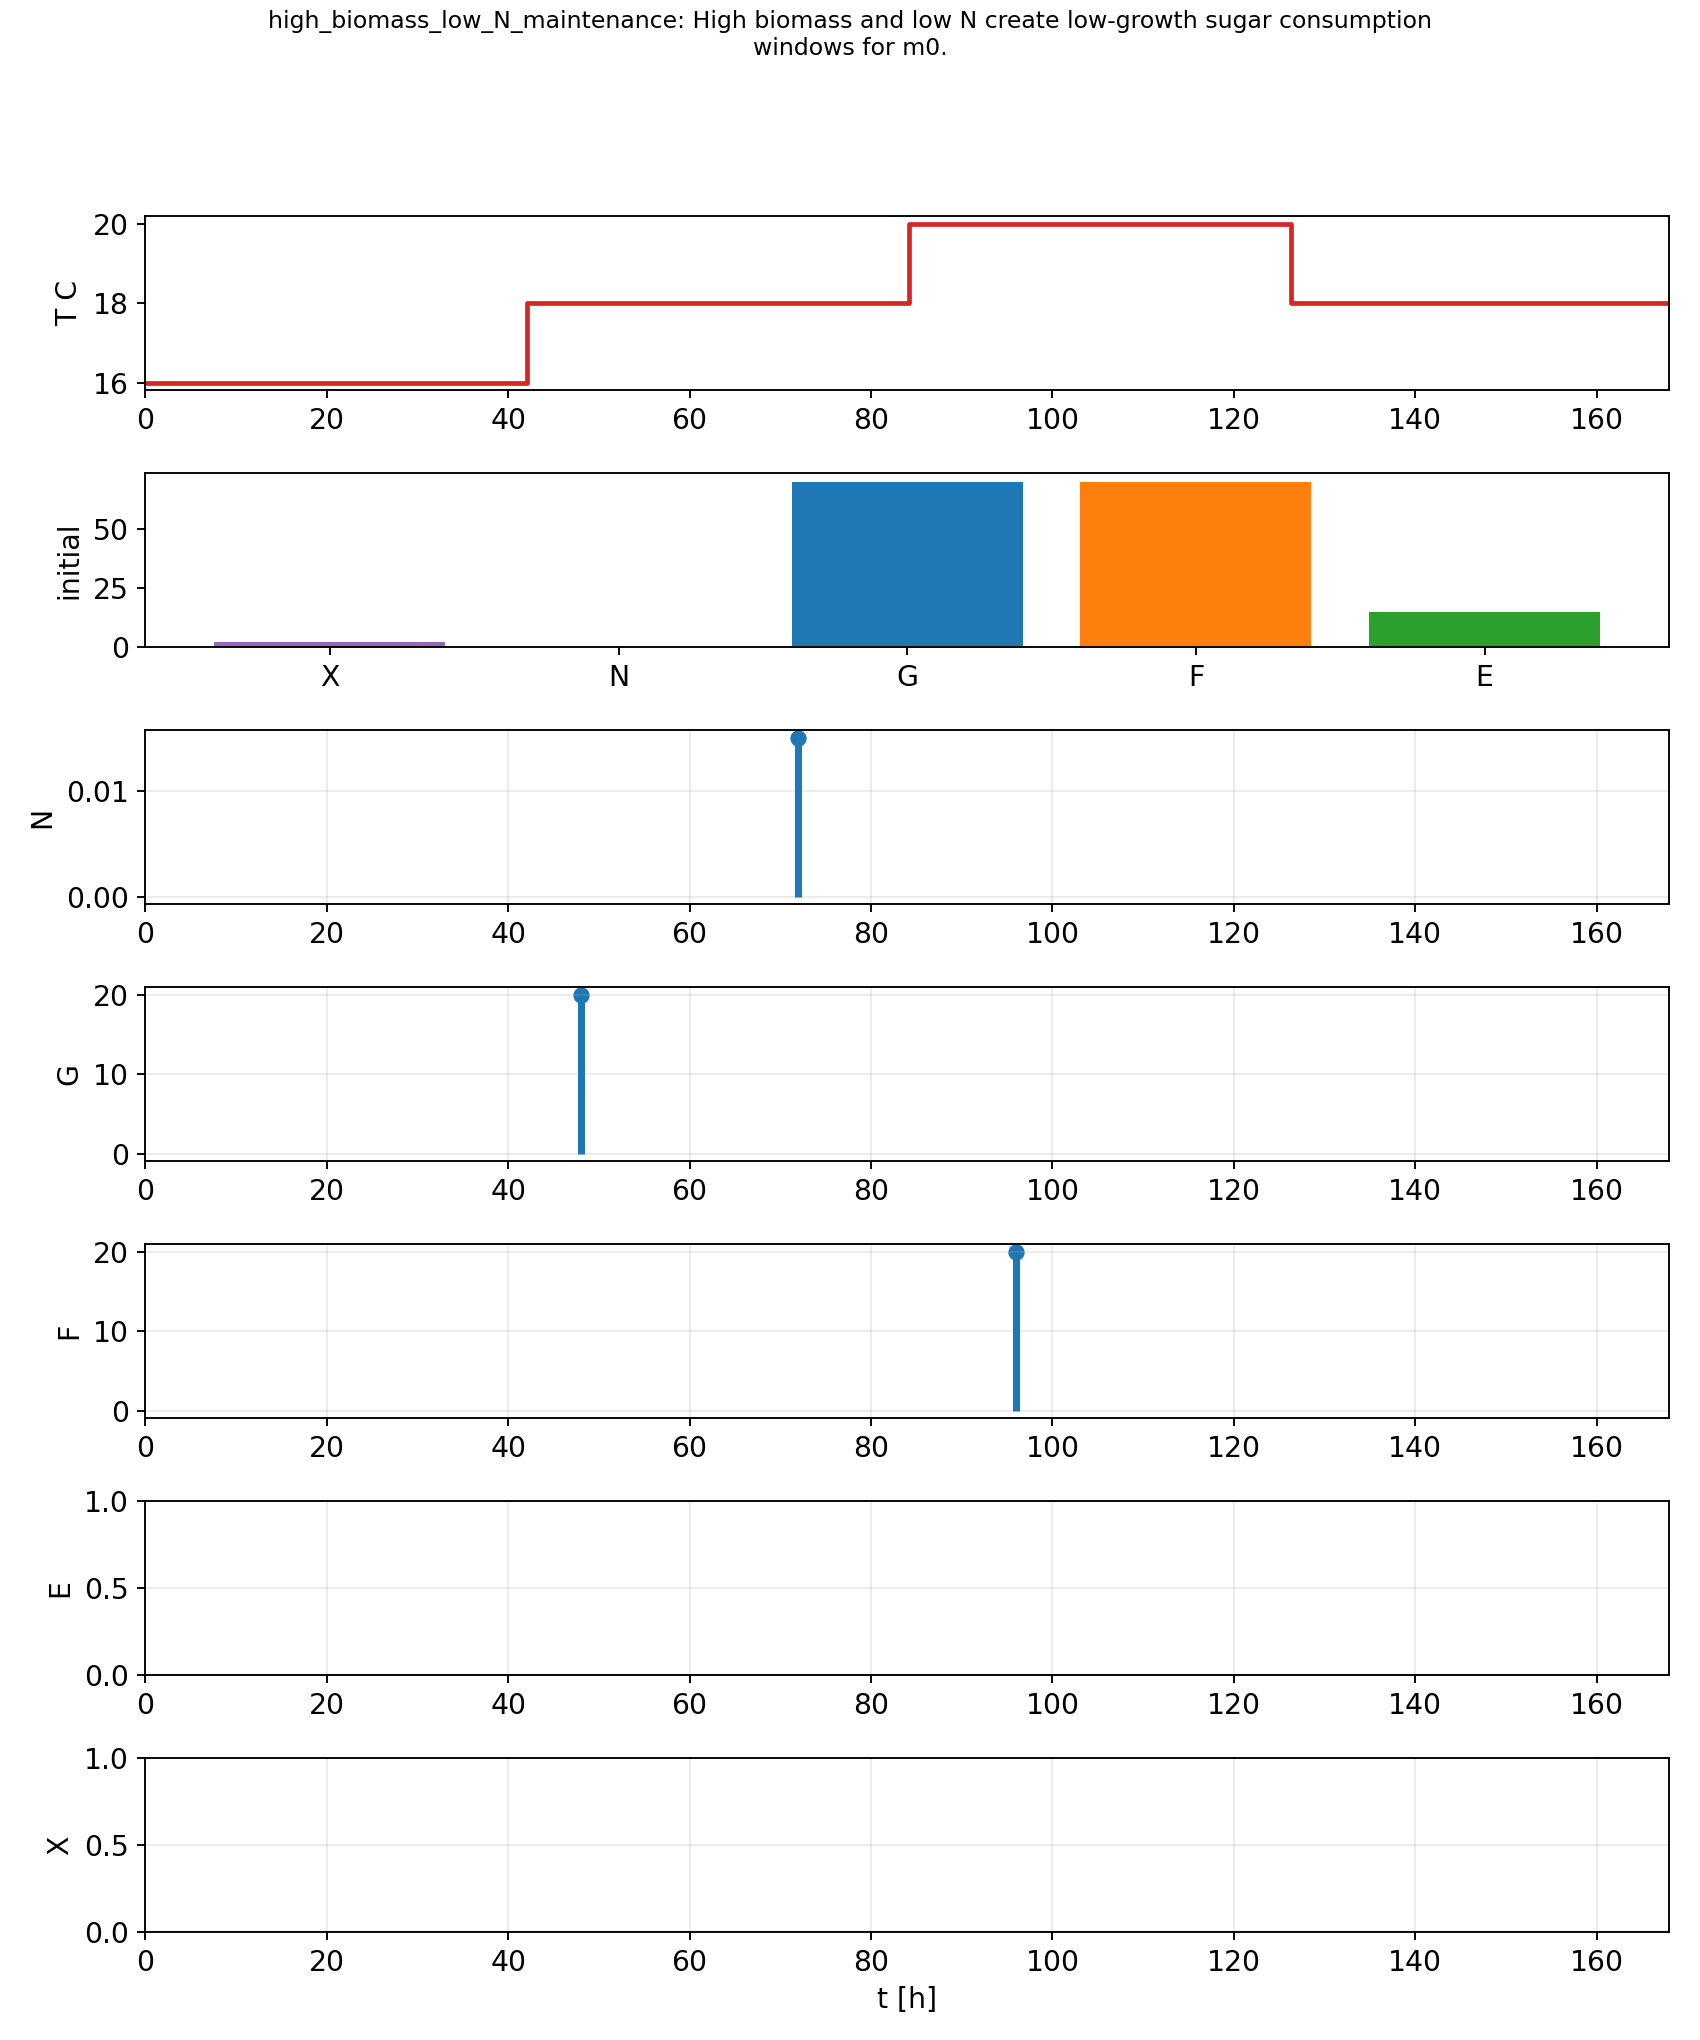

aroma_campaign_inputs_glucose_rich_growth_yield.png


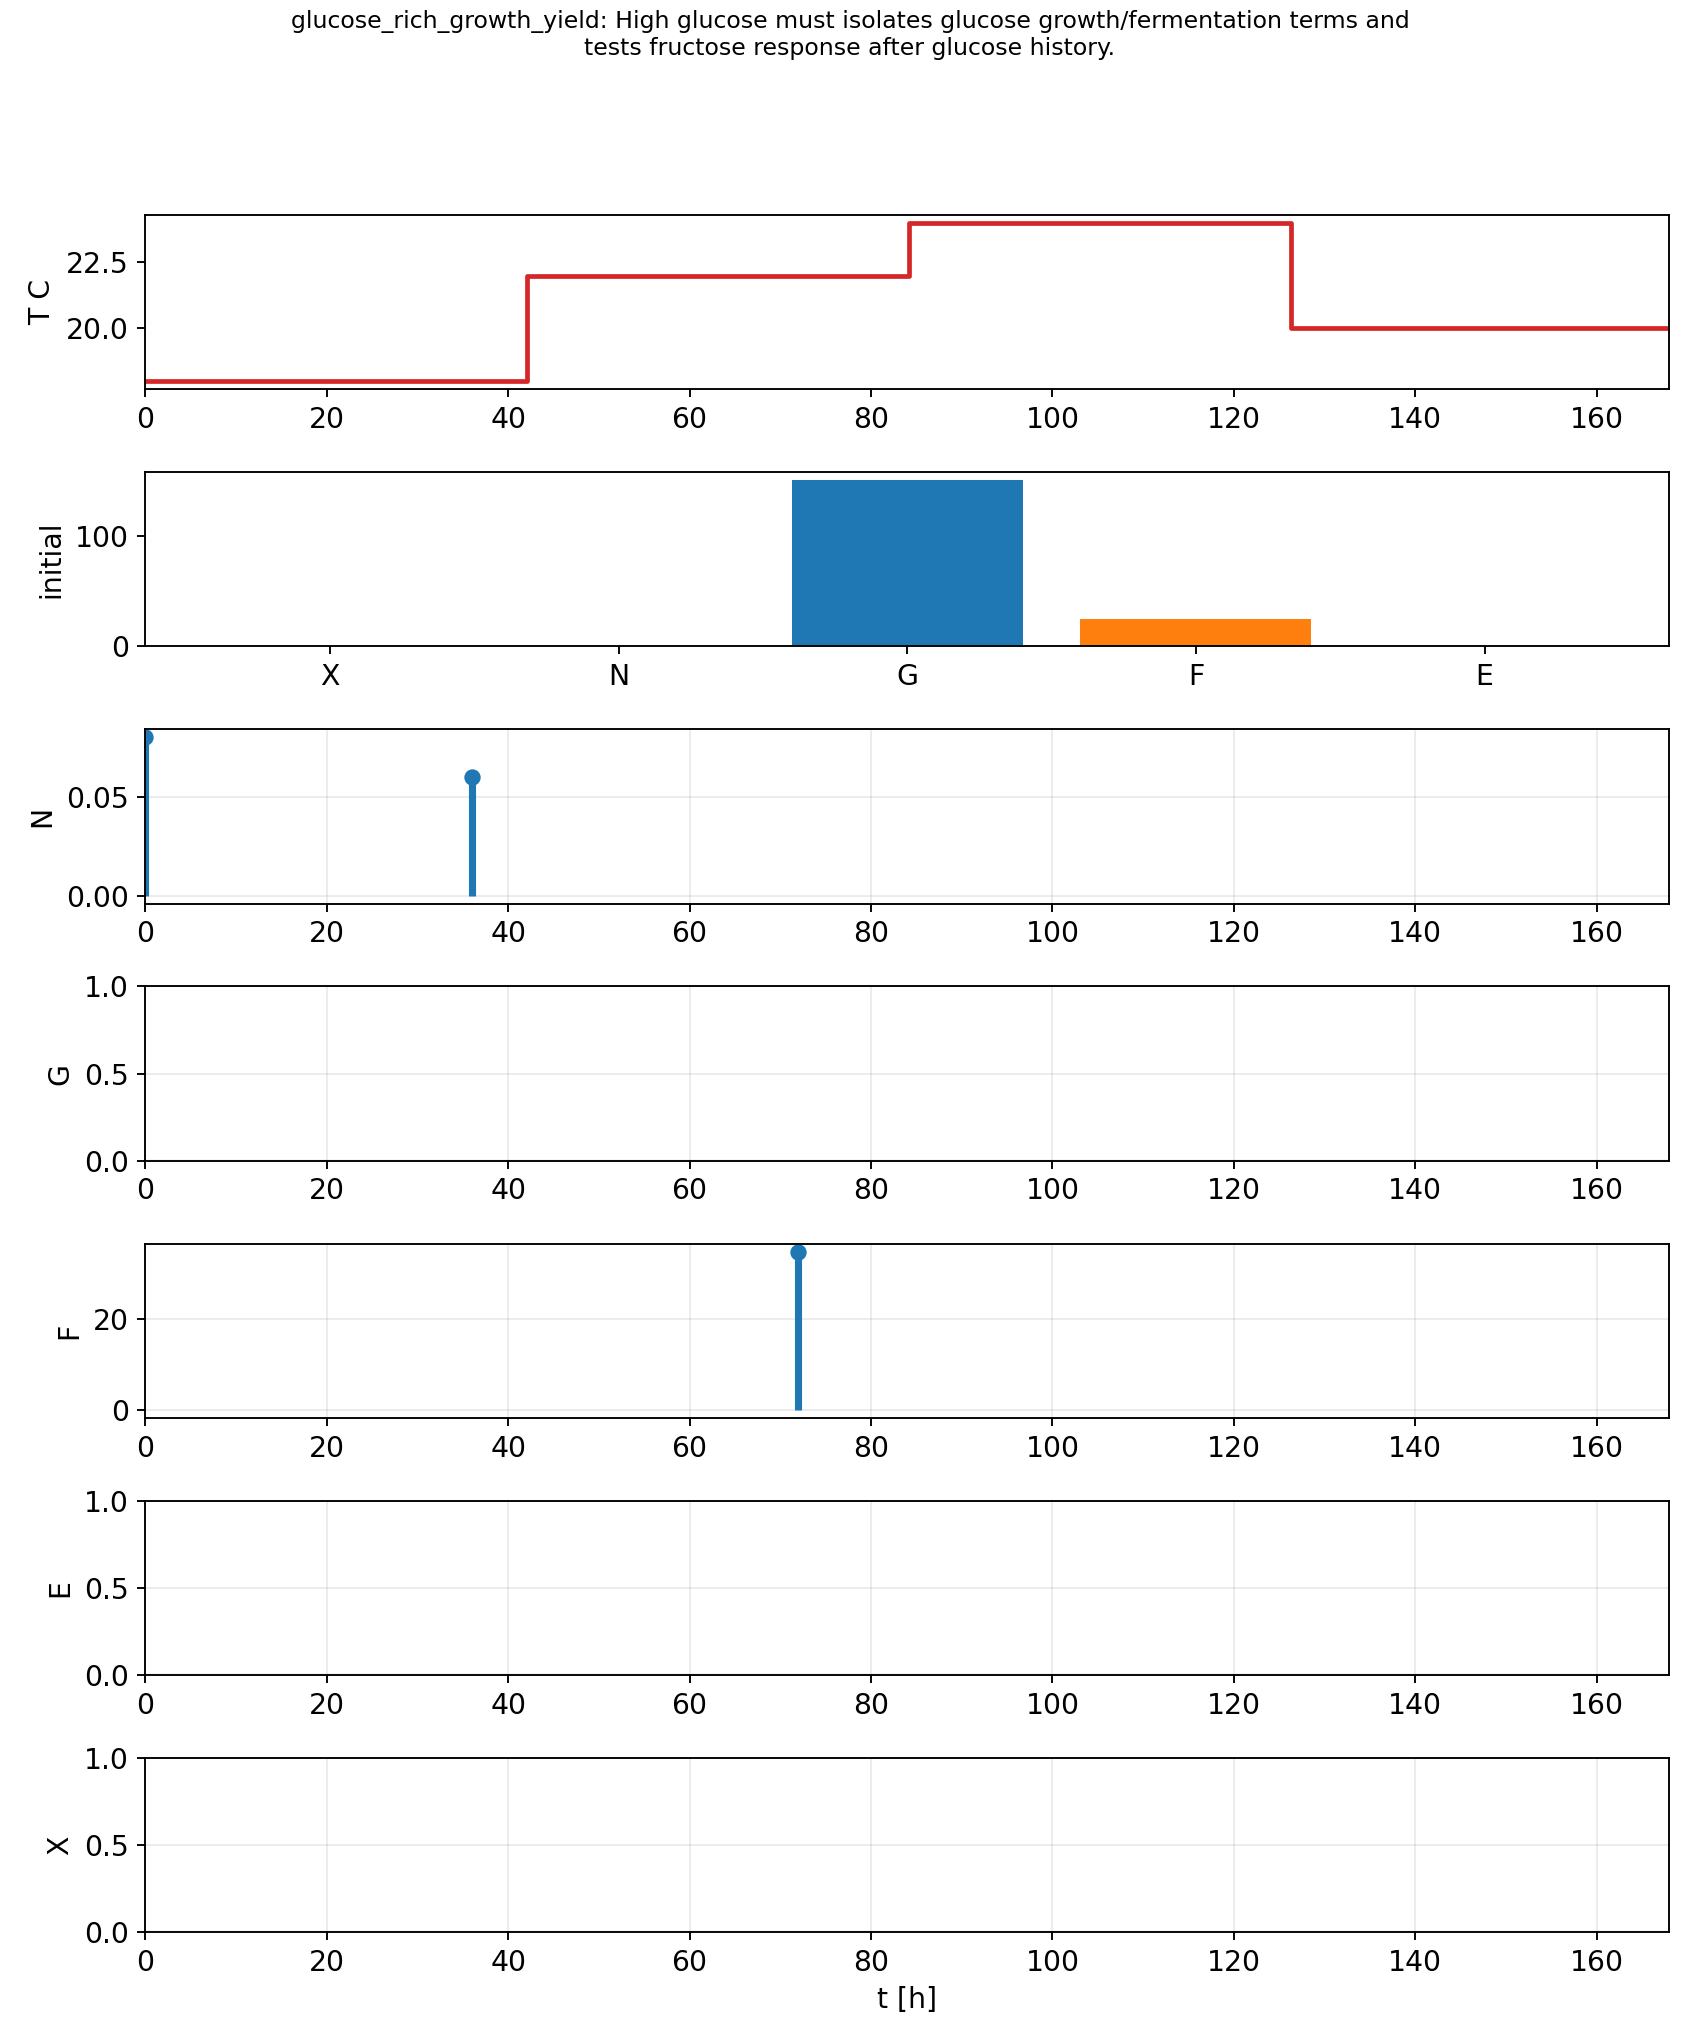

aroma_campaign_inputs_combined_stress_long_horizon.png


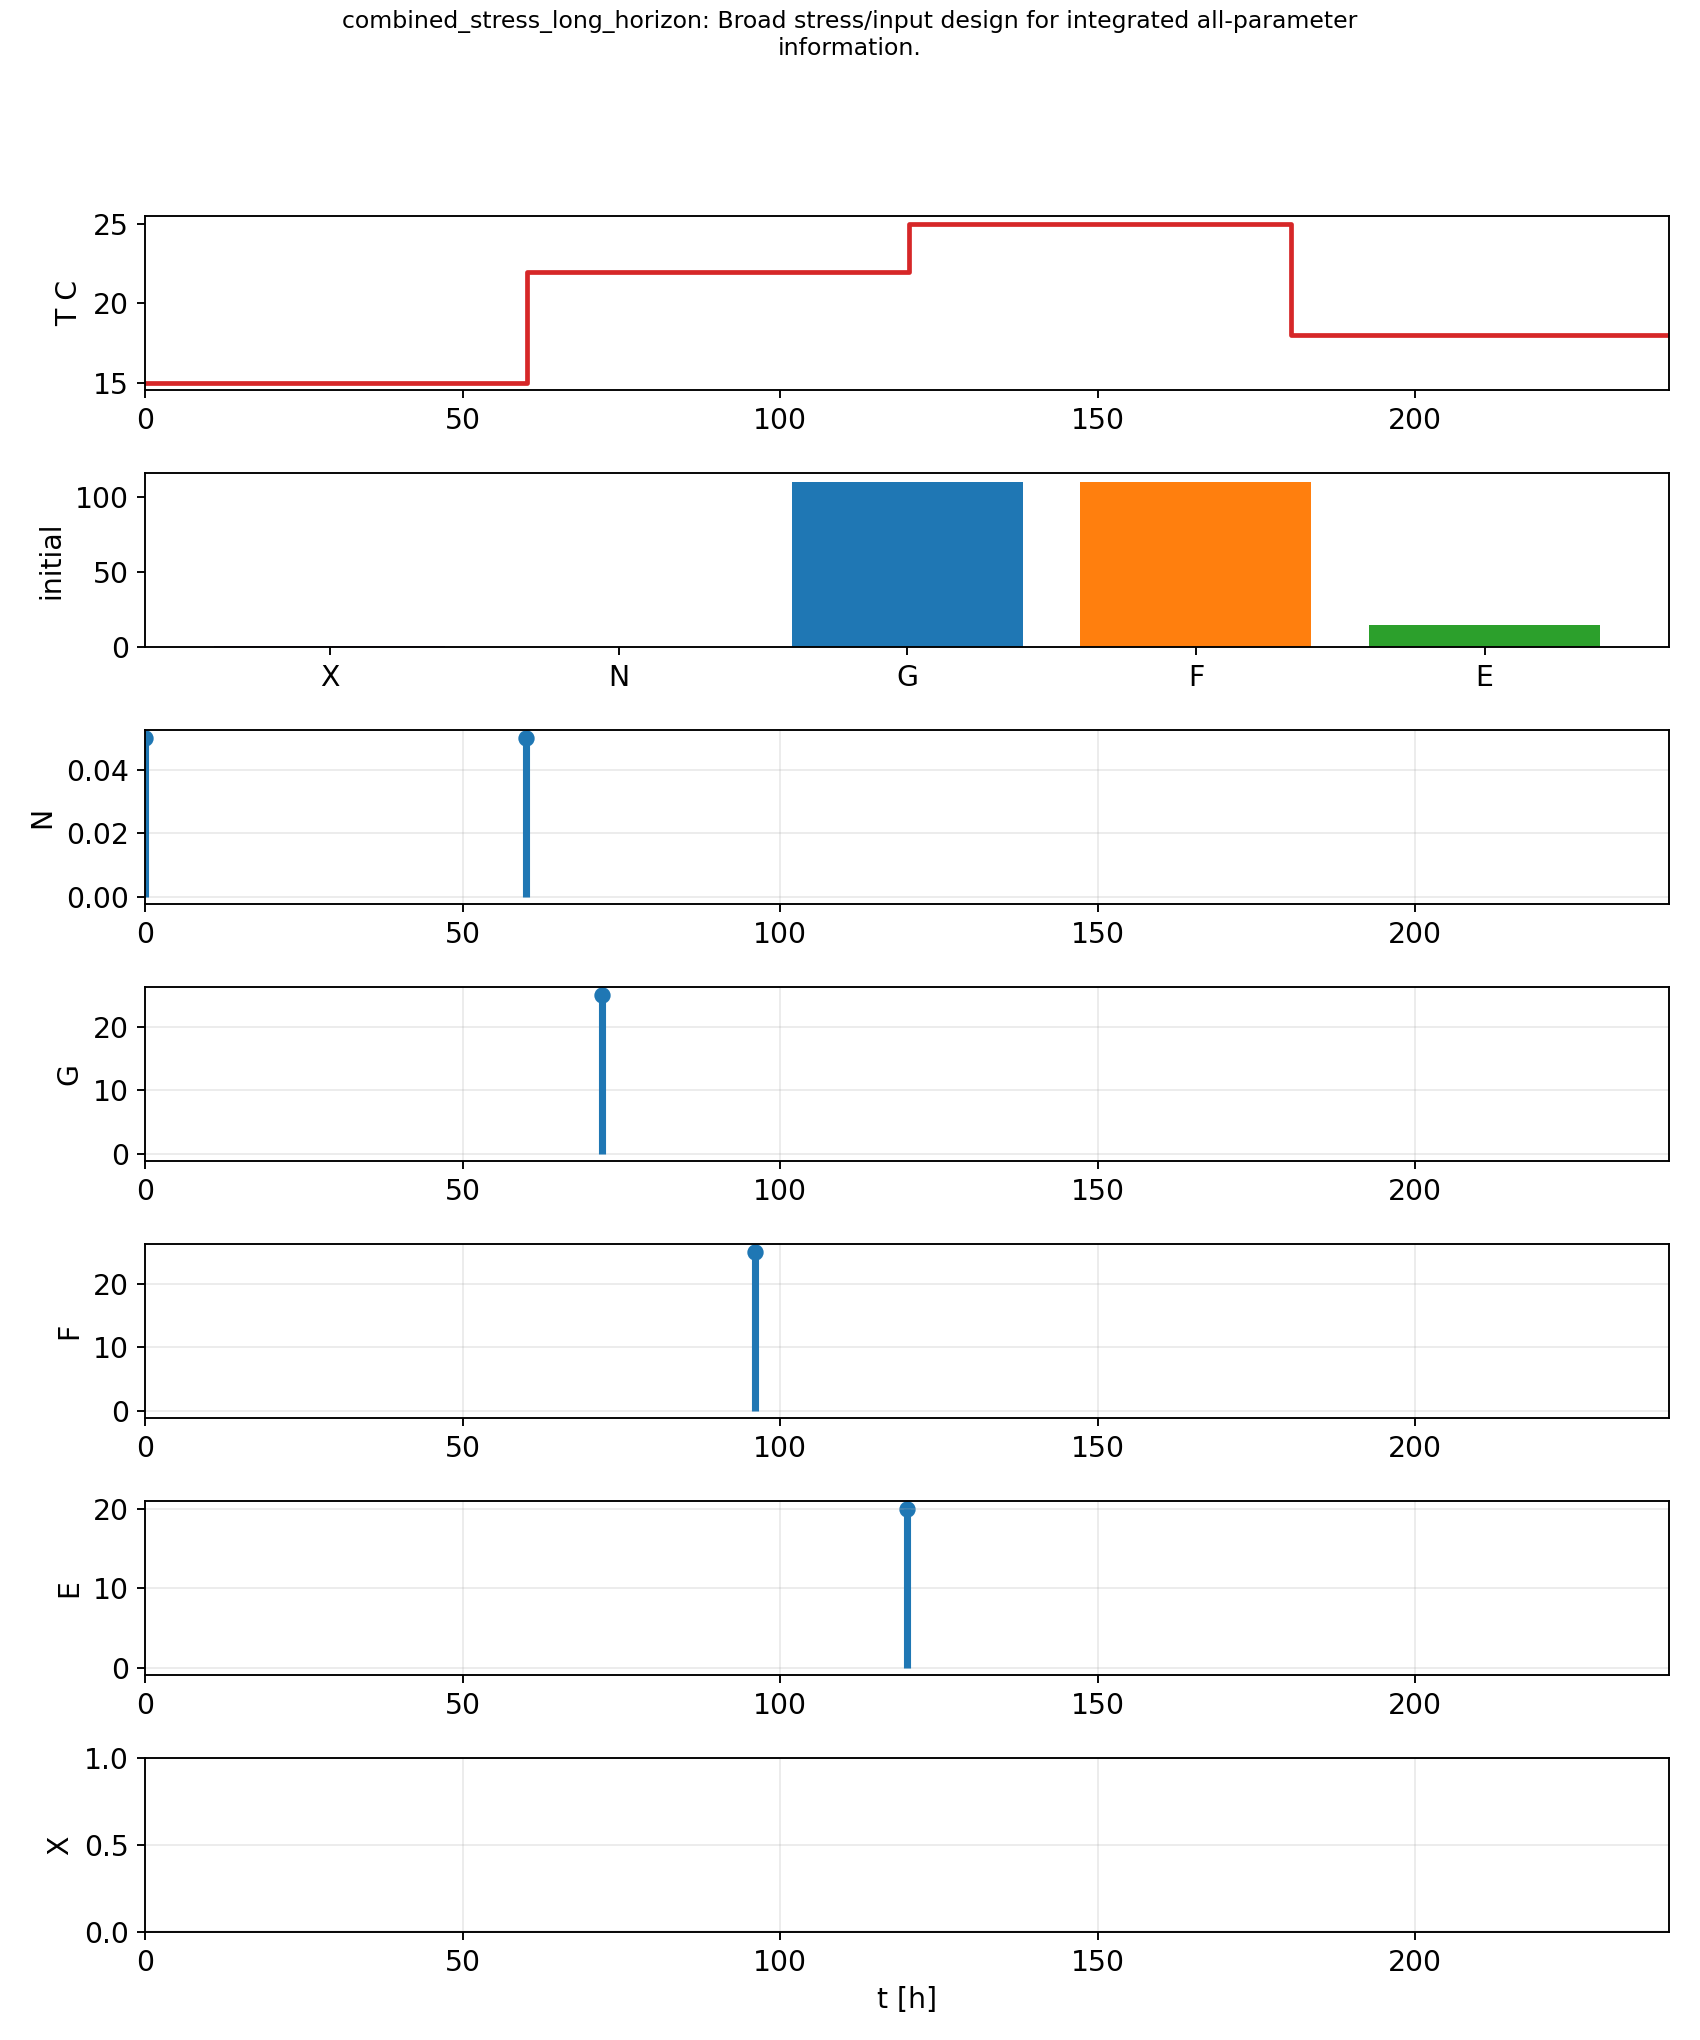

aroma_campaign_inputs_viable_biomass_step.png


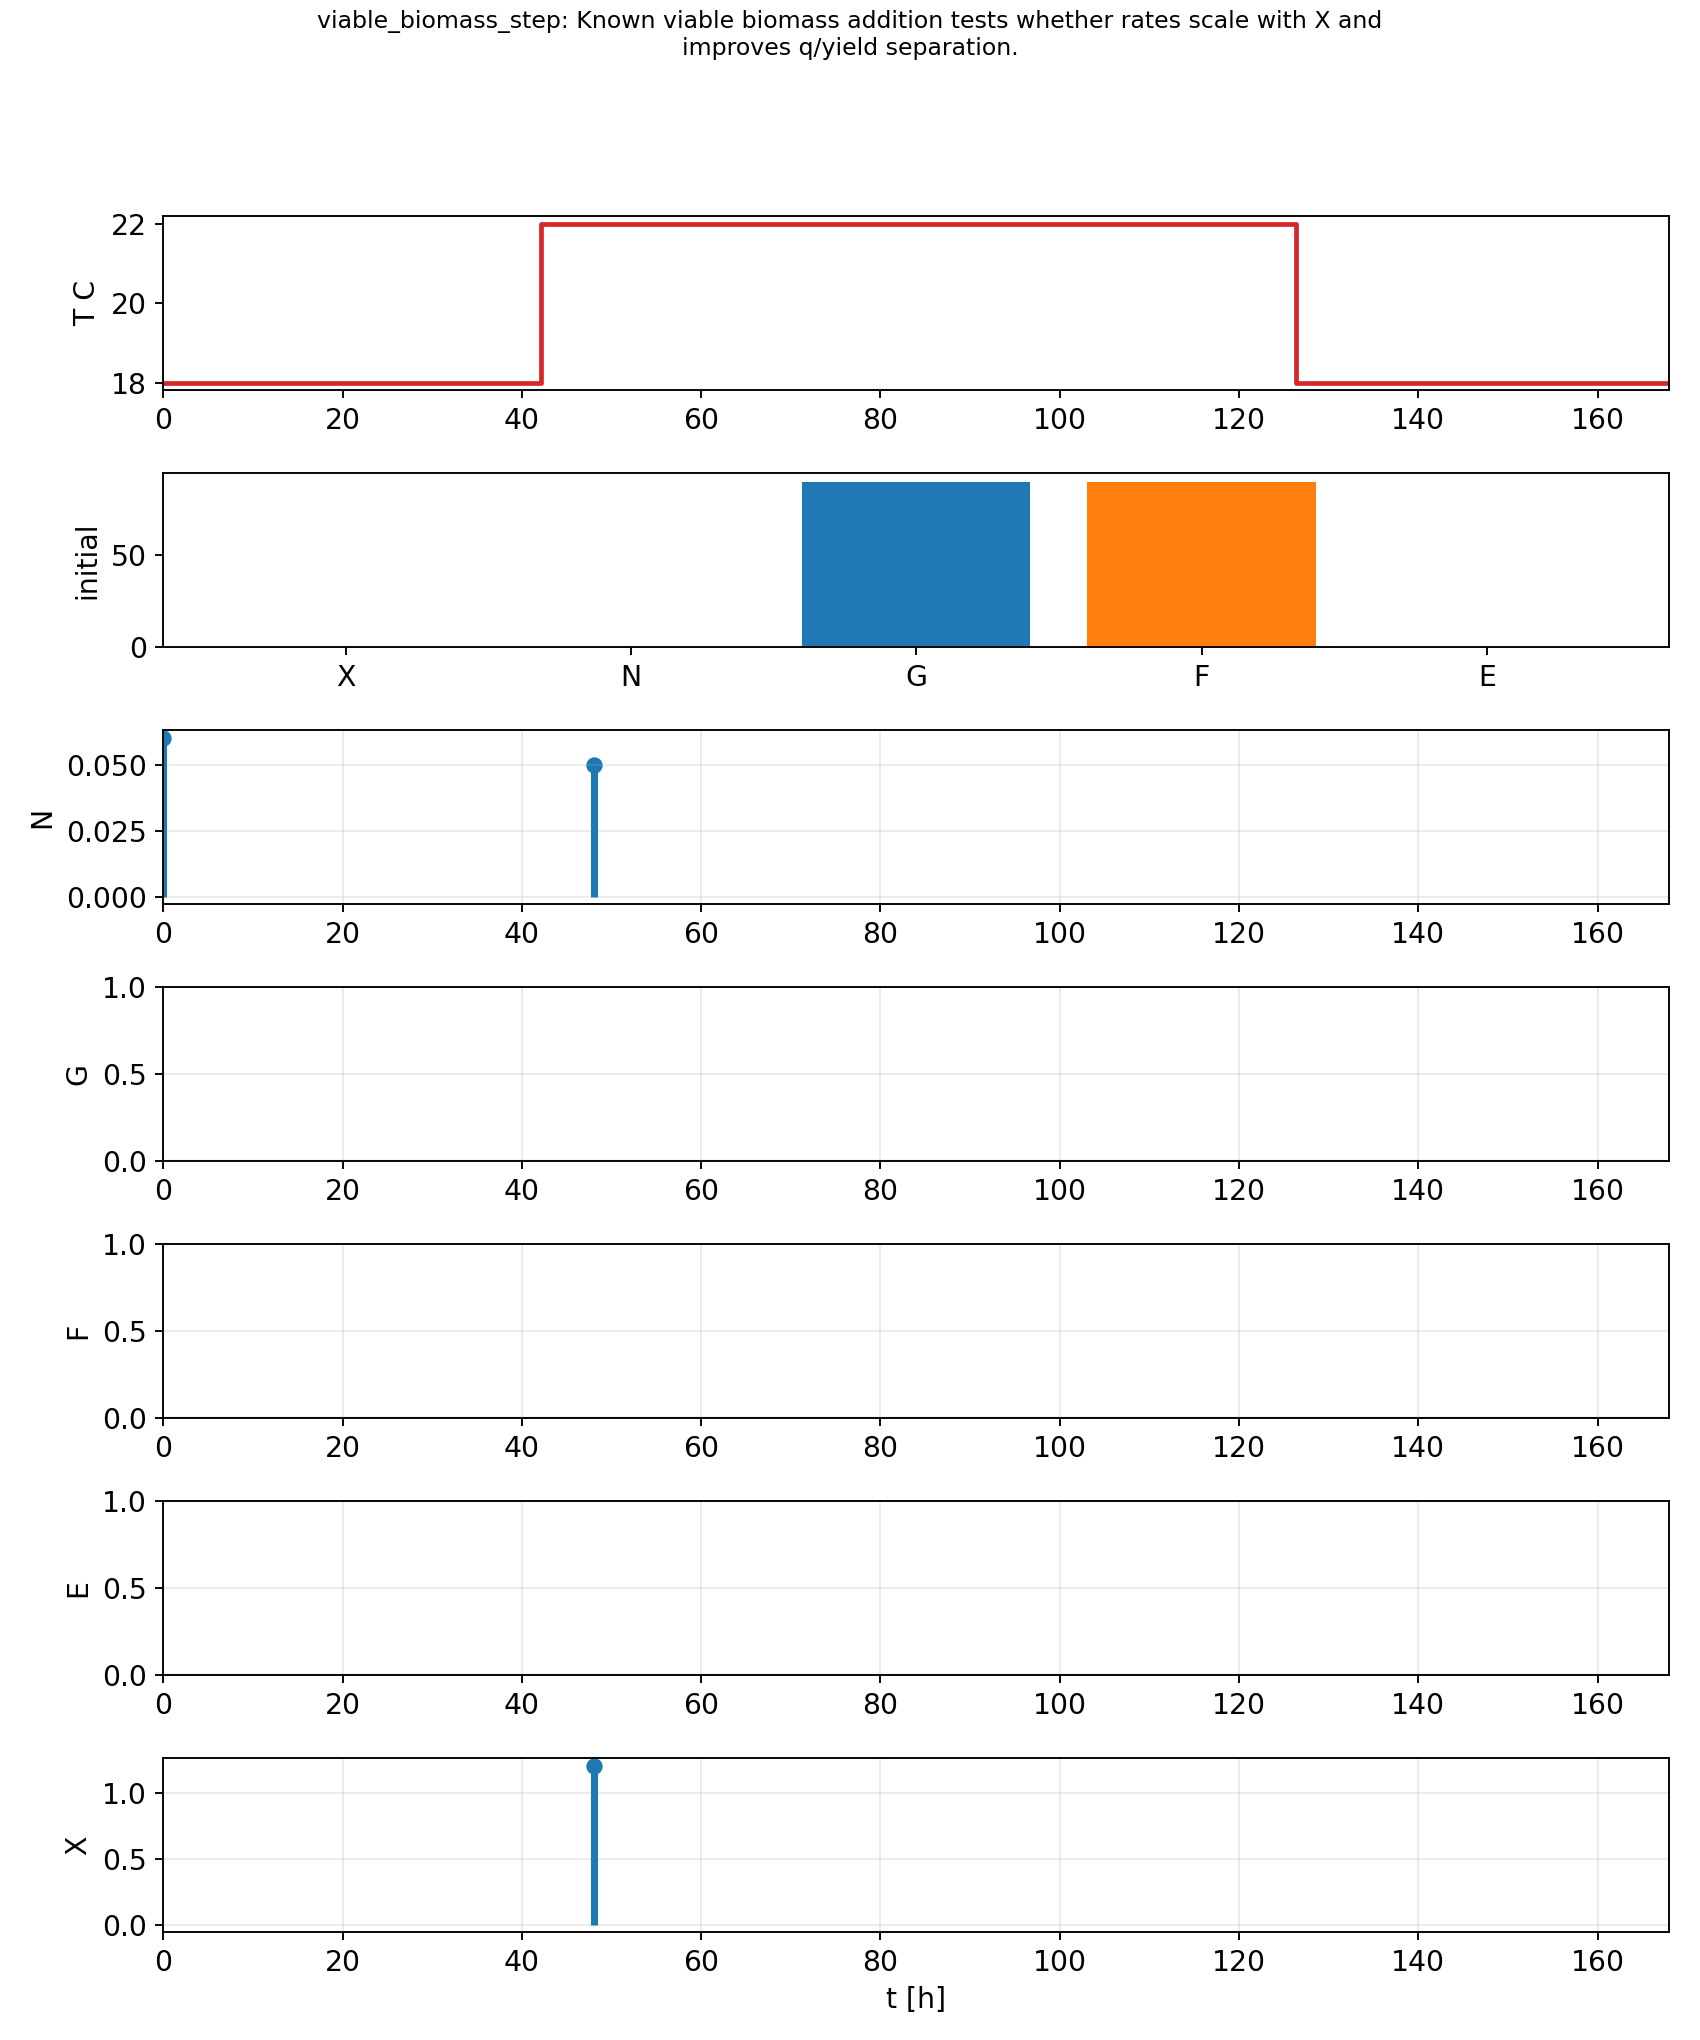

aroma_campaign_inputs_ethanol_partition_late_pulse.png


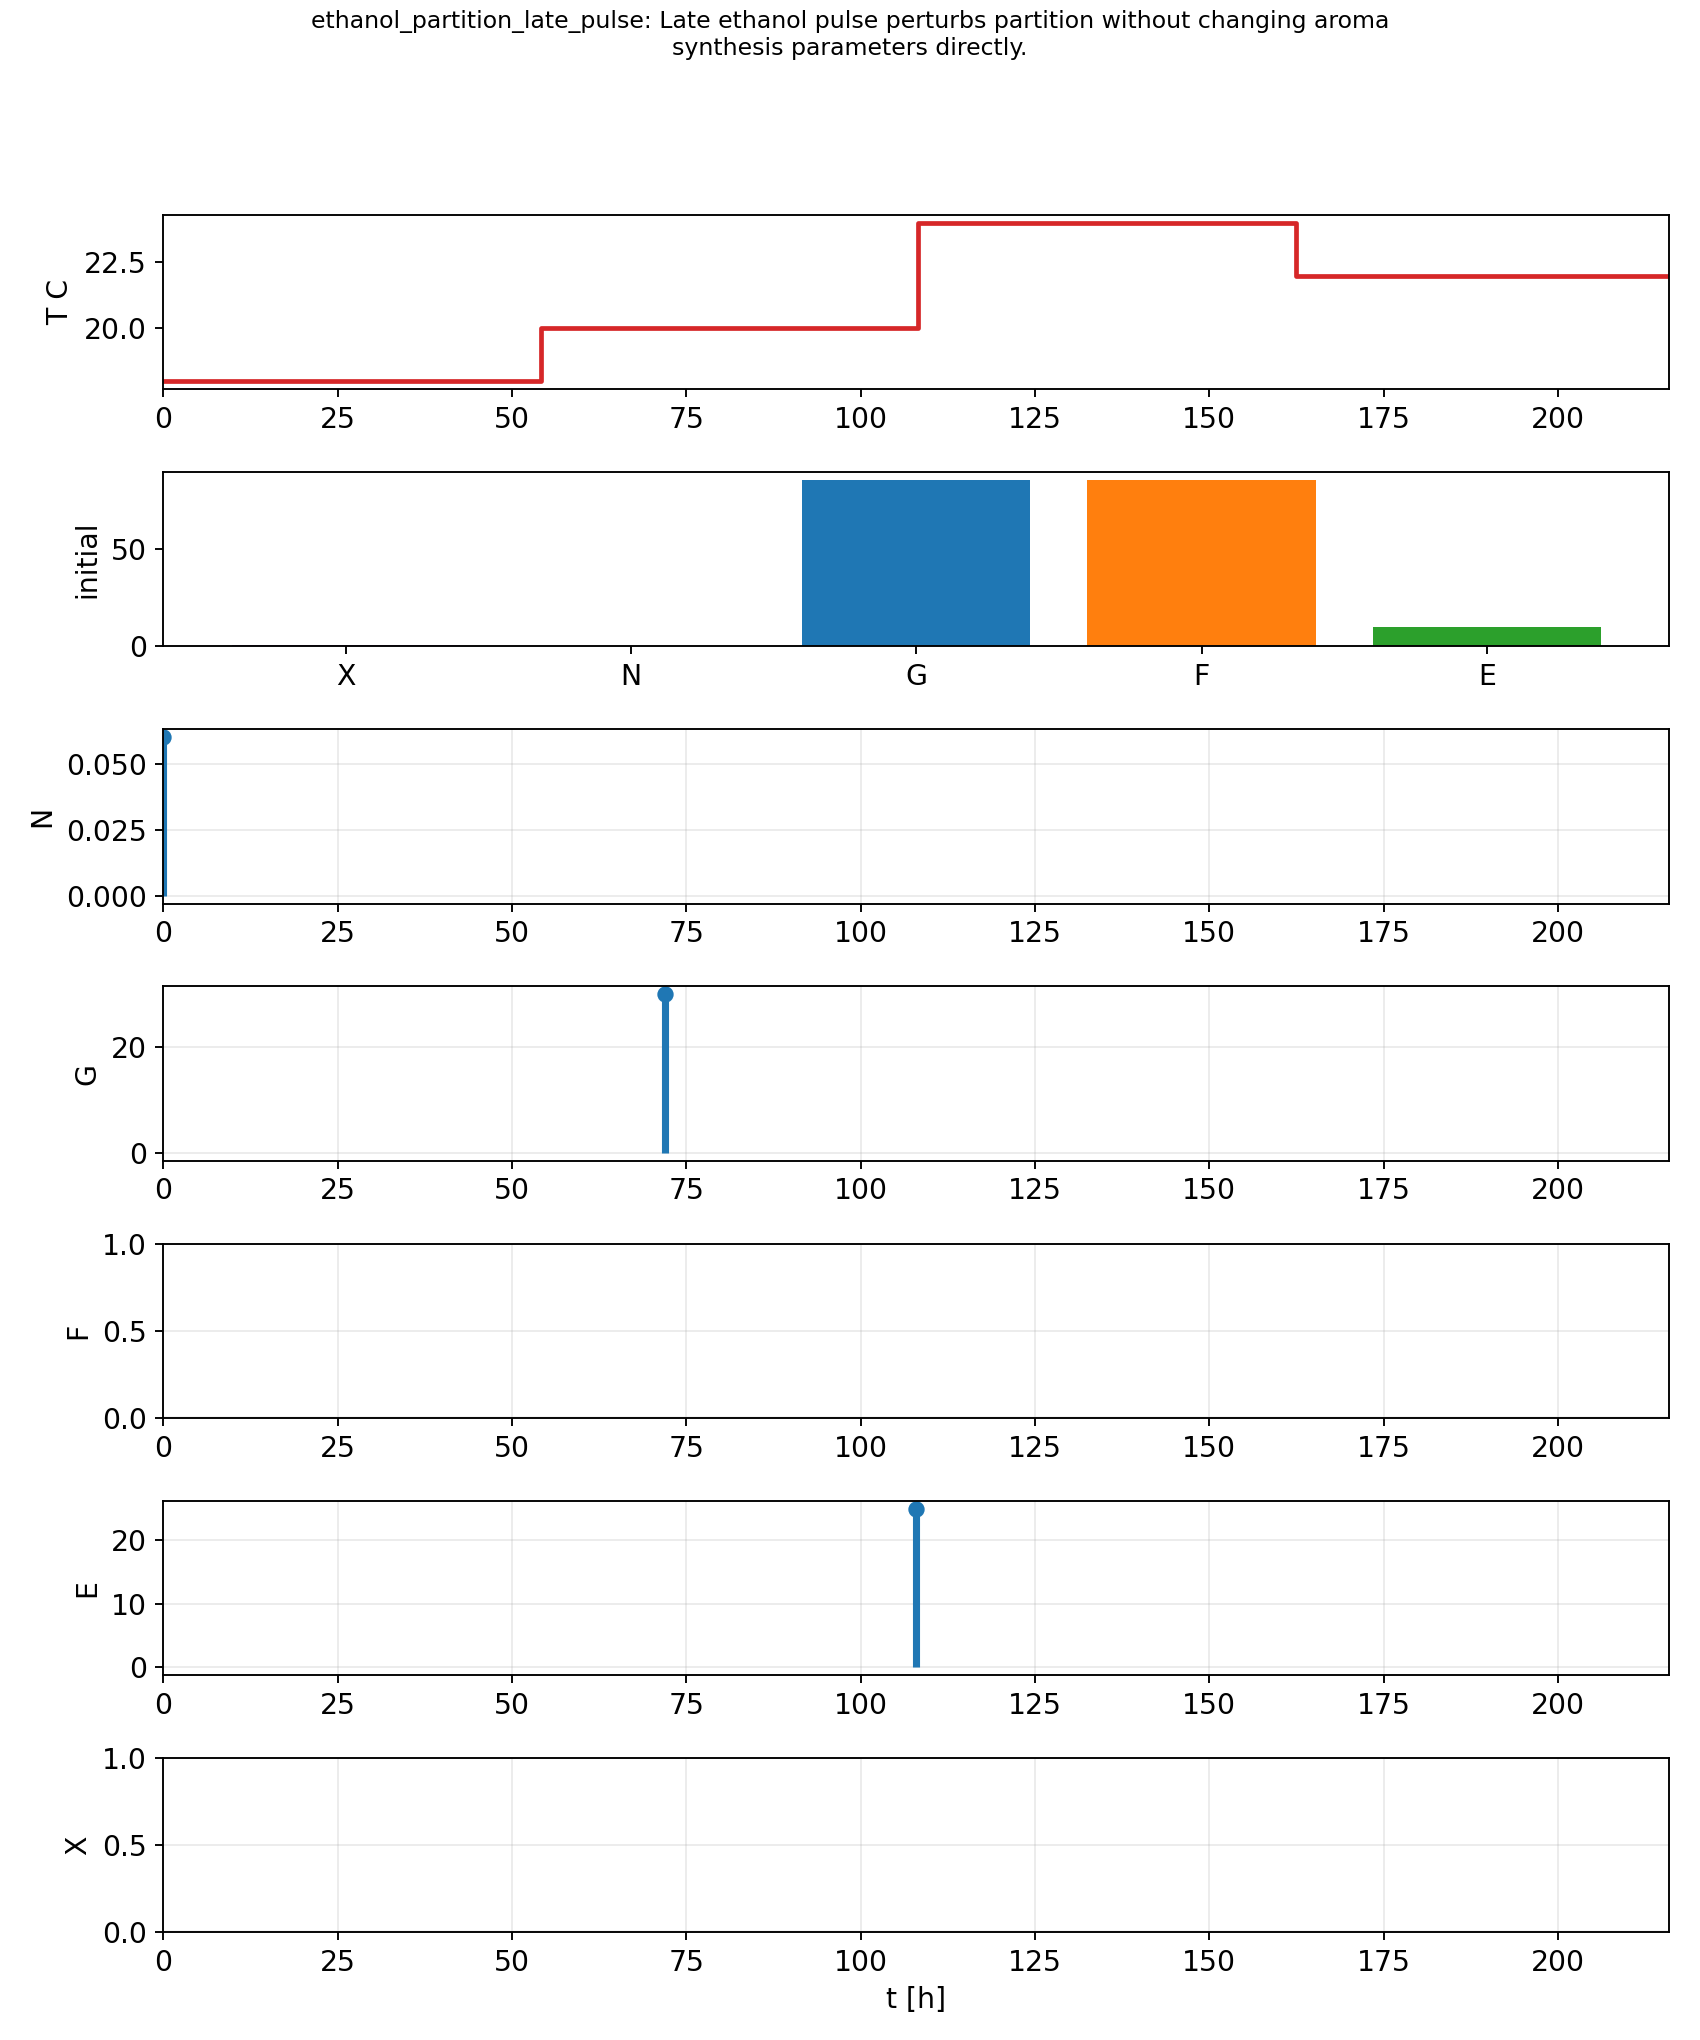

In [9]:

from IPython.display import Image, display

for name in selected["candidate"]:
    path = RESULTS / f"aroma_campaign_inputs_{name}.png"
    print(path.name)
    display(Image(filename=str(path)))



## 11. Nominal simulations

These simulations are not data fits. They verify that the selected experiments produce reasonable aroma, CO2, and fermentation trajectories under the current nominal model.


In [10]:

sim = pd.read_csv(RESULTS / "aroma_campaign_simulations.csv")
print(sim.groupby("candidate")["termination"].unique())

summary_cols = ["A_liq", "A_loss", "A_cond_final", "A_synthesis_rate", "A_loss_rate", "K_lg"]
sim.groupby(["candidate", "species"])[summary_cols].agg(["min", "max"]).round(5)


candidate
cold_synthesis_hot_stripping           [optimal]
combined_stress_long_horizon           [optimal]
ethanol_partition_late_pulse           [optimal]
fructose_rich_iG_probe                 [optimal]
glucose_rich_growth_yield              [optimal]
high_biomass_low_N_maintenance         [optimal]
hot_synthesis_cold_retention           [optimal]
low_temp_growth_separation_plus_co2    [optimal]
viable_biomass_step                    [optimal]
Name: termination, dtype: object


A_liq           A_loss  \
                                                      min       max    min   
candidate                           species                                  
cold_synthesis_hot_stripping        ethyl_acetate     0.0  42.48517    0.0   
                                    ethyl_octanoate   0.0   0.45297    0.0   
                                    isoamyl_acetate   0.0   1.80360    0.0   
combined_stress_long_horizon        ethyl_acetate     0.0  37.08698    0.0   
                                    ethyl_octanoate   0.0   0.40368    0.0   
                                    isoamyl_acetate   0.0   1.59496    0.0   
ethanol_partition_late_pulse        ethyl_acetate     0.0  35.27441    0.0   
                                    ethyl_octanoate   0.0   0.37816    0.0   
                                    isoamyl_acetate   0.0   1.50467    0.0   
fructose_rich_iG_probe              ethyl_acetate     0.0  44.19304    0.0   
                                    ethyl_octanoate   0.0   0.46607    0.0   
                                    isoamyl_acetate   0.0   1.86711    0.0   
glucose_rich_growth_yield           ethyl_acetate     0.0  41.00697    0.0   
                                    ethyl_octanoate   0.0   0.43484    0.0   
                                    isoamyl_acetate   0.0   1.73773    0.0   
high_biomass_low_N_maintenance      ethyl_acetate     0.0  28.08209    0.0   
                                    ethyl_octanoate   0.0   0.30041    0.0   
                                    isoamyl_acetate   0.0   1.20323    0.0   
hot_synthesis_cold_retention        ethyl_acetate     0.0  44.30230    0.0   
                                    ethyl_octanoate   0.0   0.46932    0.0   
                                    isoamyl_acetate   0.0   1.88105    0.0   
low_temp_growth_separation_plus_co2 ethyl_acetate     0.0  32.83702    0.0   
                                    ethyl_octanoate   0.0   0.33965    0.0   
                                    isoamyl_acetate   0.0   1.36796    0.0   
viable_biomass_step                 ethyl_acetate     0.0  40.03457    0.0   
                                    ethyl_octanoate   0.0   0.42101    0.0   
                                    isoamyl_acetate   0.0   1.69096    0.0   

                                                             A_cond_final  \
                                                         max          min   
candidate                           species                                 
cold_synthesis_hot_stripping        ethyl_acetate    5.19289      4.67360   
                                    ethyl_octanoate  0.05130      0.04361   
                                    isoamyl_acetate  0.20866      0.18362   
combined_stress_long_horizon        ethyl_acetate    3.38409      3.04568   
                                    ethyl_octanoate  0.02600      0.02210   
                                    isoamyl_acetate  0.12085      0.10634   
ethanol_partition_late_pulse        ethyl_acetate    3.27070      2.94363   
                                    ethyl_octanoate  0.03089      0.02626   
                                    isoamyl_acetate  0.12863      0.11320   
fructose_rich_iG_probe              ethyl_acetate    5.21986      4.69788   
                                    ethyl_octanoate  0.05678      0.04826   
                                    isoamyl_acetate  0.21943      0.19310   
glucose_rich_growth_yield           ethyl_acetate    5.04690      4.54221   
                                    ethyl_octanoate  0.05263      0.04473   
                                    isoamyl_acetate  0.20773      0.18280   
high_biomass_low_N_maintenance      ethyl_acetate    1.98817      1.78936   
                                    ethyl_octanoate  0.02159      0.01836   
                                    isoamyl_acetate  0.08464      0.07448   
hot_synthesis_cold_retention        ethyl_acetate    5.30297      4.77268   
                 

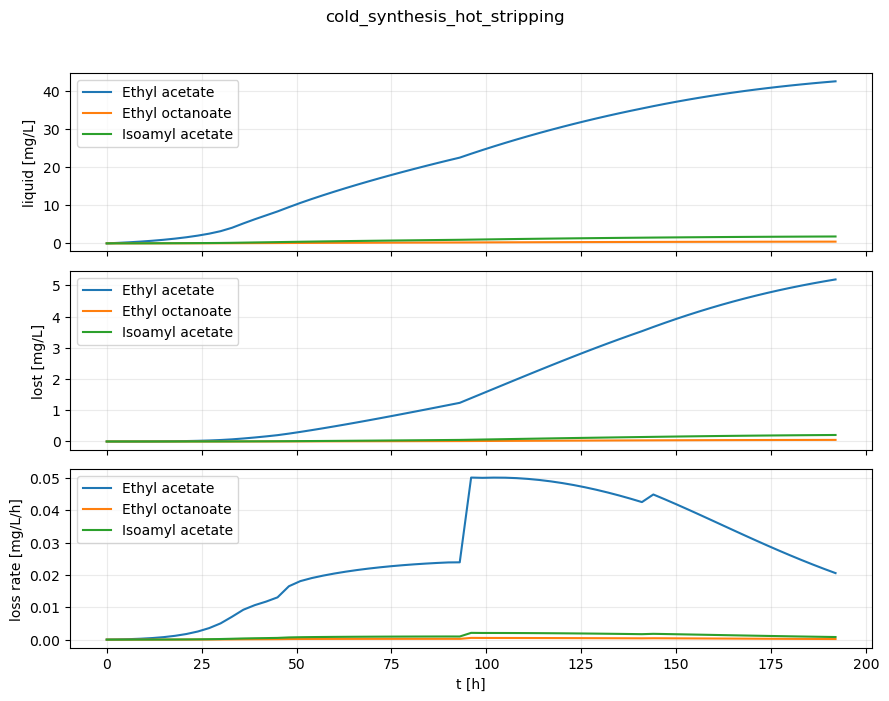

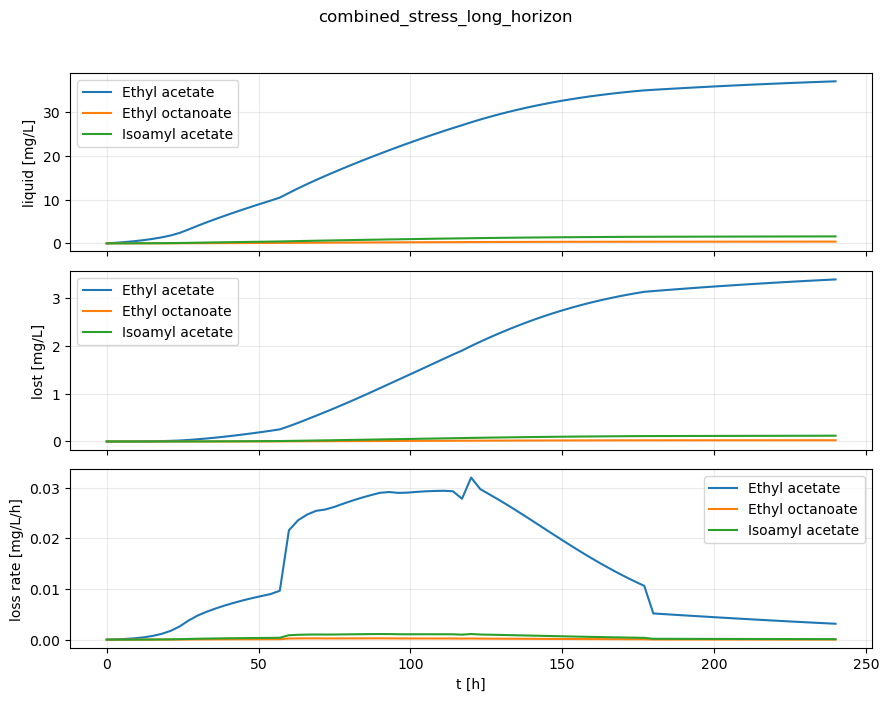

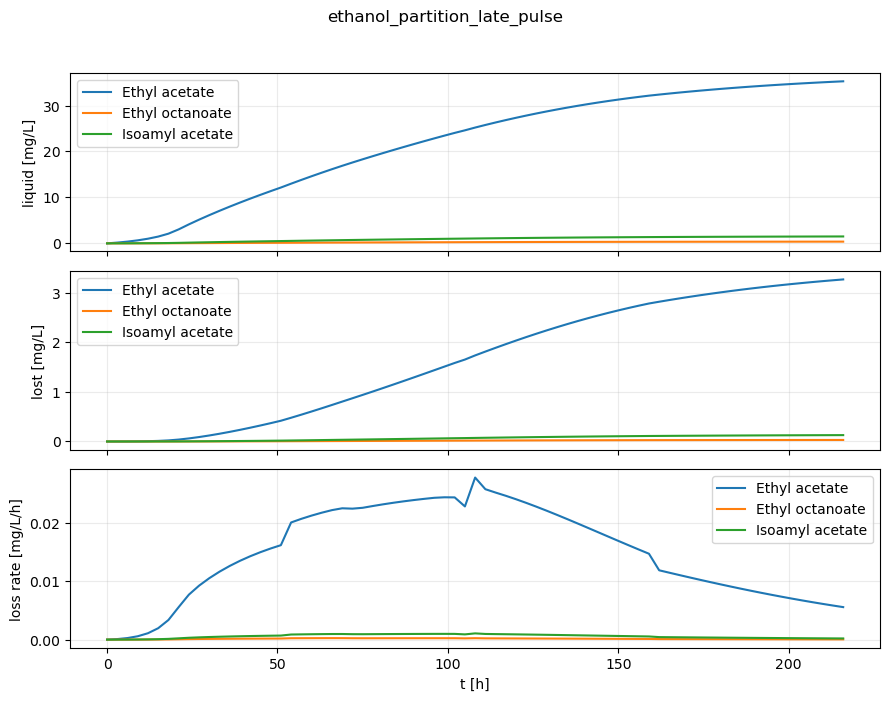

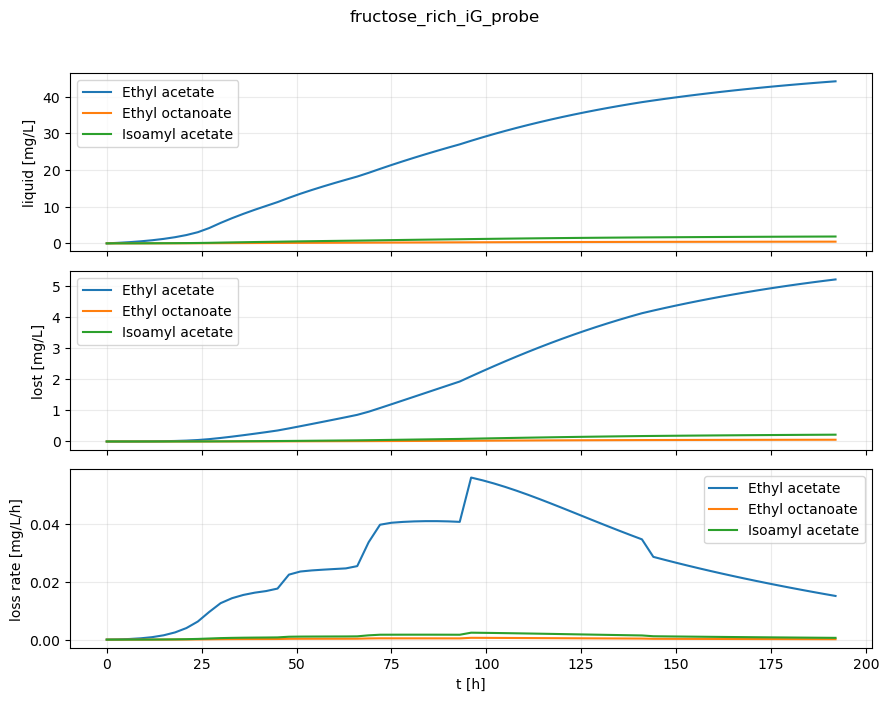

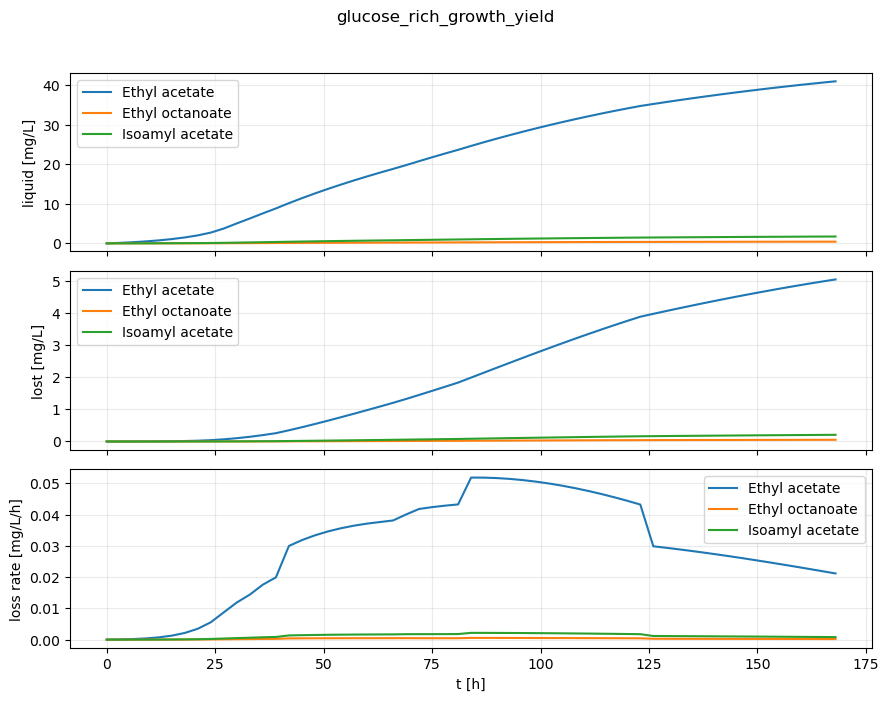

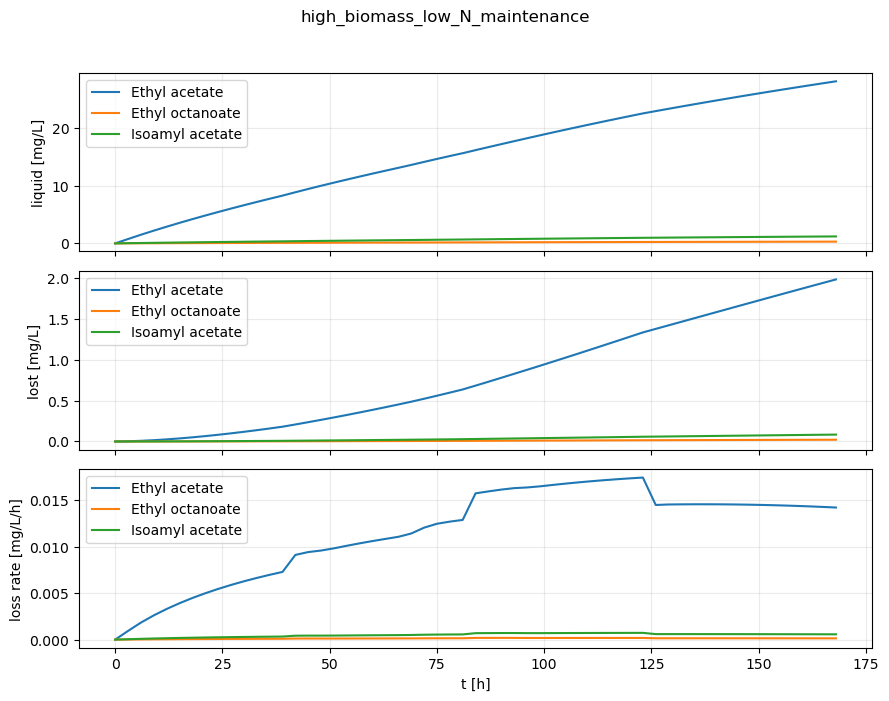

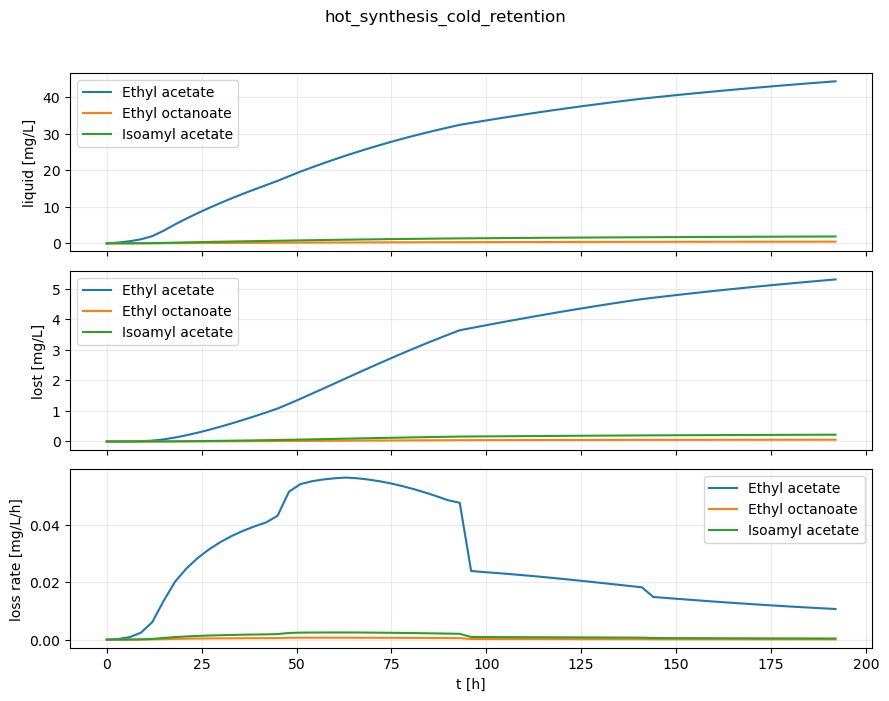

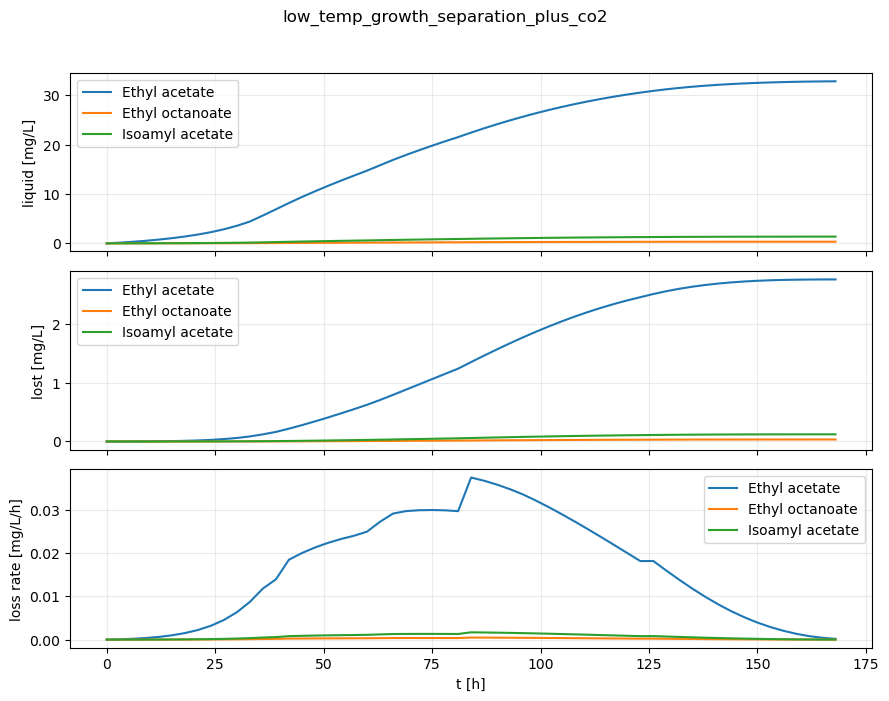

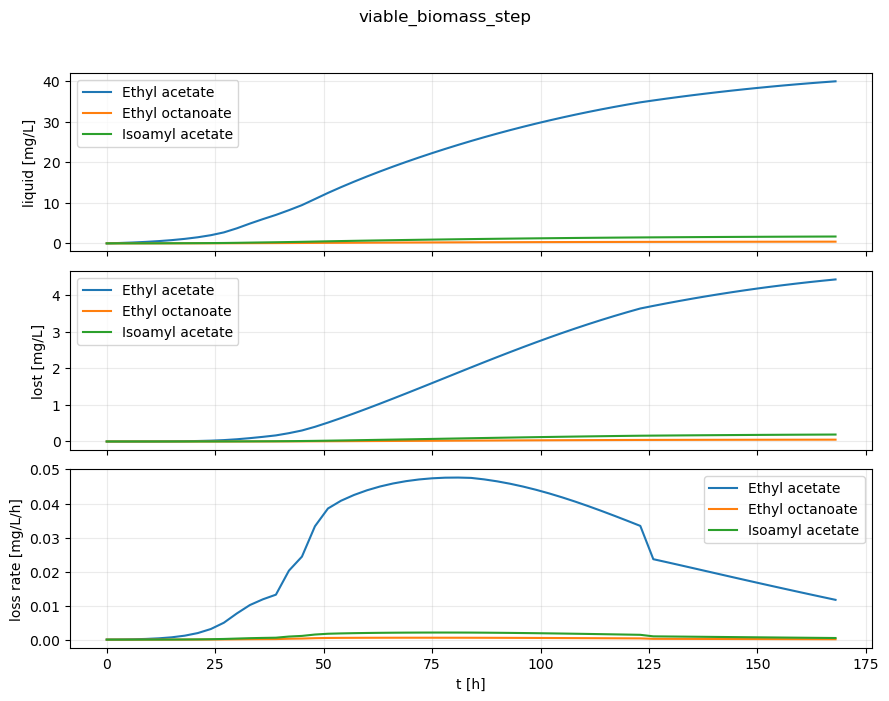

In [11]:

for candidate, group_c in sim.groupby("candidate"):
    fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
    for species, group_s in group_c.groupby("species"):
        label = aroma_doe.AROMA_LABELS[species]
        axes[0].plot(group_s["t"], group_s["A_liq"], label=label)
        axes[1].plot(group_s["t"], group_s["A_loss"], label=label)
        axes[2].plot(group_s["t"], group_s["A_loss_rate"], label=label)
    axes[0].set_ylabel("liquid [mg/L]")
    axes[1].set_ylabel("lost [mg/L]")
    axes[2].set_ylabel("loss rate [mg/L/h]")
    axes[2].set_xlabel("t [h]")
    for ax in axes:
        ax.grid(True, alpha=0.25)
        ax.legend(loc="best")
    fig.suptitle(candidate, y=0.995)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()



## 12. Identifiability interpretation

With the current measurement plan, liquid aroma time series provide dynamic information on synthesis and accumulation. The terminal condensate provides final mass closure for stripped aroma. However, one condensate sample per fermentation is not enough to infer the full gas-loss trajectory independently.

Therefore, the current recommended hierarchy is:

1. Fix \(K_i(T,E,\mathbf{x})\) from UNIFAC/Mouret-style literature information.
2. Fix or externally calibrate trap efficiency \(\eta_i\).
3. Estimate synthesis yields \(k_{i,g}\) and \(k_{i,s}\).
4. Only after that, test whether a single correction factor \(\alpha_i\) can be released.

If \(\alpha_i\) and \(\eta_i\) are both free, the final condensate approximately observes their product:

$$
A_{cond,i}(t_f) \approx \eta_i \alpha_i \int_0^{t_f} K_i(T,E) Q_{CO_2}(t) A_{L,i}(t) dt
$$

That product is practically identifiable much more easily than the two factors separately.



## 13. Next implementation steps

The next technical steps are:

1. Replace the total-sugar-as-glucose approximation with a validated fructose treatment if reliable group assignments or experimental partition data are available.
2. Add optional external calibration data for trap efficiency \(\eta_i\).
3. Re-run the aroma DOE with \(\alpha_i\) included as a sensitivity-only parameter.
4. After real data are collected, calibrate synthesis parameters with multi-start or PSO followed by a local fit.
5. Run profile likelihood for each aroma parameter and only keep parameters whose profiles close under the new data.



## 5.1 UNIFAC implementation and sugar effect

The package coverage check gave the following result:

- water: original UNIFAC assignment available;
- ethanol: original UNIFAC assignment available;
- ethyl acetate: original UNIFAC assignment available;
- isoamyl acetate: original UNIFAC assignment available;
- ethyl octanoate: original UNIFAC assignment available;
- glucose: original UNIFAC assignment available;
- fructose: no direct original DDBST-UNIFAC assignment found in this installation.

Because glucose significantly changes the predicted partition coefficient, sugar cannot be ignored. The default implementation therefore uses total residual sugar as a glucose-equivalent UNIFAC component:

$$
S_{eq}(t) = G(t) + F(t)
$$

and fits:

$$
\log K_i = b_{0,i} + b_{T,i}(T - 20) + b_{E,i}(E - 50) + b_{S,i}(S_{eq} - 100)
$$

This is a controlled approximation. It is better than ignoring sugar, but it should be replaced if a reliable fructose UNIFAC assignment or direct partition experiment becomes available.


In [12]:

partition_model = pd.read_json(RESULTS / "aroma_unifac_partition_model.json", typ="series")
partition_model["mode"], partition_model["coefficients"]


('water_ethanol_total_sugar_as_glucose',
 {'ethyl_acetate': {'K20': 0.004436873104876,
   'logK_ref': -5.417805406301014,
   'temp_slope': 0.041944692737759005,
   'ethanol_slope': -0.004435874095101,
   'sugar_slope': -0.001294685911279,
   'fit_rmse_log': 0.016141439689987002,
   'fit_max_abs_log_error': 0.050775890184795,
   'mode': 'water_ethanol_total_sugar_as_glucose',
   'source': 'thermo original UNIFAC, dilute aroma, fitted log-linear surrogate',
   'trap_efficiency': 0.9},
  'isoamyl_acetate': {'K20': 0.0046866429873590005,
   'logK_ref': -5.363038733764239,
   'temp_slope': 0.050548239029352,
   'ethanol_slope': -0.008398256814164,
   'sugar_slope': -0.002839994124788,
   'fit_rmse_log': 0.023795486485307,
   'fit_max_abs_log_error': 0.07734302144577601,
   'mode': 'water_ethanol_total_sugar_as_glucose',
   'source': 'thermo original UNIFAC, dilute aroma, fitted log-linear surrogate',
   'trap_efficiency': 0.88},
  'ethyl_octanoate': {'K20': 0.005096307202607,
   'logK_ref':

In [13]:

assignments = pd.DataFrame(partition_model["assignments"]).T
assignments[["name", "available", "CAS", "InChI_key", "groups", "error"]]


,name,available,CAS,InChI_key,groups,error
water,water,True,7732-18-5,XLYOFNOQVPJJNP-UHFFFAOYSA-N,{'16': 1},NaN
ethanol,ethanol,True,64-17-5,LFQSCWFLJHTTHZ-UHFFFAOYSA-N,"{'1': 1, '2': 1, '14': 1}",NaN
glucose,glucose,True,50-99-7,GZCGUPFRVQAUEE-SLPGGIOYSA-N,"{'2': 1, '3': 4, '14': 5, '20': 1}",NaN
fructose,fructose,False,NaN,NaN,NaN,UNIFACUnavailable: No DDBST original-UNIFAC gr...
ethyl_acetate,ethyl acetate,True,141-78-6,XEKOWRVHYACXOJ-UHFFFAOYSA-N,"{'1': 1, '2': 1, '21': 1}",NaN
isoamyl_acetate,isoamyl acetate,True,123-92-2,MLFHJEHSLIIPHL-UHFFFAOYSA-N,"{'1': 2, '2': 2, '3': 1, '21': 1}",NaN
ethyl_octanoate,ethyl octanoate,True,106-32-1,YYZUSRORWSJGET-UHFFFAOYSA-N,"{'1': 2, '2': 6, '22': 1}",NaN


## 14. Joint fermentation-aroma DOE

The previous aroma section was intentionally narrow: the DoE target was the aroma synthesis vector only,

$$
\theta_A = [k_{EA,g}, k_{EA,s}, k_{IAA,g}, k_{IAA,s}, k_{EO,g}, k_{EO,s}]^T,
$$

while the fermentation kinetic model was treated as fixed at the reduced calibrated point. That is useful for checking whether aroma measurements and the final condensate can identify aroma production constants, but it is not the final campaign design if the fermentation backbone is still uncertain.

For the final campaign design we therefore use a joint target vector,

$$
\theta_{\mathrm{joint}} = [\theta_F, \theta_A]^T,
$$

where

$$
\theta_F = [\mu_0, s_N, q_N, q_{XG}, q_{XF}, \beta_{G0}, s_G, \beta_{F0}, s_F, q_{EG}, q_{EF}, i_G, i_E, K_{d0}, m_0]^T.
$$

The prior information matrix is assembled as a block prior,

$$
F_{\mathrm{prior}} =
\begin{bmatrix}
F_{\mathrm{hist},F} & 0 \\
0 & F_{\mathrm{lit},A}
\end{bmatrix},
$$

where \(F_{\mathrm{hist},F}\) is the historical fermentation FIM obtained from the available fermentation experiments, and \(F_{\mathrm{lit},A}\) is a diagonal literature/engineering prior for the aroma synthesis parameters. The candidate campaign is scored by the posterior FIM,

$$
F_{\mathrm{post}}(\xi) = F_{\mathrm{prior}} + \sum_{e \in \xi} F_e,
$$

using D-optimality as the primary score, with variance reduction and conditioning used as diagnostics. The measured outputs include fermentation states, online \(CO_2\), liquid aroma concentrations, and one terminal condensate mass per aroma species.

In [14]:
JOINT_RESULTS = FERM / "results" / "aroma_joint_campaign_doe"
RUN_LONG_JOINT_DOE = False

if RUN_LONG_JOINT_DOE:
    subprocess.run([
        sys.executable,
        str(SCRIPT),
        "--parameter-mode", "joint_full",
        "--campaign-size", "9",
        "--partition-mode", "water_ethanol_total_sugar_as_glucose",
    ], cwd=str(ROOT), check=True)

joint_selected = pd.read_csv(JOINT_RESULTS / "aroma_campaign_selected.csv")
joint_ranking = pd.read_csv(JOINT_RESULTS / "aroma_candidate_ranking.csv")
joint_protocols = pd.read_csv(JOINT_RESULTS / "aroma_campaign_protocols.csv")
joint_pulses = pd.read_csv(JOINT_RESULTS / "aroma_campaign_pulses.csv")
joint_param_reduction = pd.read_csv(JOINT_RESULTS / "aroma_campaign_parameter_reduction.csv")
joint_metadata = pd.read_json(JOINT_RESULTS / "aroma_campaign_metadata.json", typ="series")

joint_metadata[["parameter_mode", "partition_mode", "n_successful_candidates"]]

parameter_mode                                       joint_full
partition_mode             water_ethanol_total_sugar_as_glucose
n_successful_candidates                                      11
dtype: object

### 14.1 Why the campaign changes when fermentation parameters are included

The aroma-only campaign maximizes information for \(\theta_A\) conditional on the fermentation model being known. The joint campaign must also protect directions in \(\theta_F\), especially nitrogen saturation, sugar uptake, ethanol inhibition, maintenance, and death terms. This shifts the selected set toward experiments that introduce sugar-ratio, nitrogen-ladder, biomass, ethanol, and late-pulse contrasts, while still retaining temperature switches and aroma mass-closure measurements.

The aroma-only and joint metrics below are not dimensionally comparable as absolute condition numbers because the parameter dimensions differ: aroma-only uses six parameters, whereas the joint design uses twenty-one. The comparison is useful to verify the trade-off: aroma parameters remain highly estimable, but the design now spends experiments on the fermentation directions that would otherwise bias aroma synthesis estimates.

In [15]:
def final_metrics(frame, label):
    last = frame.iloc[-1]
    return {
        "design": label,
        "n_parameters": 6 if label == "aroma_only" else len(joint_metadata["parameters"]),
        "n_experiments": int(last["campaign_order"]),
        "mean_var_reduction": float(last["mean_var_reduction"]),
        "worst_var_reduction": float(last["worst_var_reduction"]),
        "condition_number": float(last["campaign_condition_number"]),
    }

comparison = pd.DataFrame([
    final_metrics(selected, "aroma_only"),
    final_metrics(joint_selected, "joint_full"),
])
comparison

,design,n_parameters,n_experiments,mean_var_reduction,worst_var_reduction,condition_number
0,aroma_only,6,9,0.995382,0.986643,3682.624471
1,joint_full,21,9,0.973679,0.768944,77161.985209


In [16]:
joint_selected[selected_cols]

,campaign_order,candidate,family,horizon_h,temperature_c,campaign_logdet,campaign_min_relative_eigenvalue,campaign_condition_number,mean_var_reduction,worst_var_reduction,rationale
0,1,fructose_rich_iG_probe,sugar_initial,192.0,"18, 20, 24, 22",115.983629,0.000004,251595.012239,0.841626,0.302350,Fructose-rich must plus glucose pulse separate...
1,2,cold_synthesis_hot_stripping,aroma_partition,192.0,"15, 16, 24, 25",129.768926,0.000004,266112.849937,0.905601,0.479869,Low-temperature synthesis window followed by h...
2,3,low_temp_growth_separation_plus_co2,legacy_plus,168.0,"15, 17, 20, 22",135.930811,0.000009,113238.579884,0.931126,0.541207,"Previous robust N/T design, now measured with ..."
3,4,combined_stress_long_horizon,integrated,240.0,"15, 22, 25, 18",143.207772,0.000008,132788.287202,0.942065,0.566126,Broad stress/input design for integrated all-p...
4,5,yan_saturation_scan,saturation,144.0,"15, 18, 22, 22",145.211494,0.000009,116374.739104,0.957640,0.712291,Designed N ladder through low/intermediate YAN...
5,6,glucose_rich_growth_yield,sugar_initial,168.0,"18, 22, 24, 20",149.394019,0.000010,100750.465374,0.965031,0.730844,High glucose must isolates glucose growth/ferm...
6,7,high_biomass_low_N_maintenance,maintenance,168.0,"16, 18, 20, 18",152.425455,0.000012,84859.733839,0.968769,0.734643,High biomass and low N create low-growth sugar...
7,8,ethanol_initial_challenge,ethanol,192.0,"18, 22, 25, 22",154.451910,0.000012,83379.197951,0.971282,0.754084,Initial ethanol decouples ethanol inhibition i...
8,9,glucose_pulse_after_N_depletion,pulse_separation,192.0,"17, 20, 24, 22",155.980425,0.000013,77161.985209,0.973679,0.768944,Glucose pulse after likely N limitation separa...


In [17]:
joint_protocols[protocol_cols]

,candidate,family,horizon_h,temperature_c,X0,N0,G0,F0,E0,Xd0,rationale
0,fructose_rich_iG_probe,sugar_initial,192.0,"18, 20, 24, 22",0.45,0.260,25.0,150.0,0.0,0.0,Fructose-rich must plus glucose pulse separate...
1,cold_synthesis_hot_stripping,aroma_partition,192.0,"15, 16, 24, 25",0.50,0.240,95.0,95.0,0.0,0.0,Low-temperature synthesis window followed by h...
2,low_temp_growth_separation_plus_co2,legacy_plus,168.0,"15, 17, 20, 22",0.55,0.240,75.0,70.0,0.0,0.0,"Previous robust N/T design, now measured with ..."
3,combined_stress_long_horizon,integrated,240.0,"15, 22, 25, 18",0.70,0.200,110.0,110.0,15.0,0.0,Broad stress/input design for integrated all-p...
4,yan_saturation_scan,saturation,144.0,"15, 18, 22, 22",0.35,0.035,90.0,90.0,0.0,0.0,Designed N ladder through low/intermediate YAN...
5,glucose_rich_growth_yield,sugar_initial,168.0,"18, 22, 24, 20",0.45,0.260,150.0,25.0,0.0,0.0,High glucose must isolates glucose growth/ferm...
6,high_biomass_low_N_maintenance,maintenance,168.0,"16, 18, 20, 18",2.20,0.025,70.0,70.0,15.0,0.0,High biomass and low N create low-growth sugar...
7,ethanol_initial_challenge,ethanol,192.0,"18, 22, 25, 22",0.60,0.220,90.0,90.0,35.0,0.0,Initial ethanol decouples ethanol inhibition i...
8,glucose_pulse_after_N_depletion,pulse_separation,192.0,"17, 20, 24, 22",0.55,0.055,45.0,85.0,0.0,0.0,Glucose pulse after likely N limitation separa...


In [18]:
joint_pulses.sort_values(["candidate", "channel", "time_h"])

,candidate,family,channel,time_h,amount
5,cold_synthesis_hot_stripping,aroma_partition,G,96.0,35.000
3,cold_synthesis_hot_stripping,aroma_partition,N,0.0,0.080
4,cold_synthesis_hot_stripping,aroma_partition,N,48.0,0.050
13,combined_stress_long_horizon,integrated,E,120.0,20.000
12,combined_stress_long_horizon,integrated,F,96.0,25.000
11,combined_stress_long_horizon,integrated,G,72.0,25.000
9,combined_stress_long_horizon,integrated,N,0.0,0.050
10,combined_stress_long_horizon,integrated,N,60.0,0.050
23,ethanol_initial_challenge,ethanol,N,0.0,0.070
24,ethanol_initial_challenge,ethanol,N,48.0,0.050


### 14.2 Joint estimability diagnostics

The table below reports the approximate posterior variance reduction for each parameter. Parameters with lower reductions remain the practical weak directions under the current measurement plan and admissible inputs. These are the parameters that should drive further campaign refinement, additional measurements, or stronger priors.

In this run, aroma synthesis parameters remain well supported because the campaign includes liquid aroma trajectories plus terminal condensate mass. The weakest direction remains in the fermentation block, dominated by nitrogen saturation \(s_N\). That is a data/process-design limitation rather than an aroma measurement limitation.

In [19]:
joint_param_reduction.sort_values("campaign_var_reduction", ascending=True)

,parameter,group,campaign_var_ratio,campaign_var_reduction
1,sN,fermentation,0.231056,0.768944
2,qN,fermentation,0.068591,0.931409
0,mu0,fermentation,0.046724,0.953276
8,sF,fermentation,0.044239,0.955761
6,sG,fermentation,0.022701,0.977299
3,qXG,fermentation,0.018863,0.981137
4,qXF,fermentation,0.017780,0.982220
9,qEG,fermentation,0.017389,0.982611
12,iE,fermentation,0.016058,0.983942
14,m0,fermentation,0.015884,0.984116


In [20]:
joint_group_summary = (
    joint_param_reduction
    .groupby("group")["campaign_var_reduction"]
    .agg(["count", "mean", "min", "max"])
    .sort_index()
)
joint_group_summary

,count,mean,min,max
group,,,,
fermentation,15,0.965313,0.768944,0.999041
synthesis,6,0.994593,0.984554,0.999982


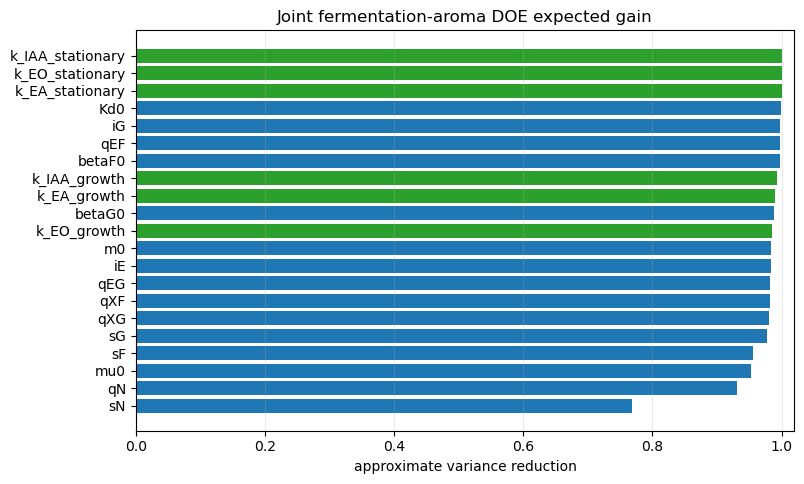

In [21]:
fig, ax = plt.subplots(figsize=(8.5, 5.2))
plot_df = joint_param_reduction.sort_values("campaign_var_reduction")
colors = plot_df["group"].map({"fermentation": "tab:blue", "synthesis": "tab:green"}).fillna("tab:gray")
ax.barh(plot_df["parameter"], plot_df["campaign_var_reduction"], color=colors)
ax.set_xlabel("approximate variance reduction")
ax.set_xlim(0, 1.02)
ax.grid(axis="x", alpha=0.25)
ax.set_title("Joint fermentation-aroma DOE expected gain")
plt.show()

### 14.3 Candidate feasibility and selected inputs

All selected experiments solved to optimality in the nominal simulation check. Two candidate protocols were rejected by the workflow because the Pyomo experiment model did not solve reliably; they are kept in the ranking table with a failed status, but they are not part of the proposed campaign.

In [22]:
failed_joint = joint_ranking[joint_ranking["status"] != "ok"]
failed_joint[["candidate", "family", "status", "error"]]

,candidate,family,status,error
11,hot_synthesis_cold_retention,aroma_partition,failed,RuntimeError: Model from experiment did not so...
12,co2_stripping_without_growth,aroma_partition,failed,RuntimeError: Model from experiment did not so...


In [23]:
joint_sim = pd.read_csv(JOINT_RESULTS / "aroma_campaign_simulations.csv")
joint_sim.groupby("candidate")["termination"].unique()

candidate
cold_synthesis_hot_stripping           [optimal]
combined_stress_long_horizon           [optimal]
ethanol_initial_challenge              [optimal]
fructose_rich_iG_probe                 [optimal]
glucose_pulse_after_N_depletion        [optimal]
glucose_rich_growth_yield              [optimal]
high_biomass_low_N_maintenance         [optimal]
low_temp_growth_separation_plus_co2    [optimal]
yan_saturation_scan                    [optimal]
Name: termination, dtype: object

aroma_campaign_inputs_fructose_rich_iG_probe.png


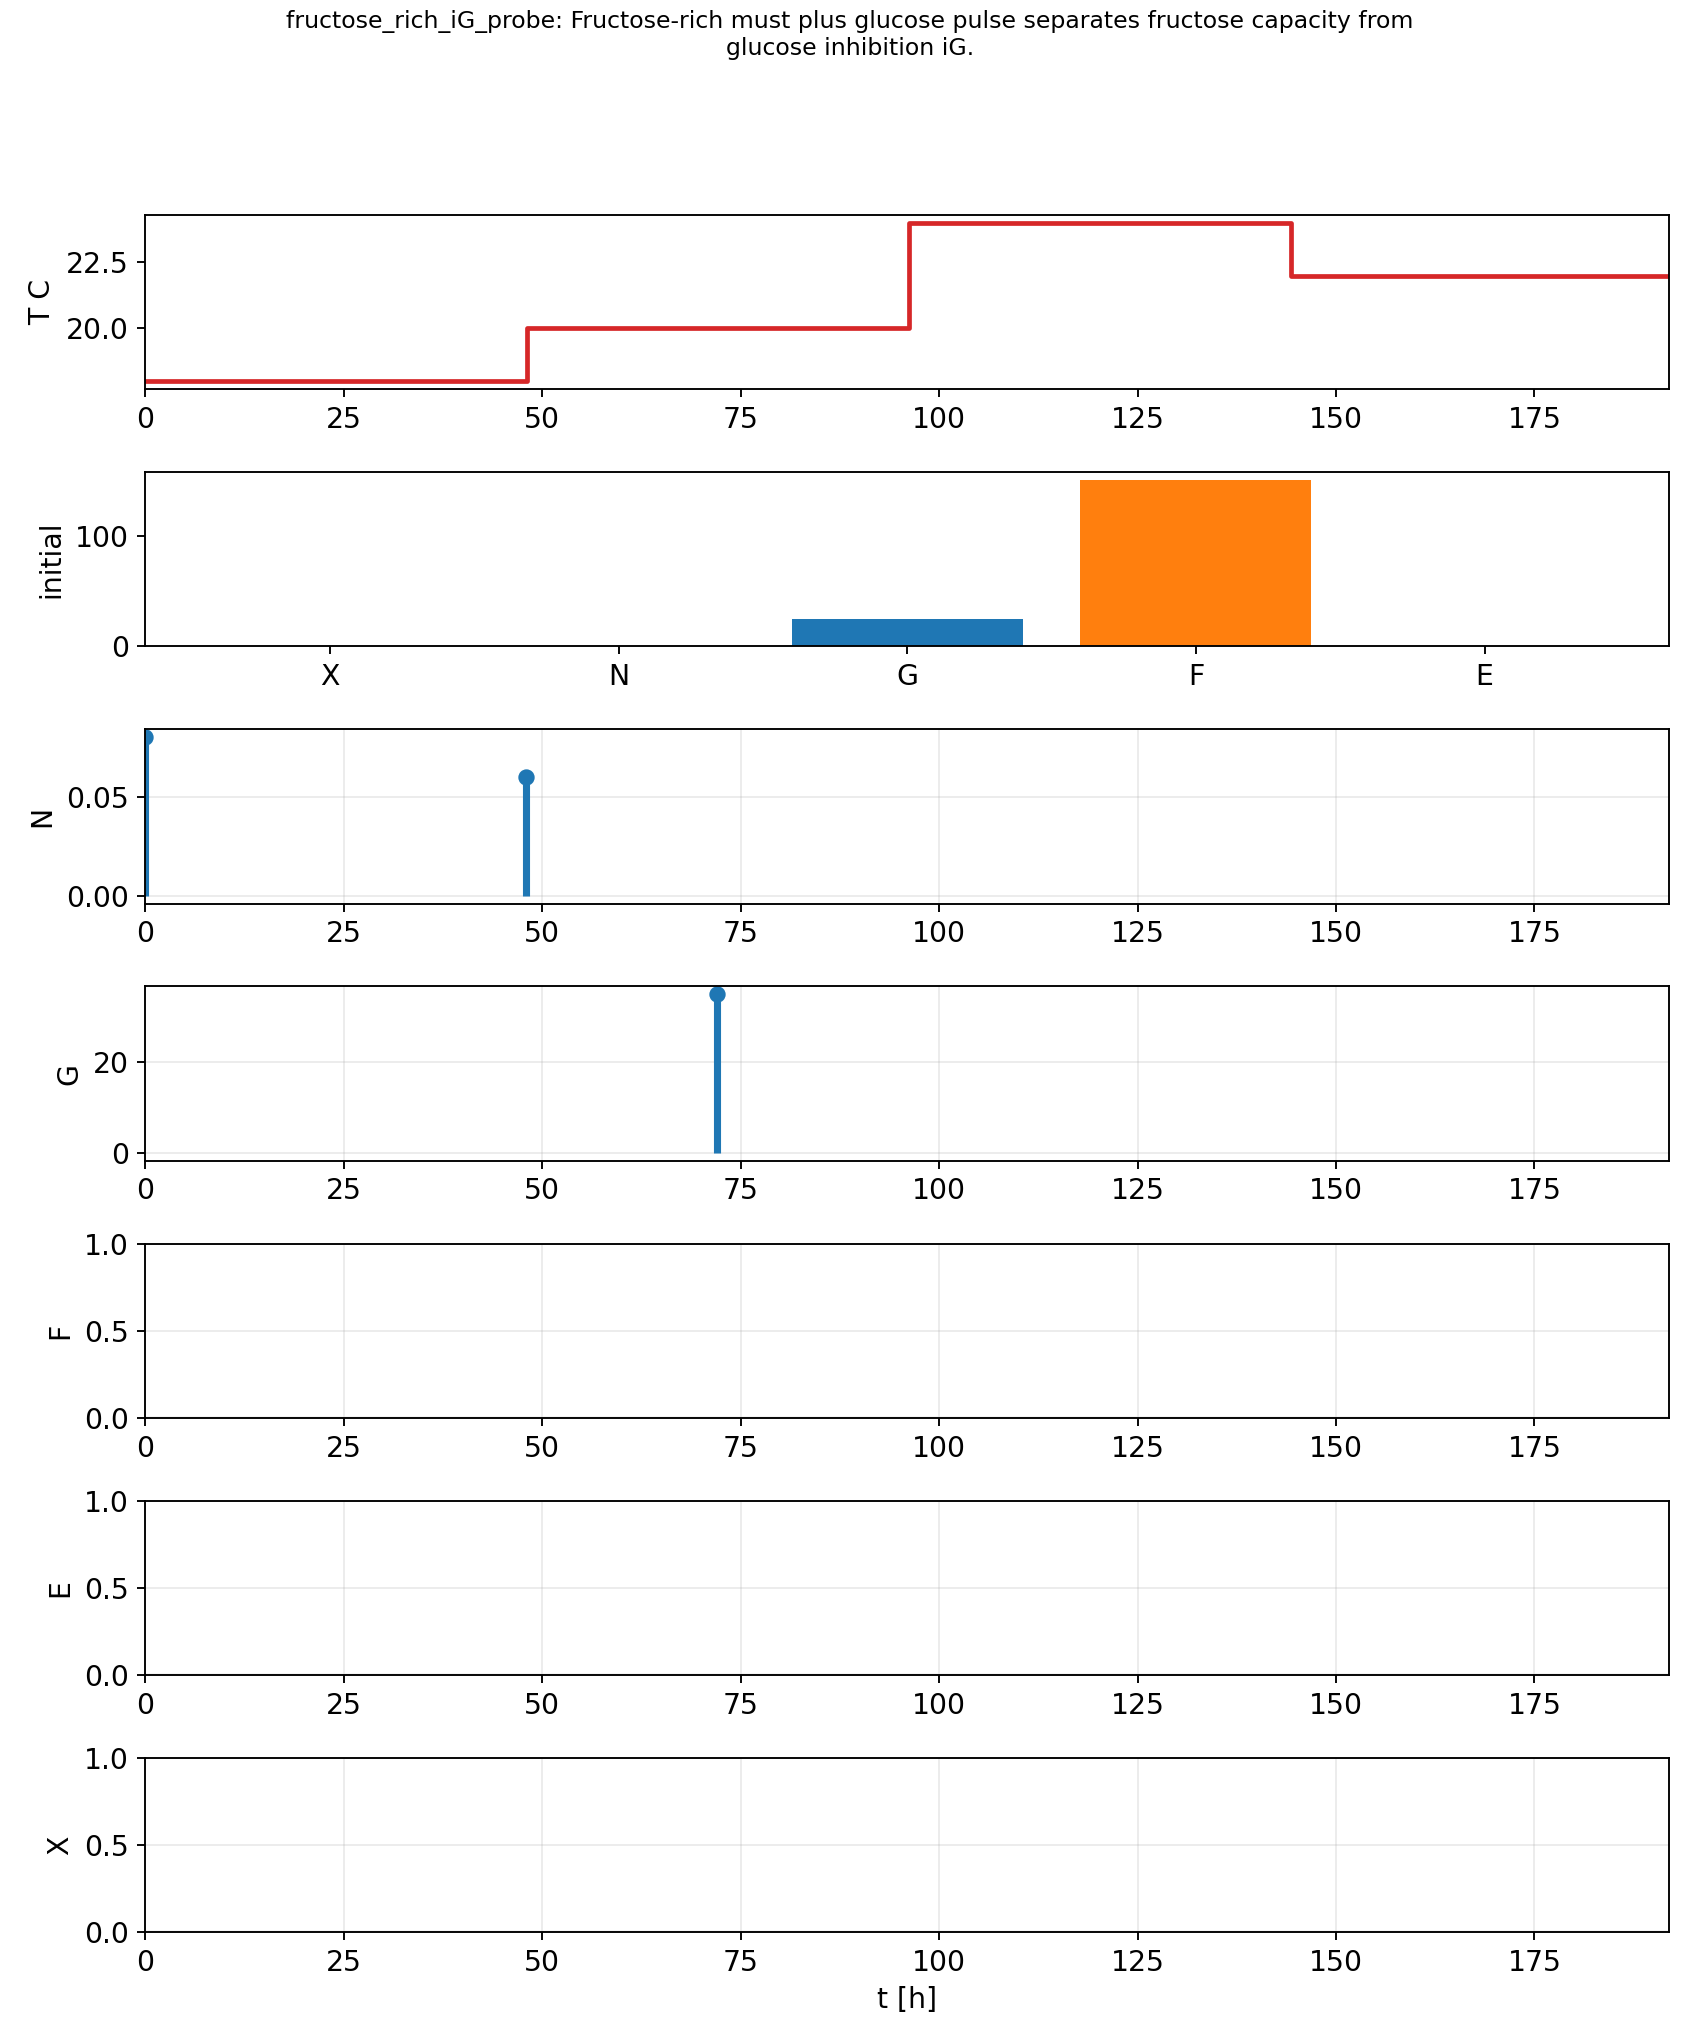

aroma_campaign_inputs_cold_synthesis_hot_stripping.png


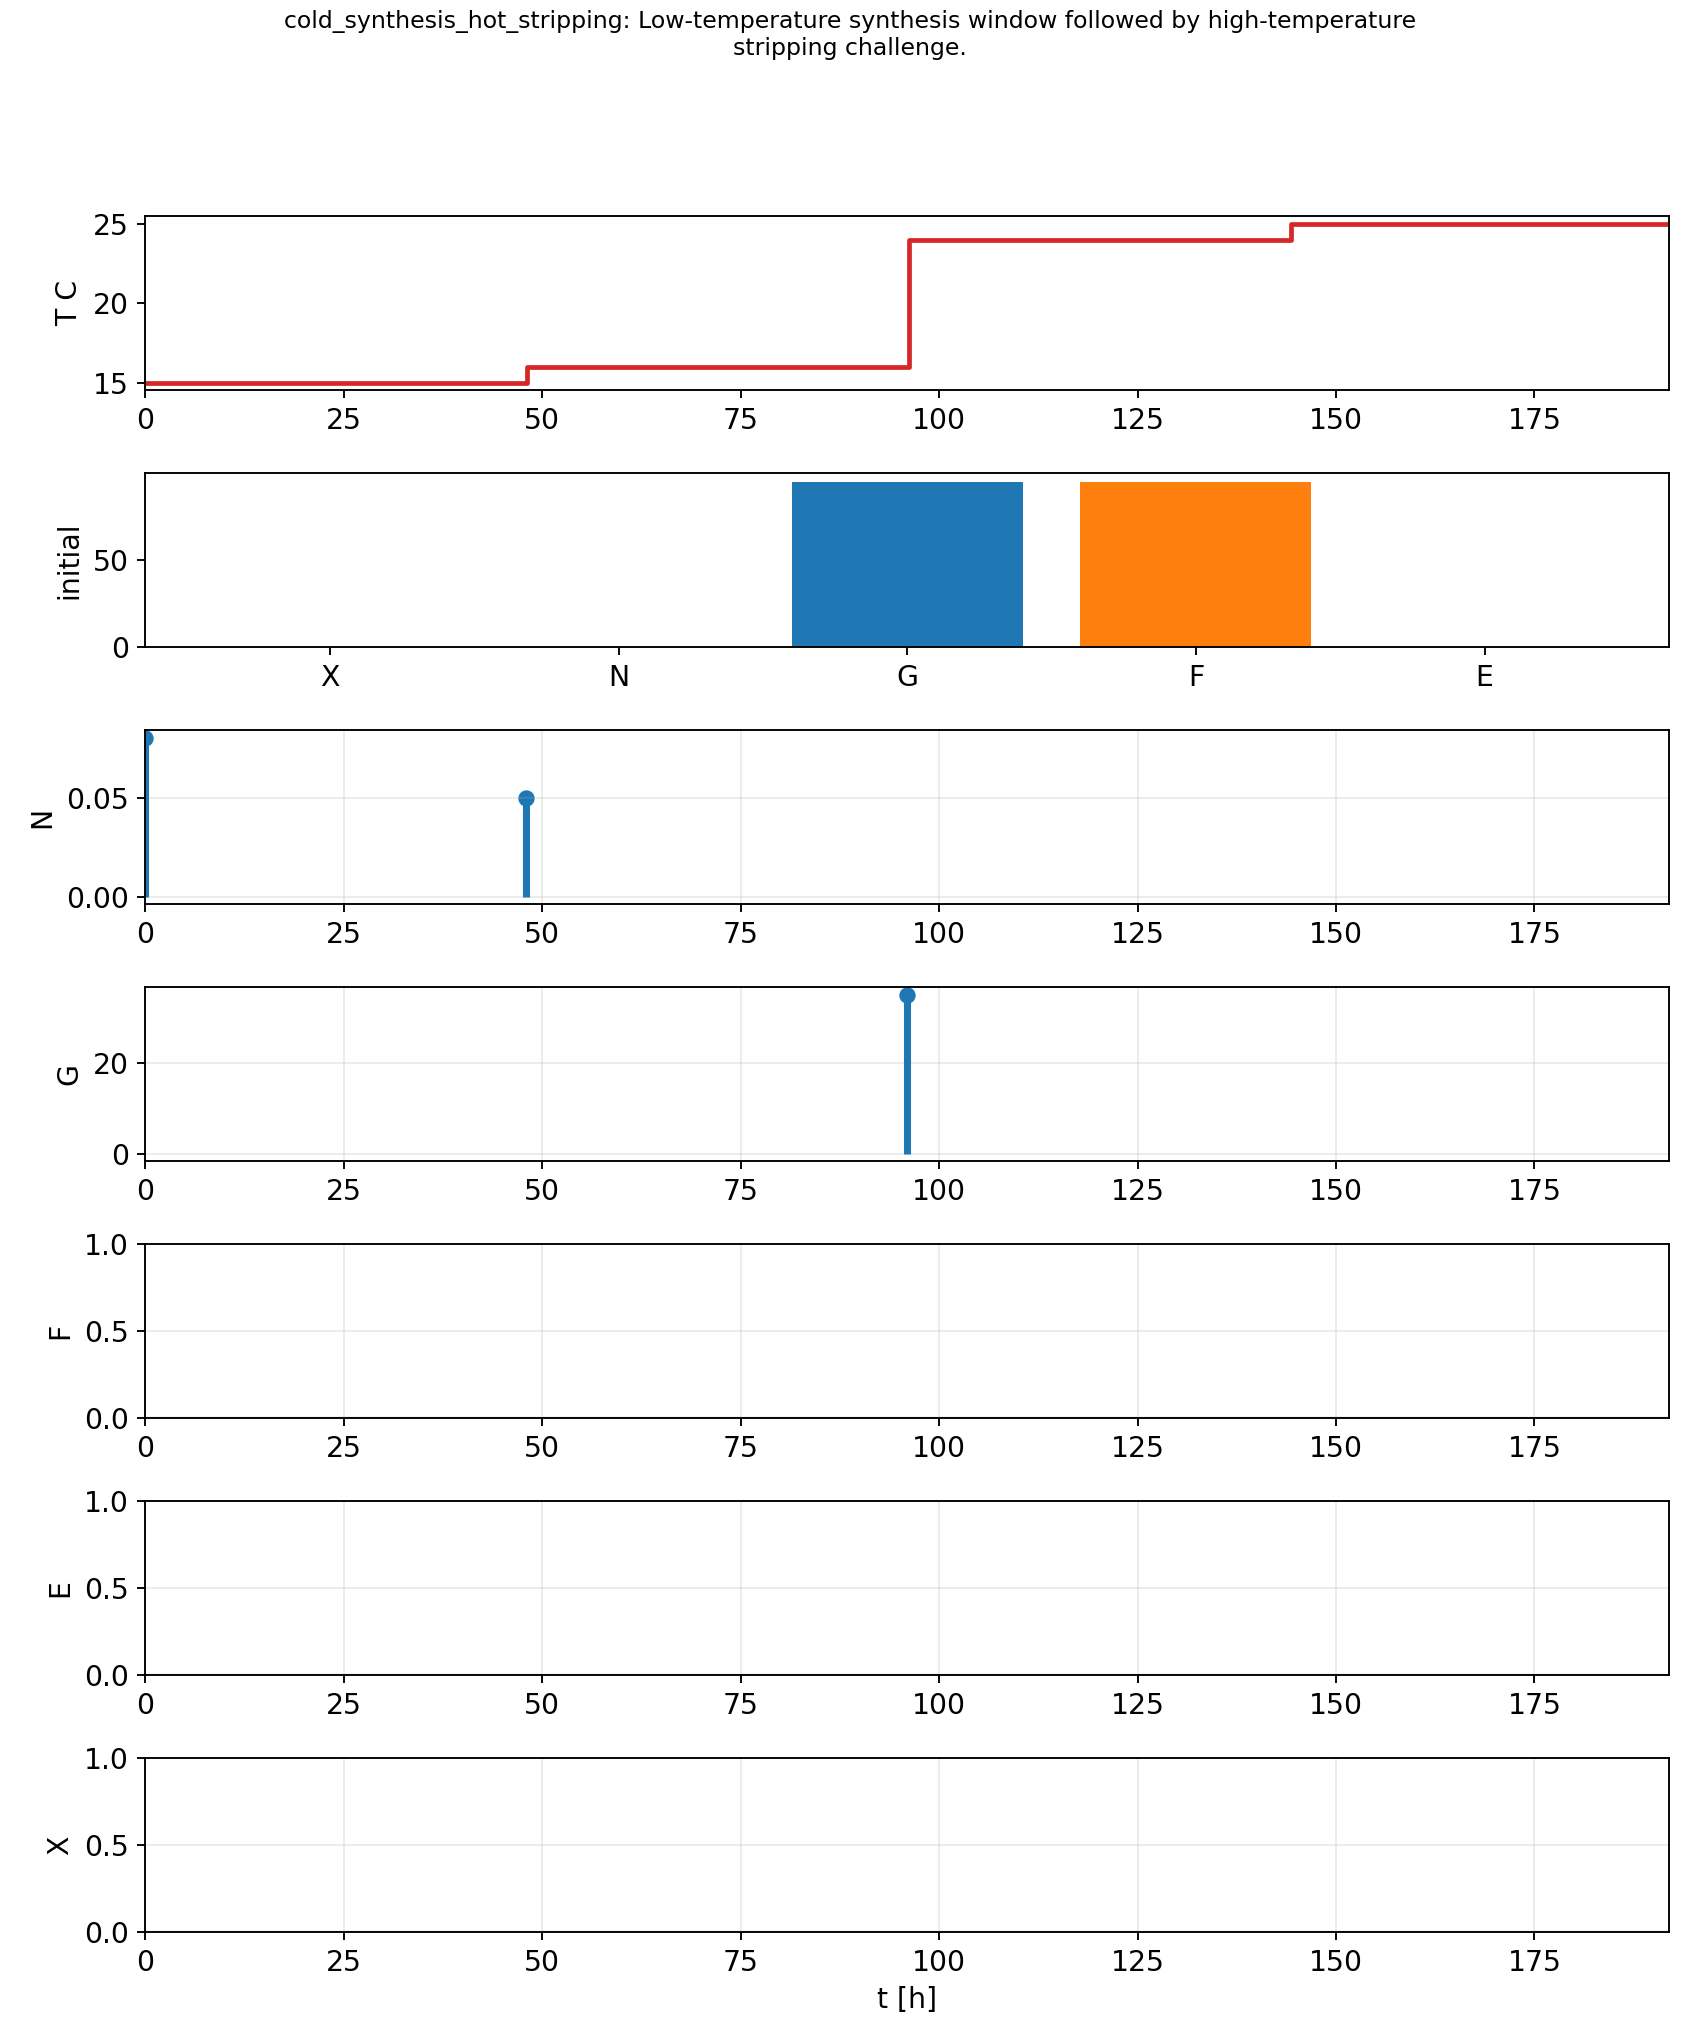

aroma_campaign_inputs_low_temp_growth_separation_plus_co2.png


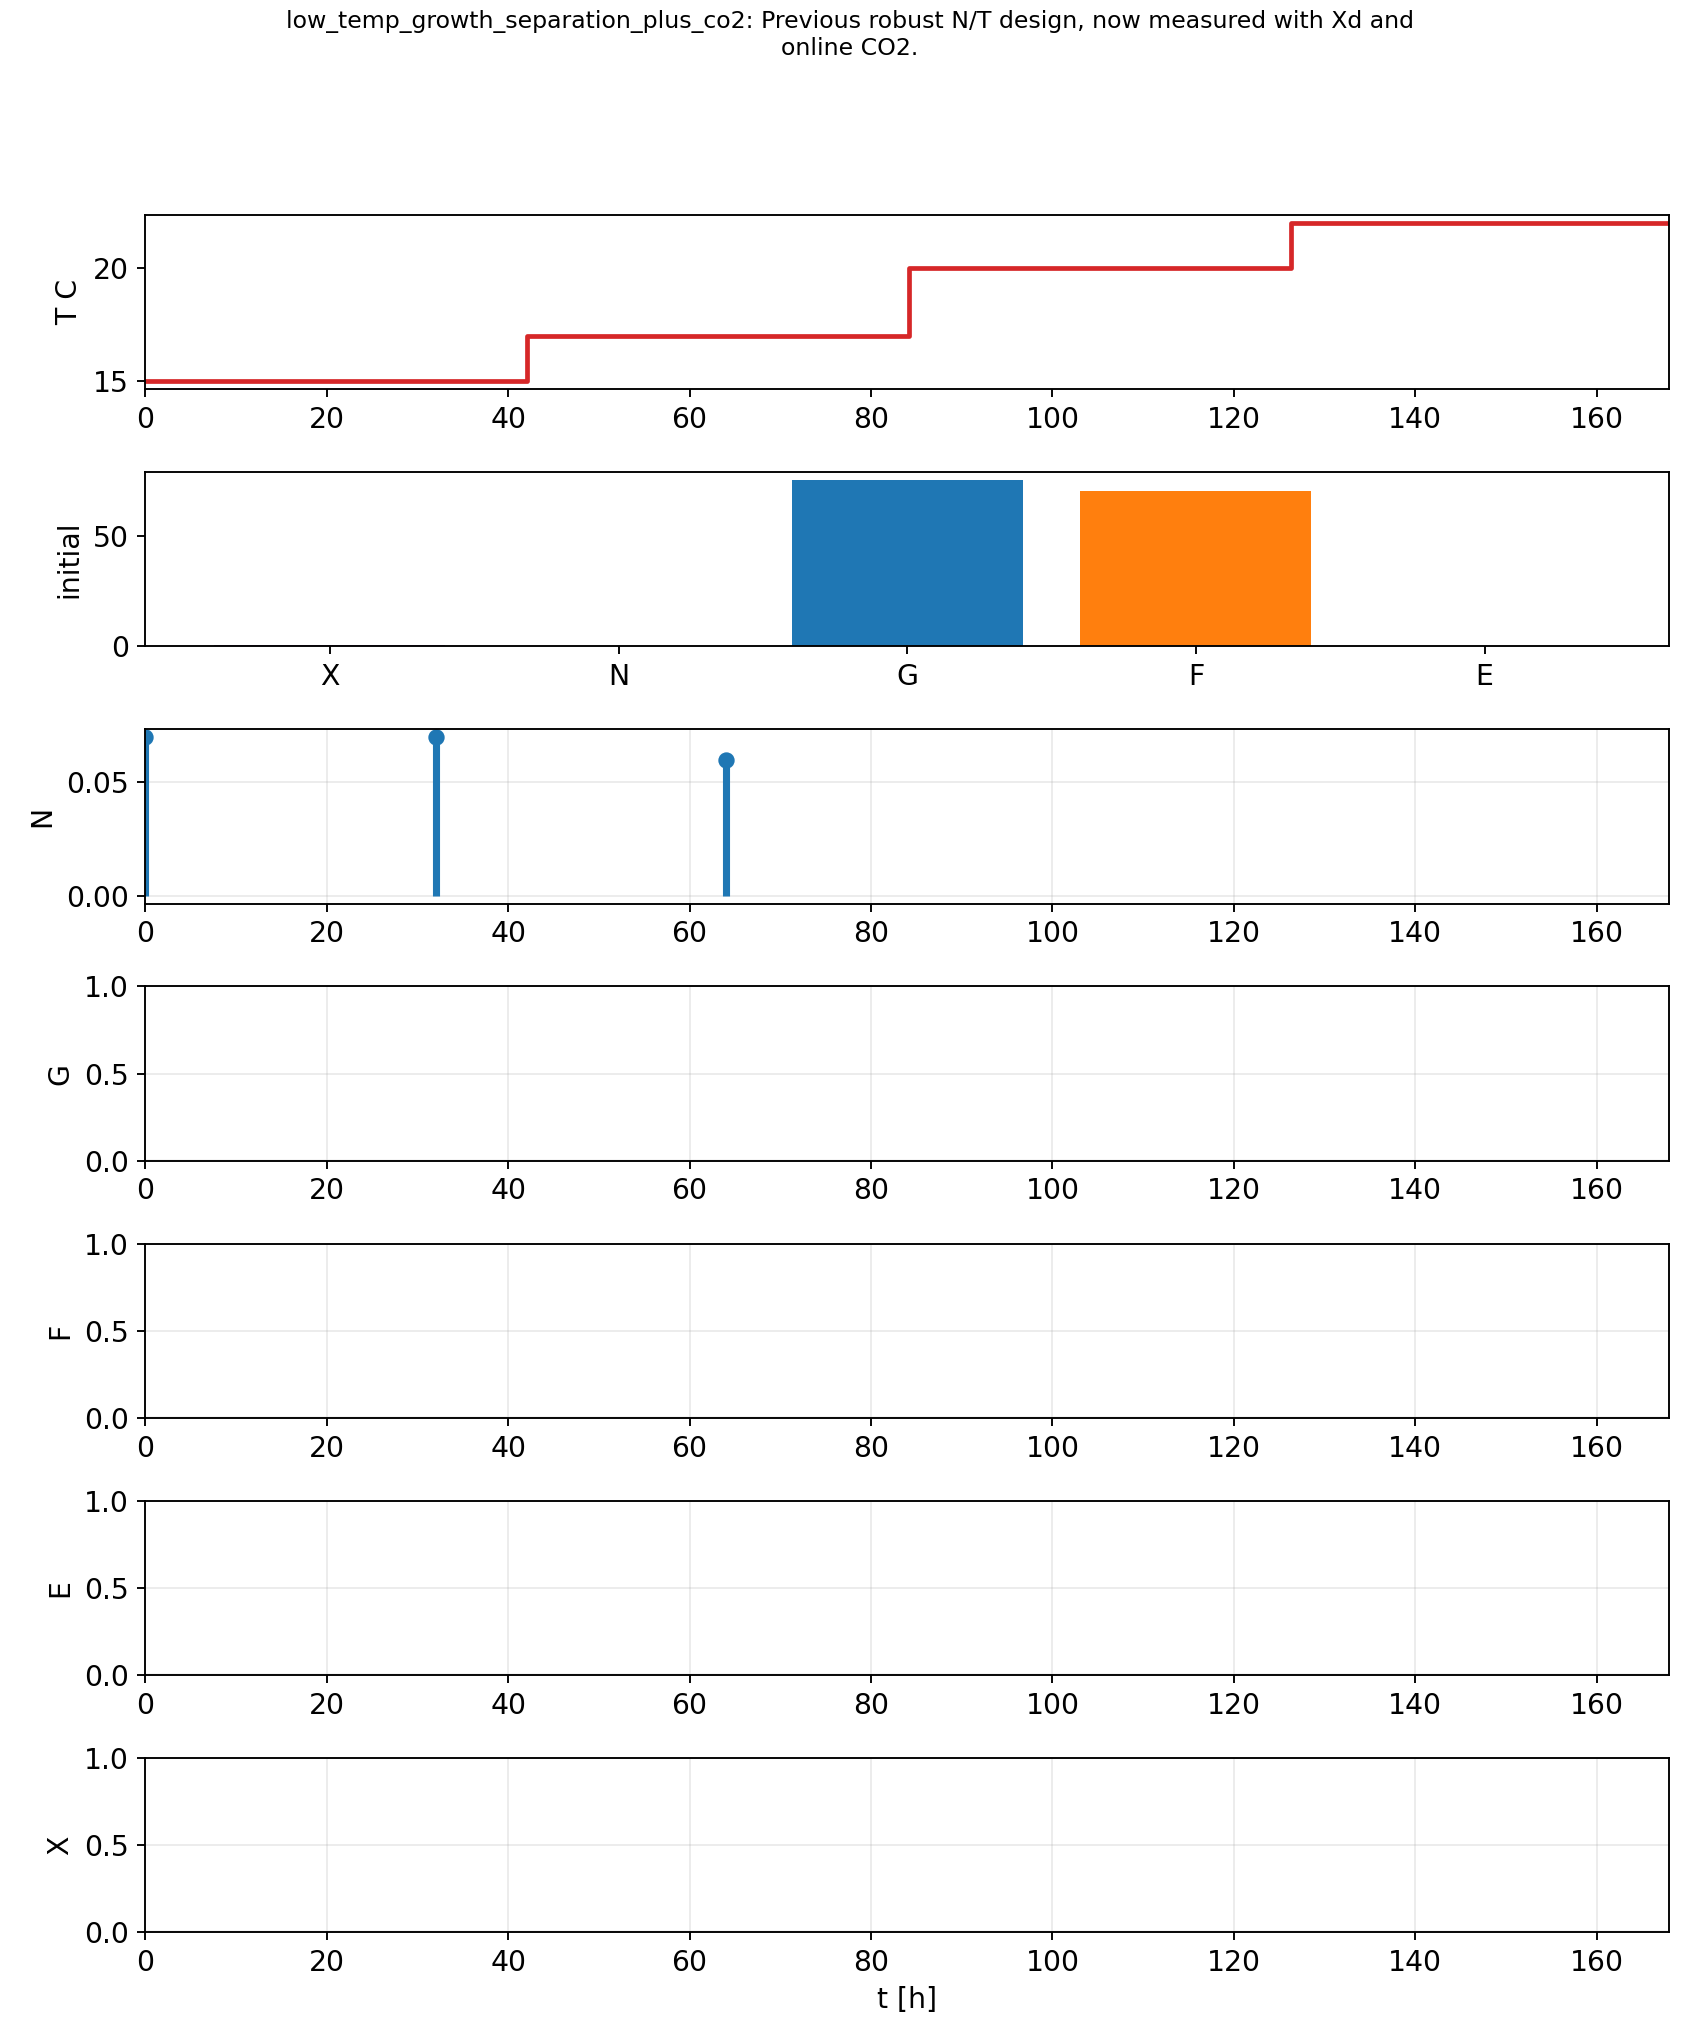

aroma_campaign_inputs_combined_stress_long_horizon.png


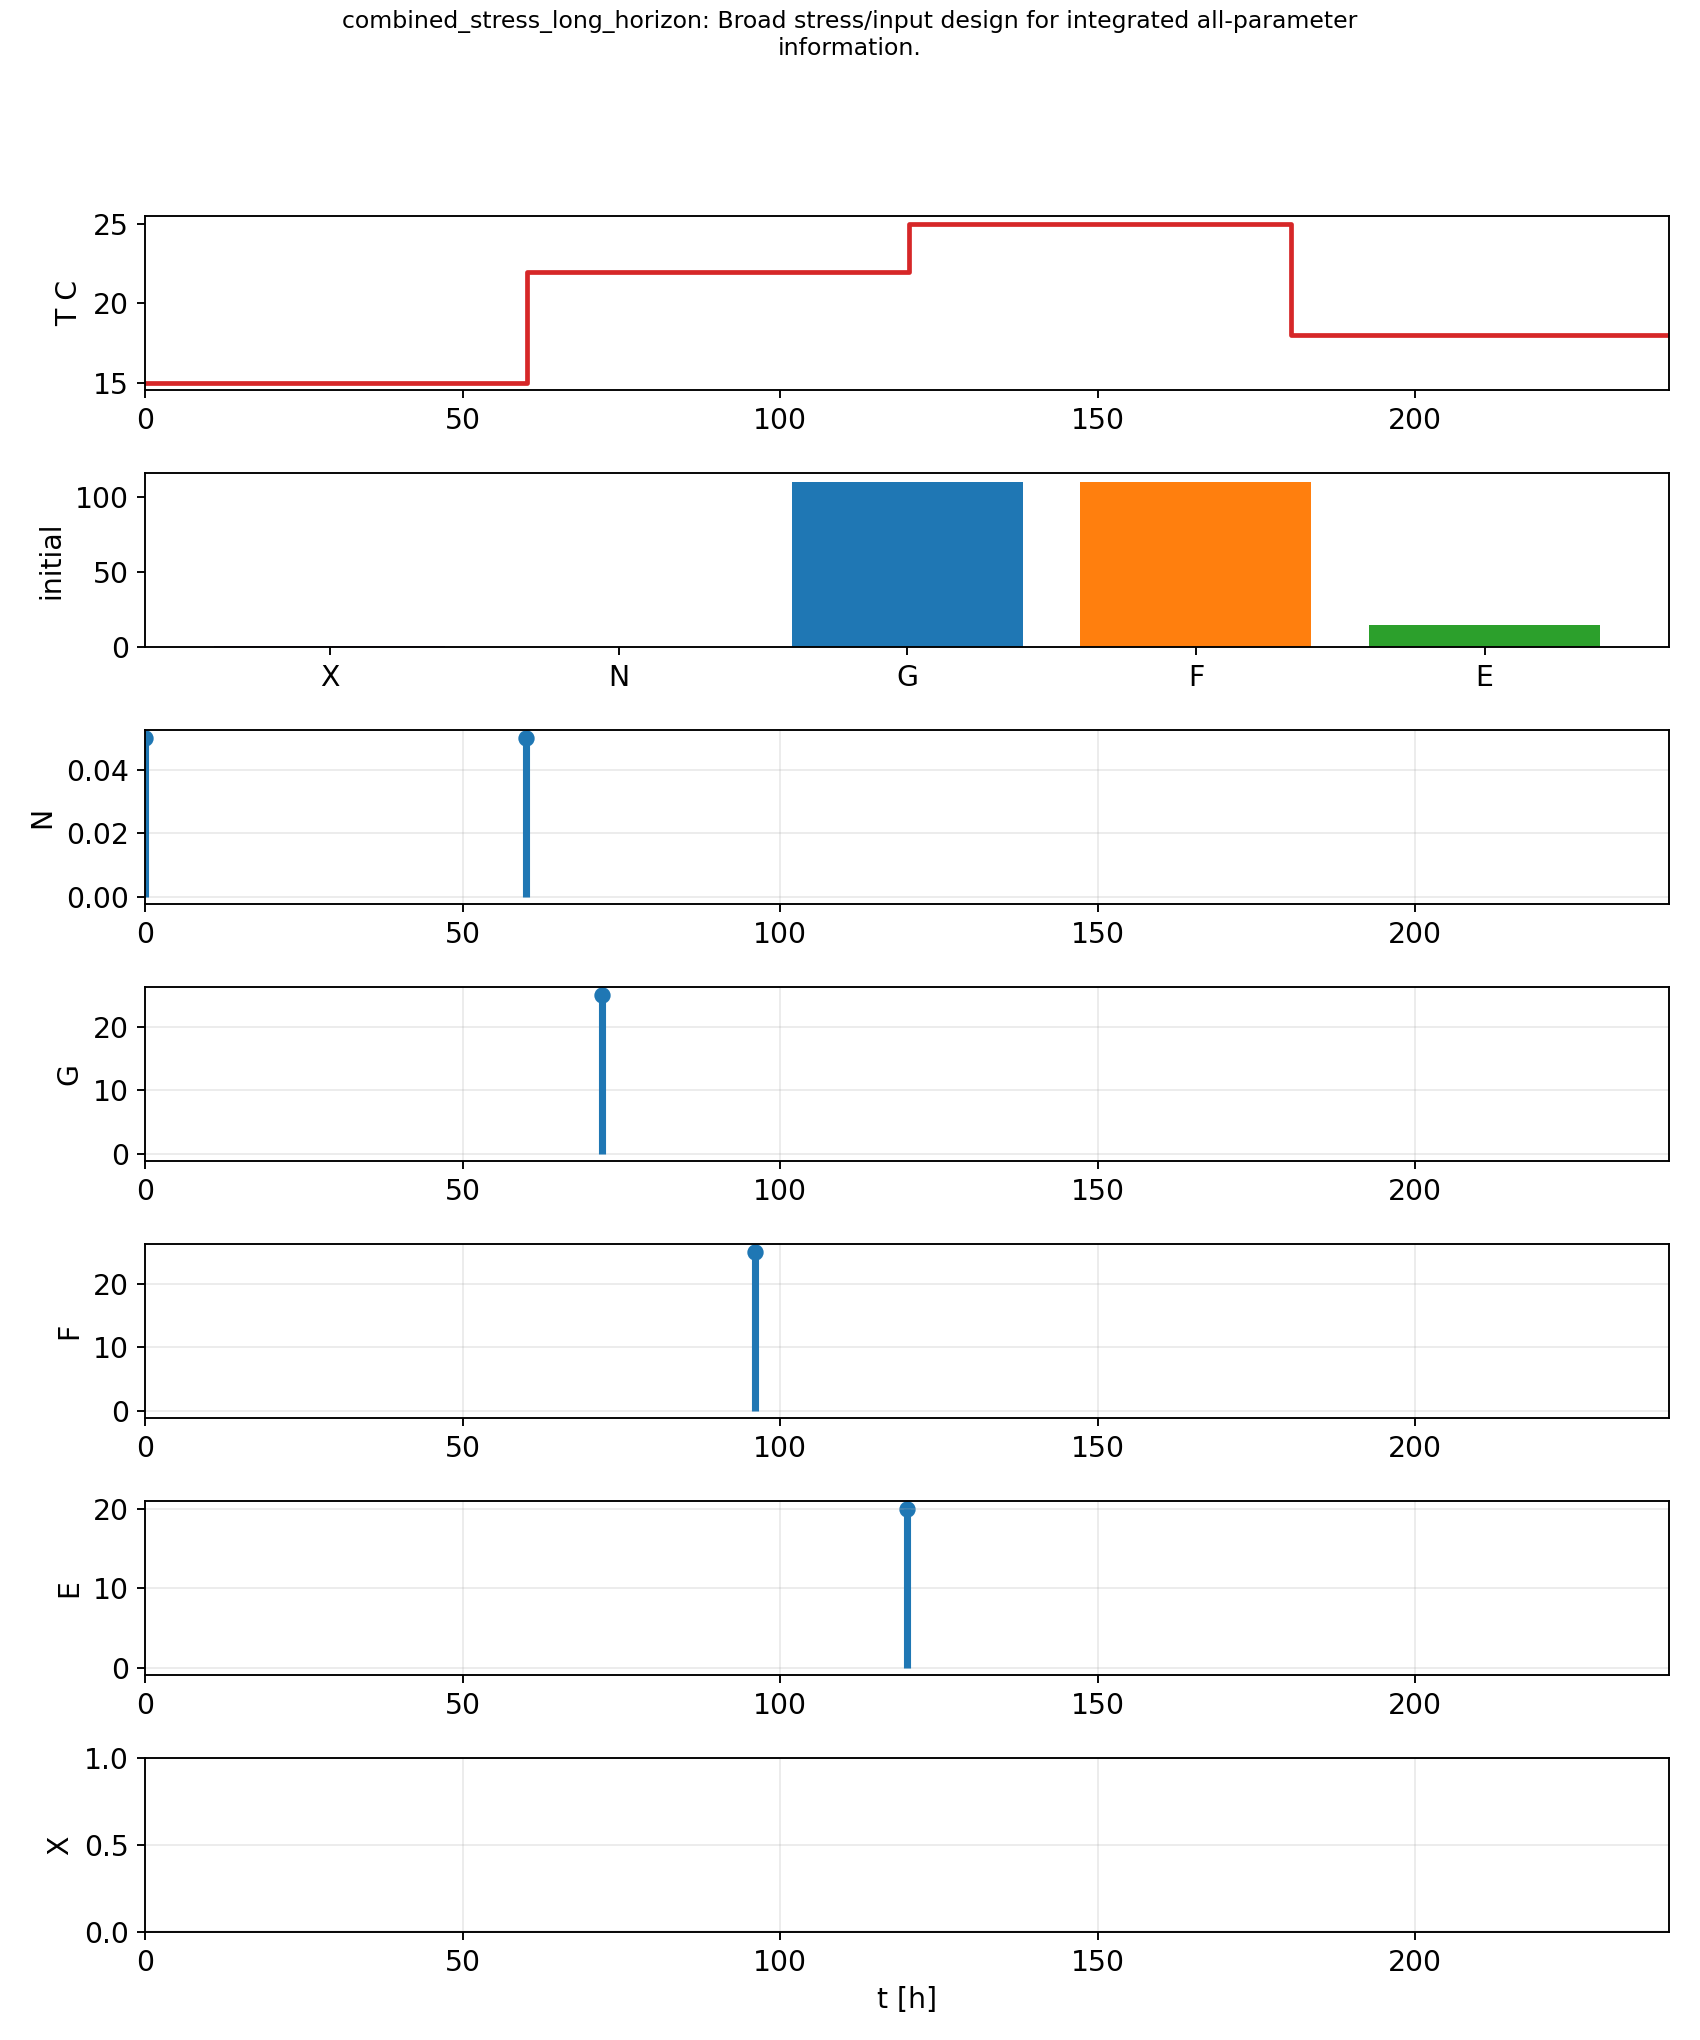

aroma_campaign_inputs_yan_saturation_scan.png


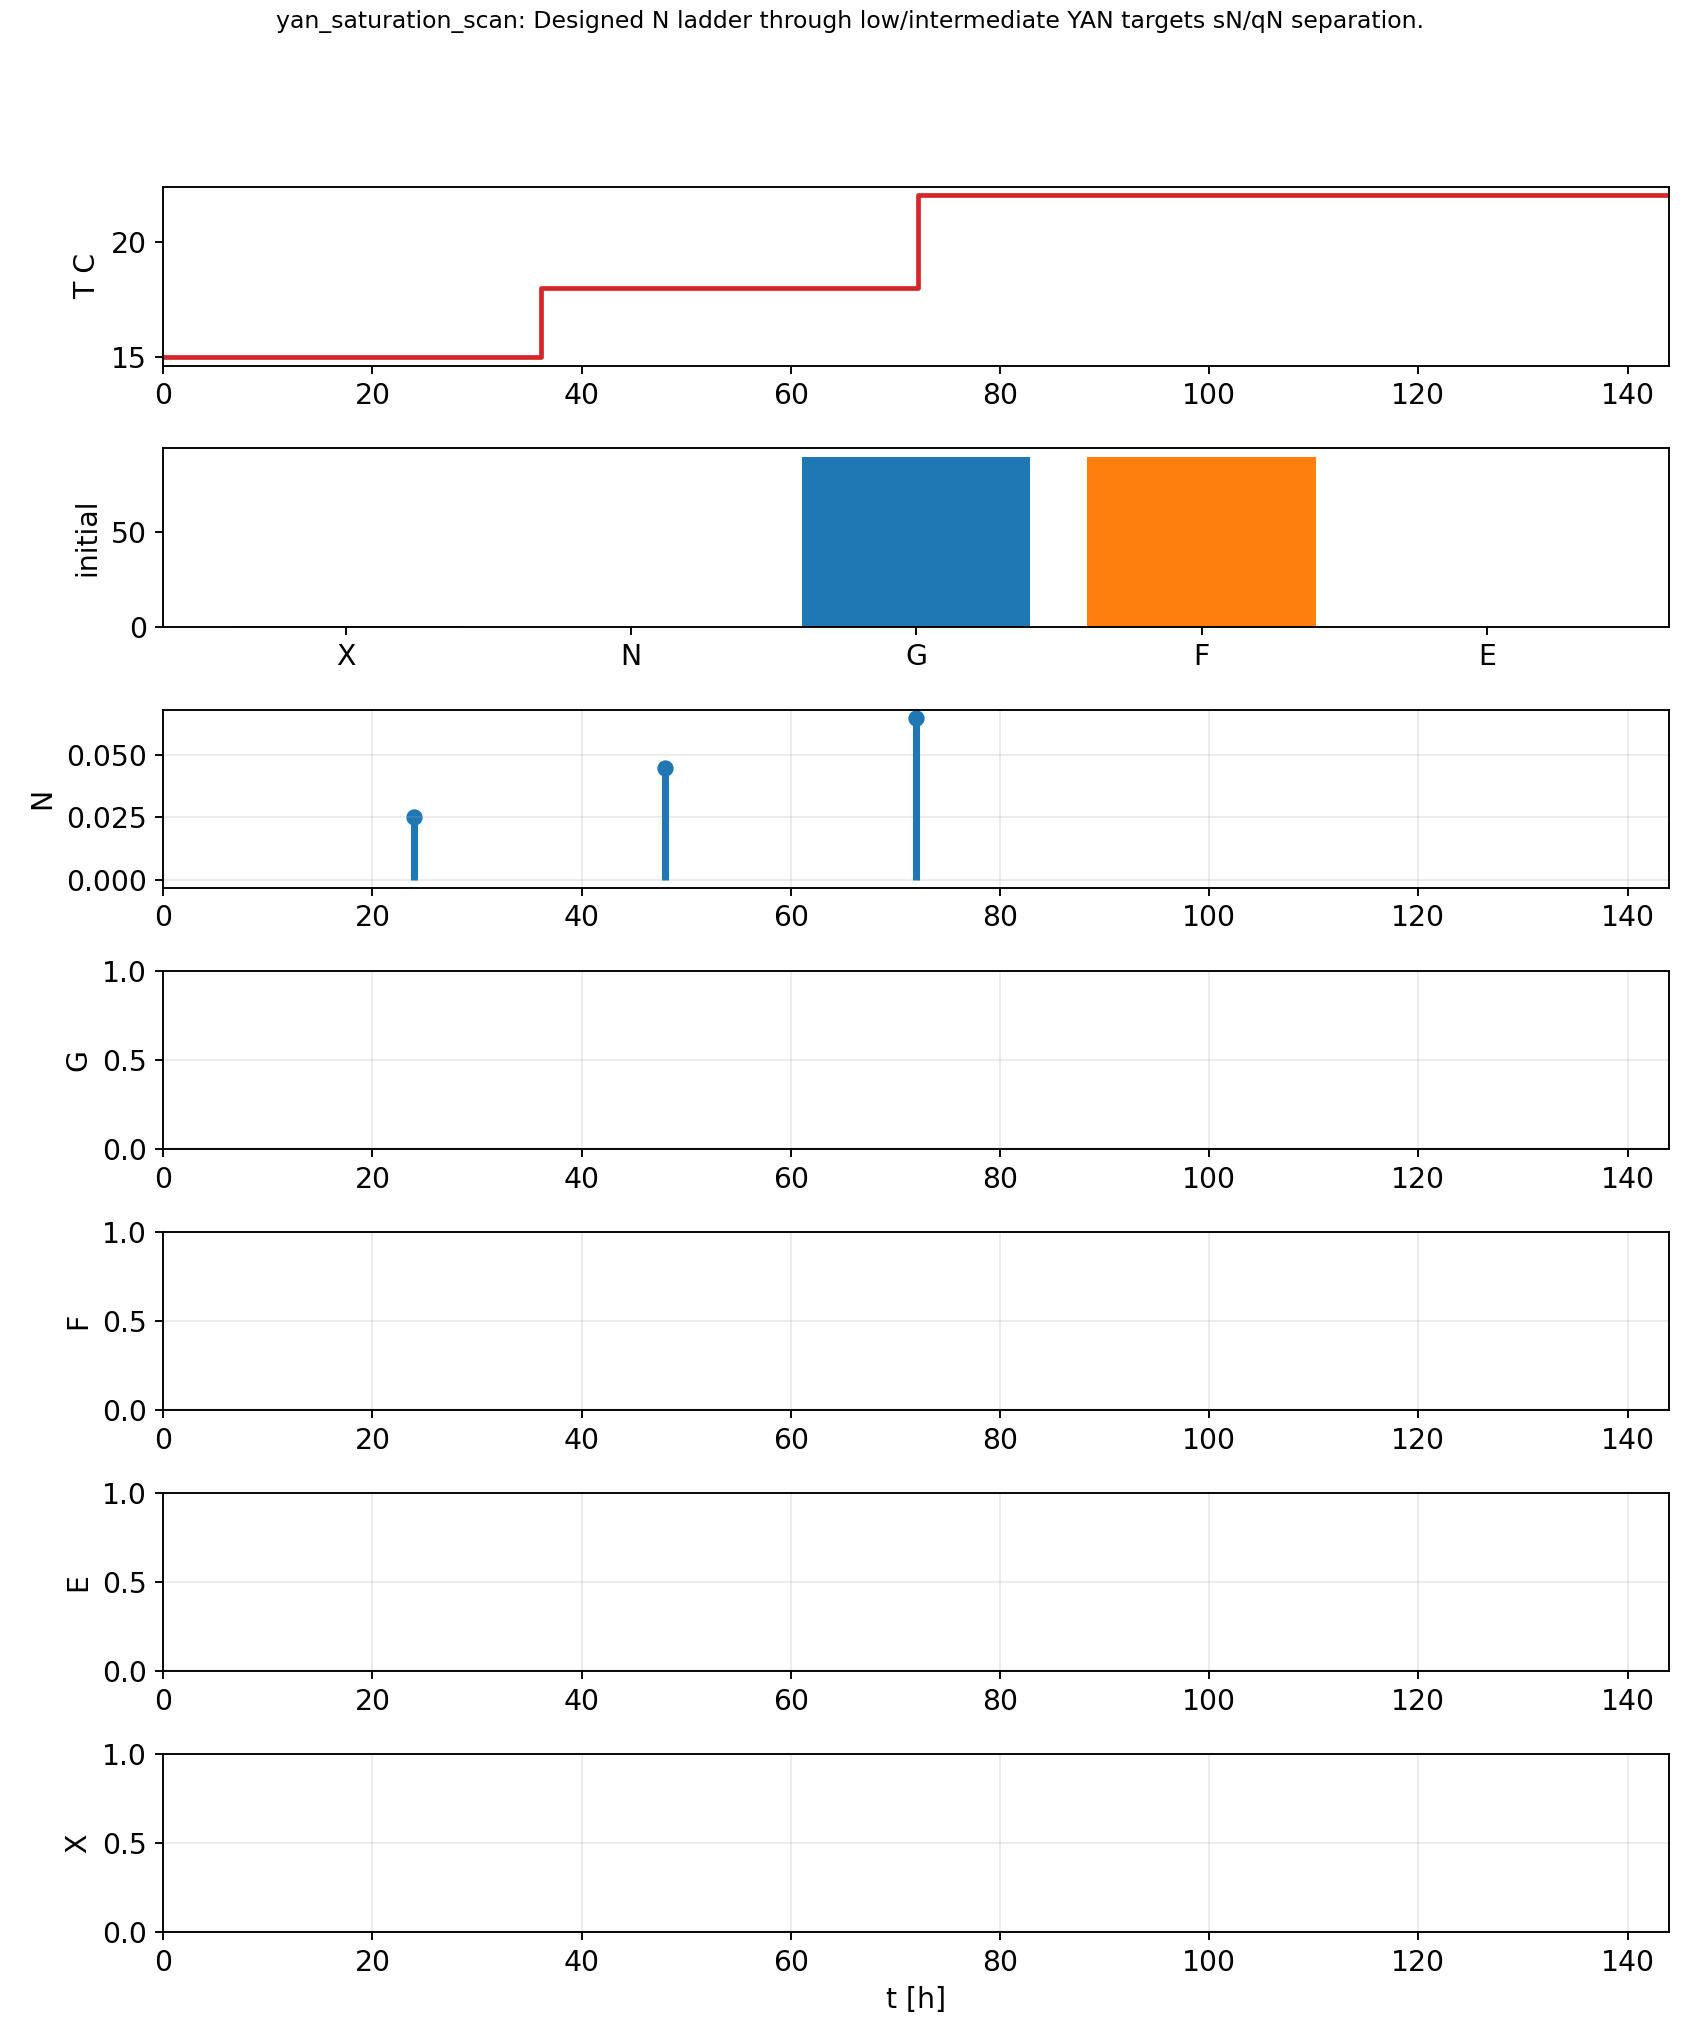

aroma_campaign_inputs_glucose_rich_growth_yield.png


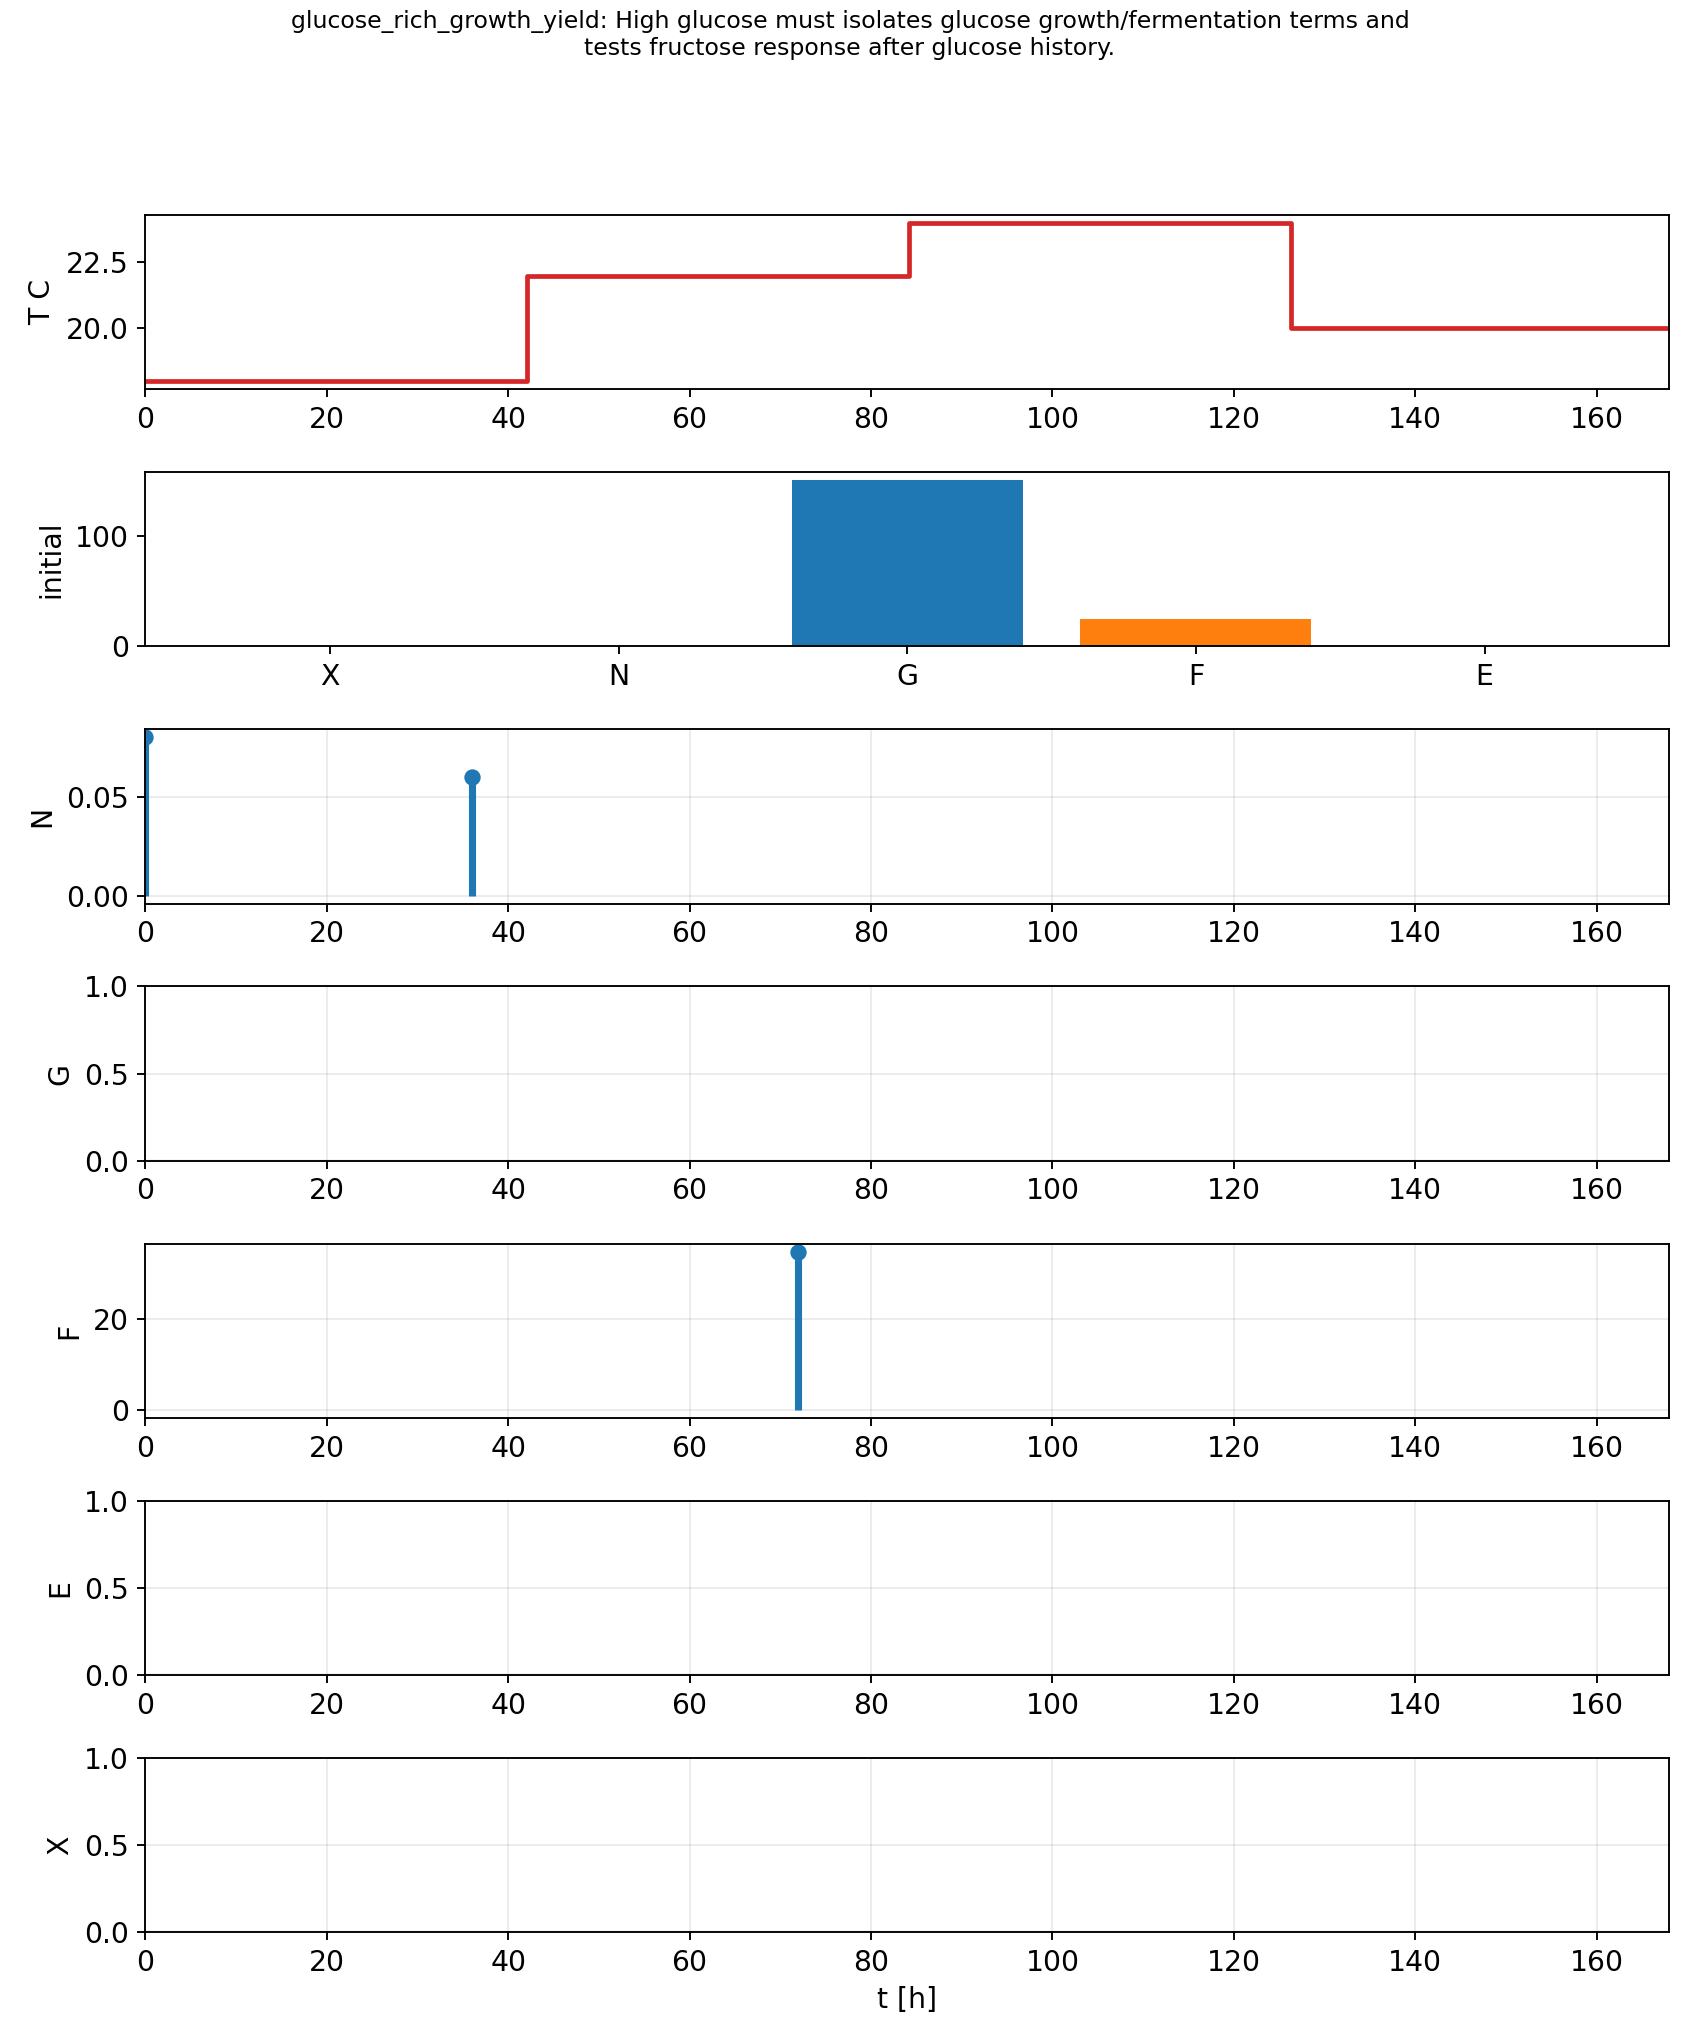

aroma_campaign_inputs_high_biomass_low_N_maintenance.png


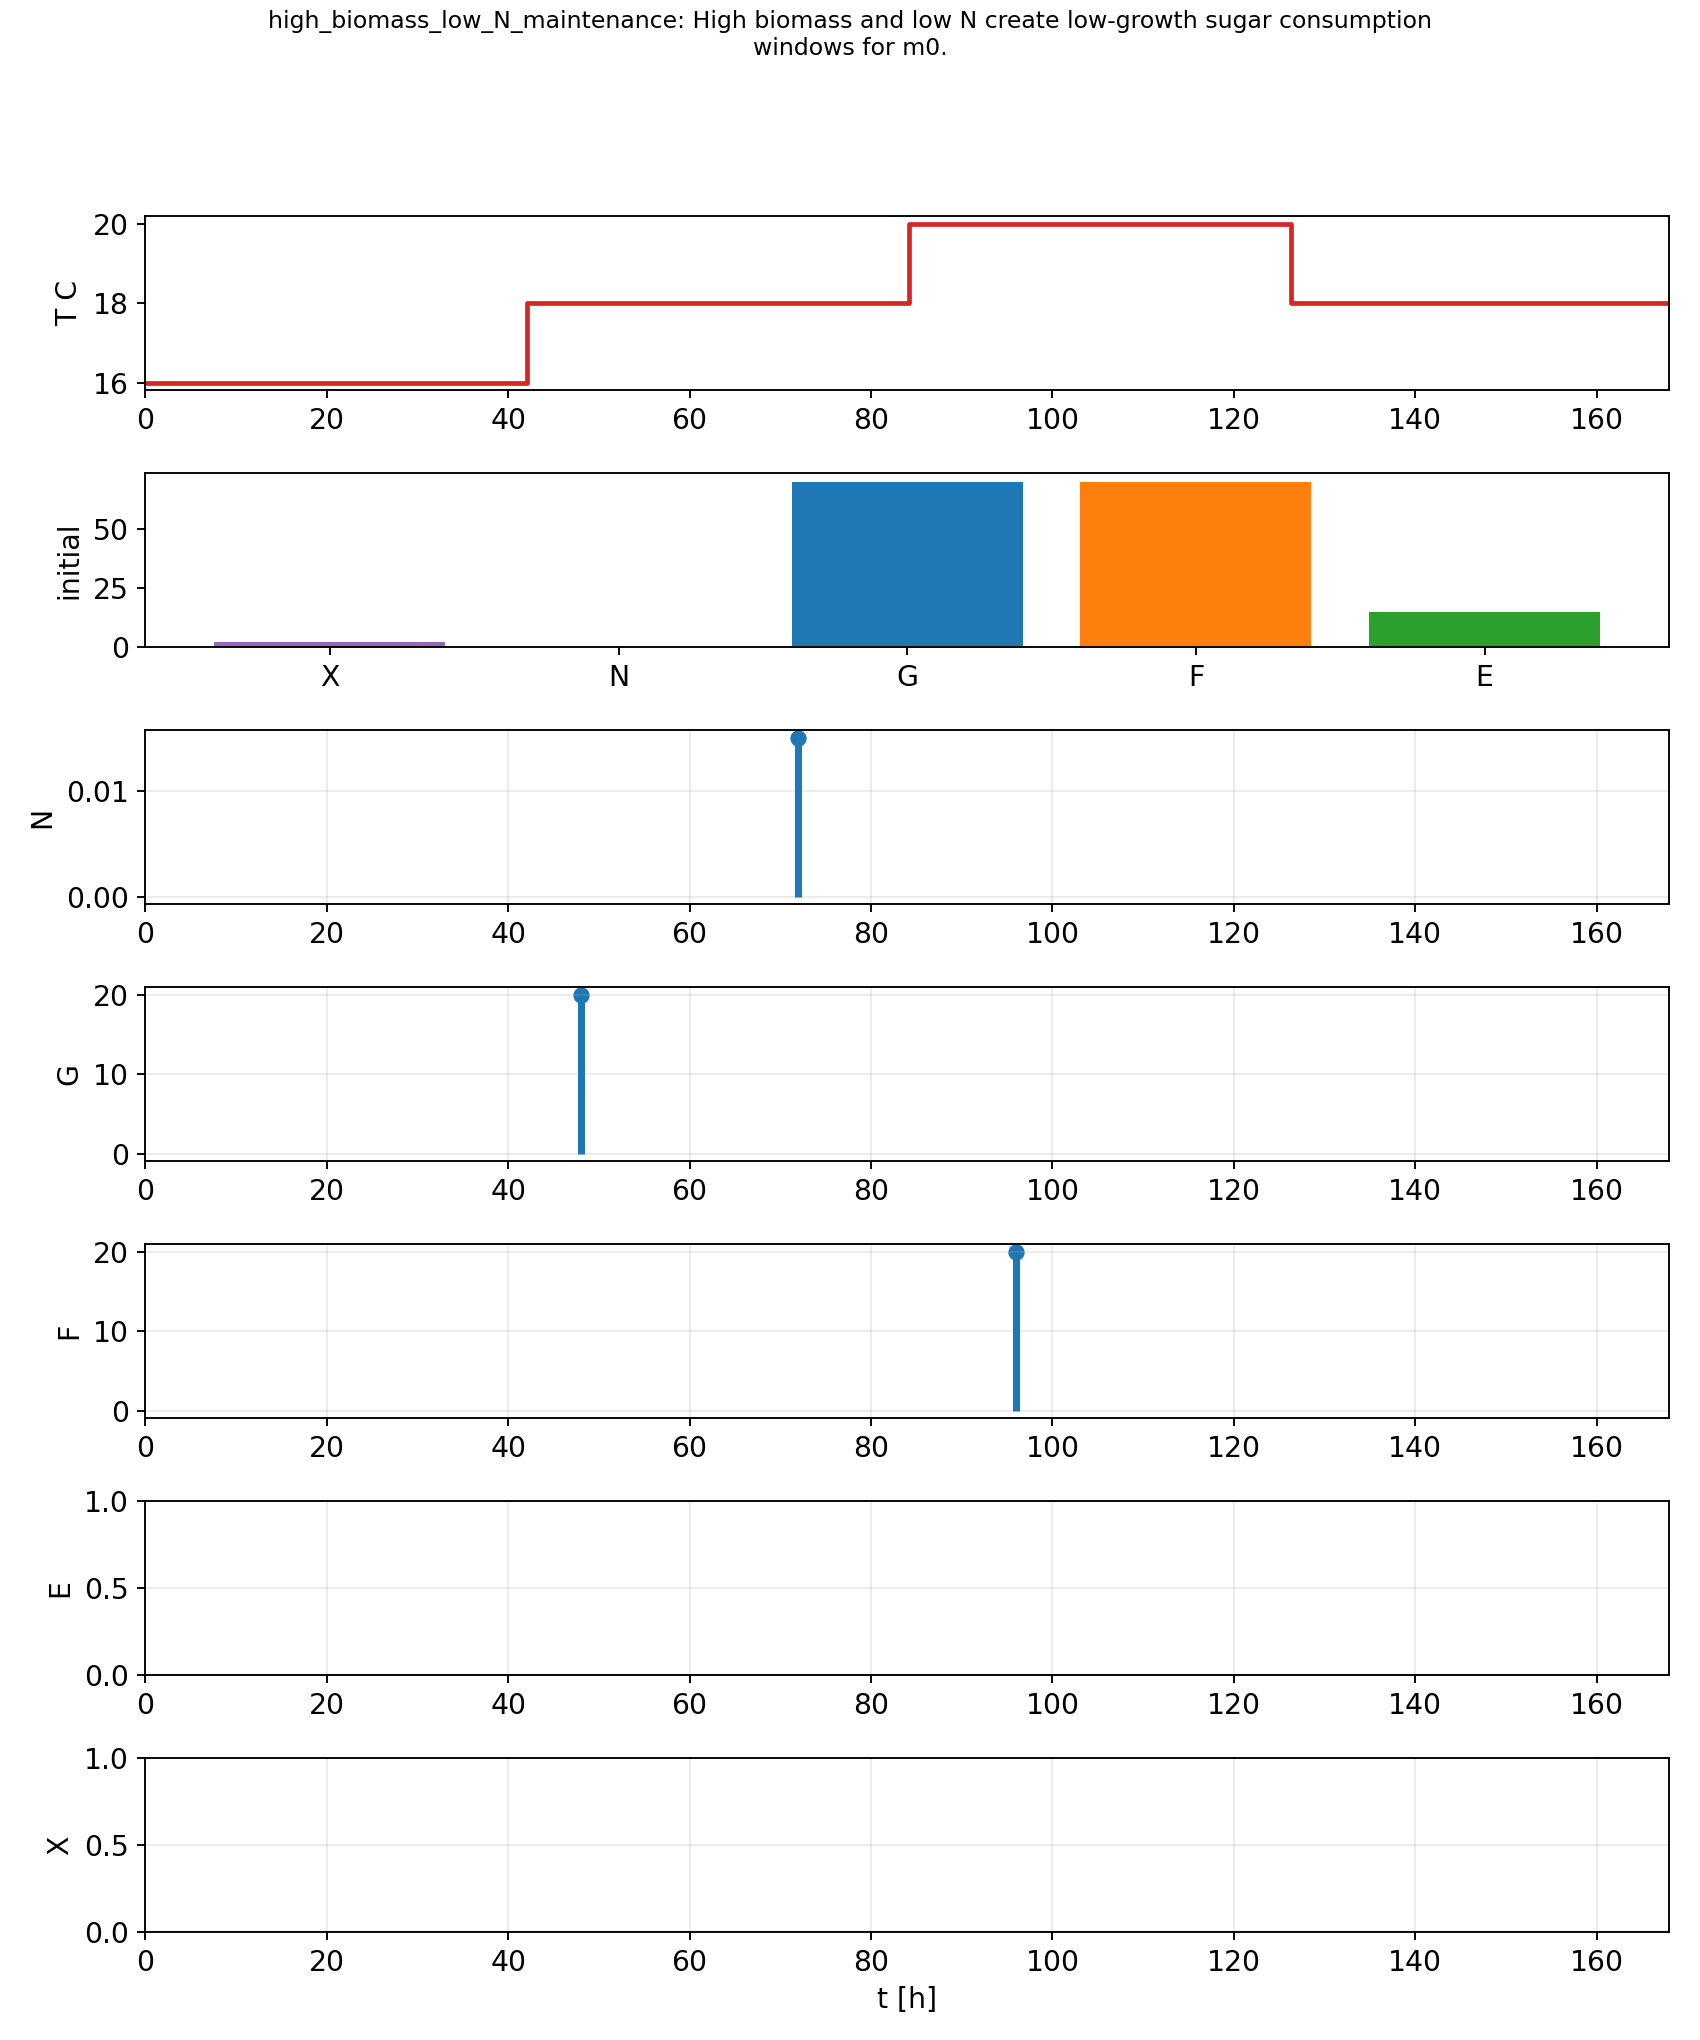

aroma_campaign_inputs_ethanol_initial_challenge.png


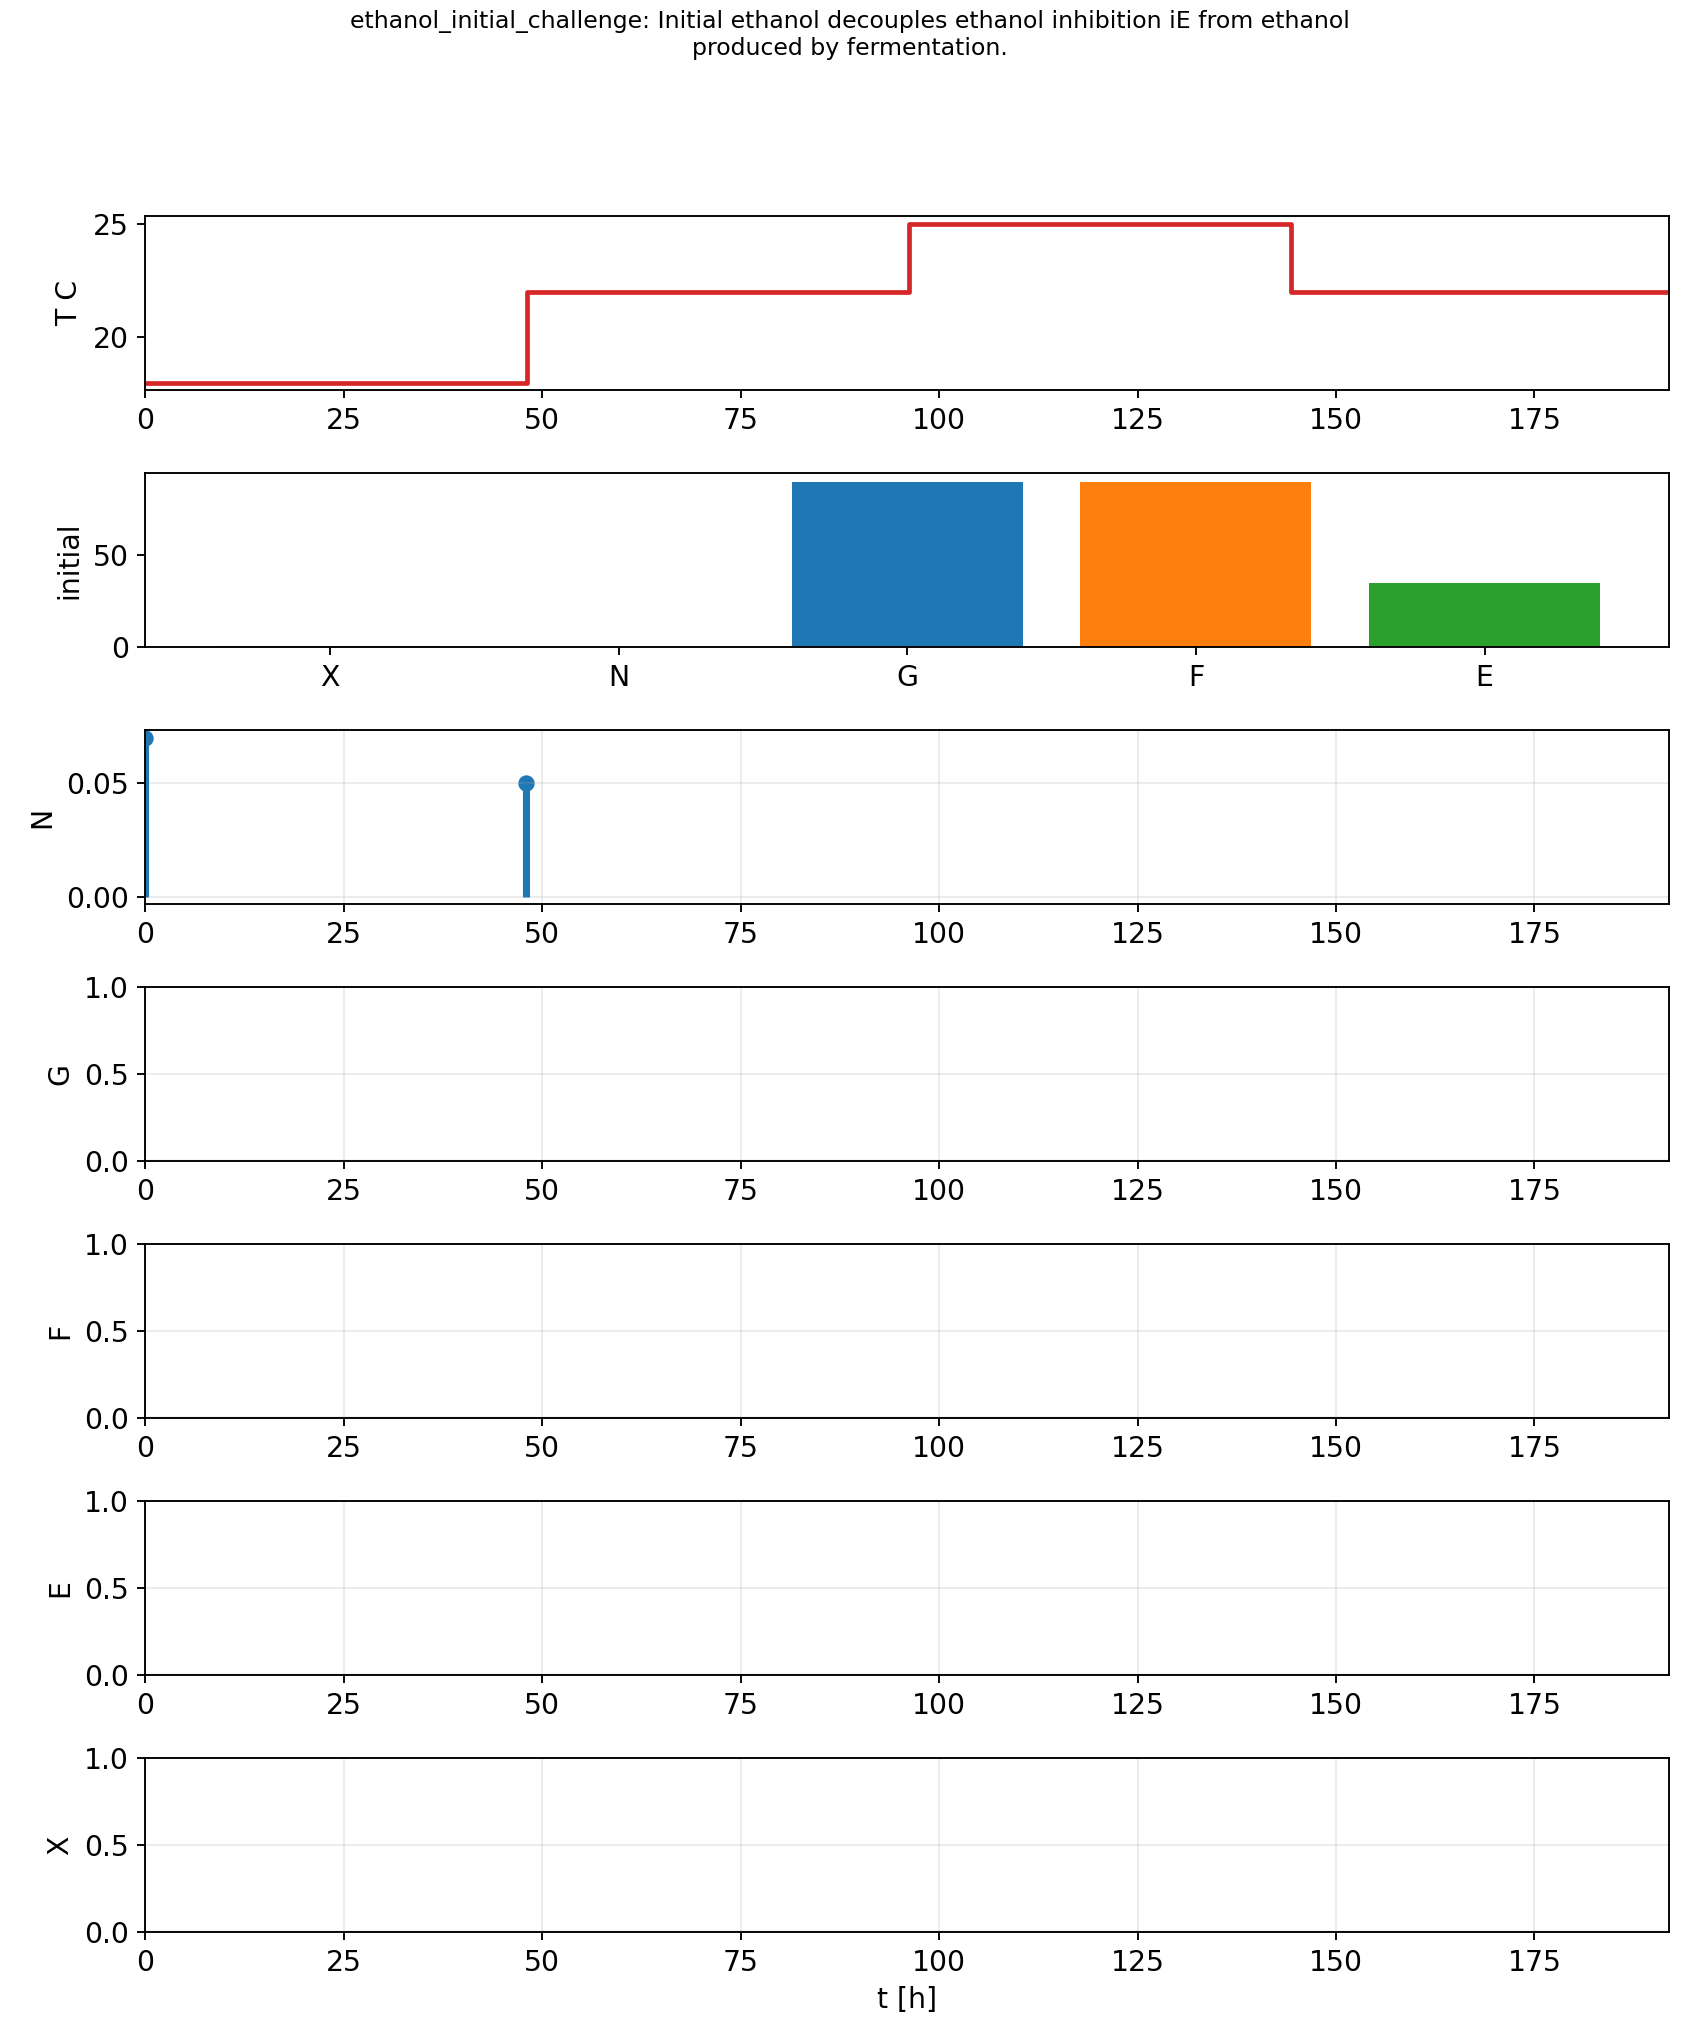

aroma_campaign_inputs_glucose_pulse_after_N_depletion.png


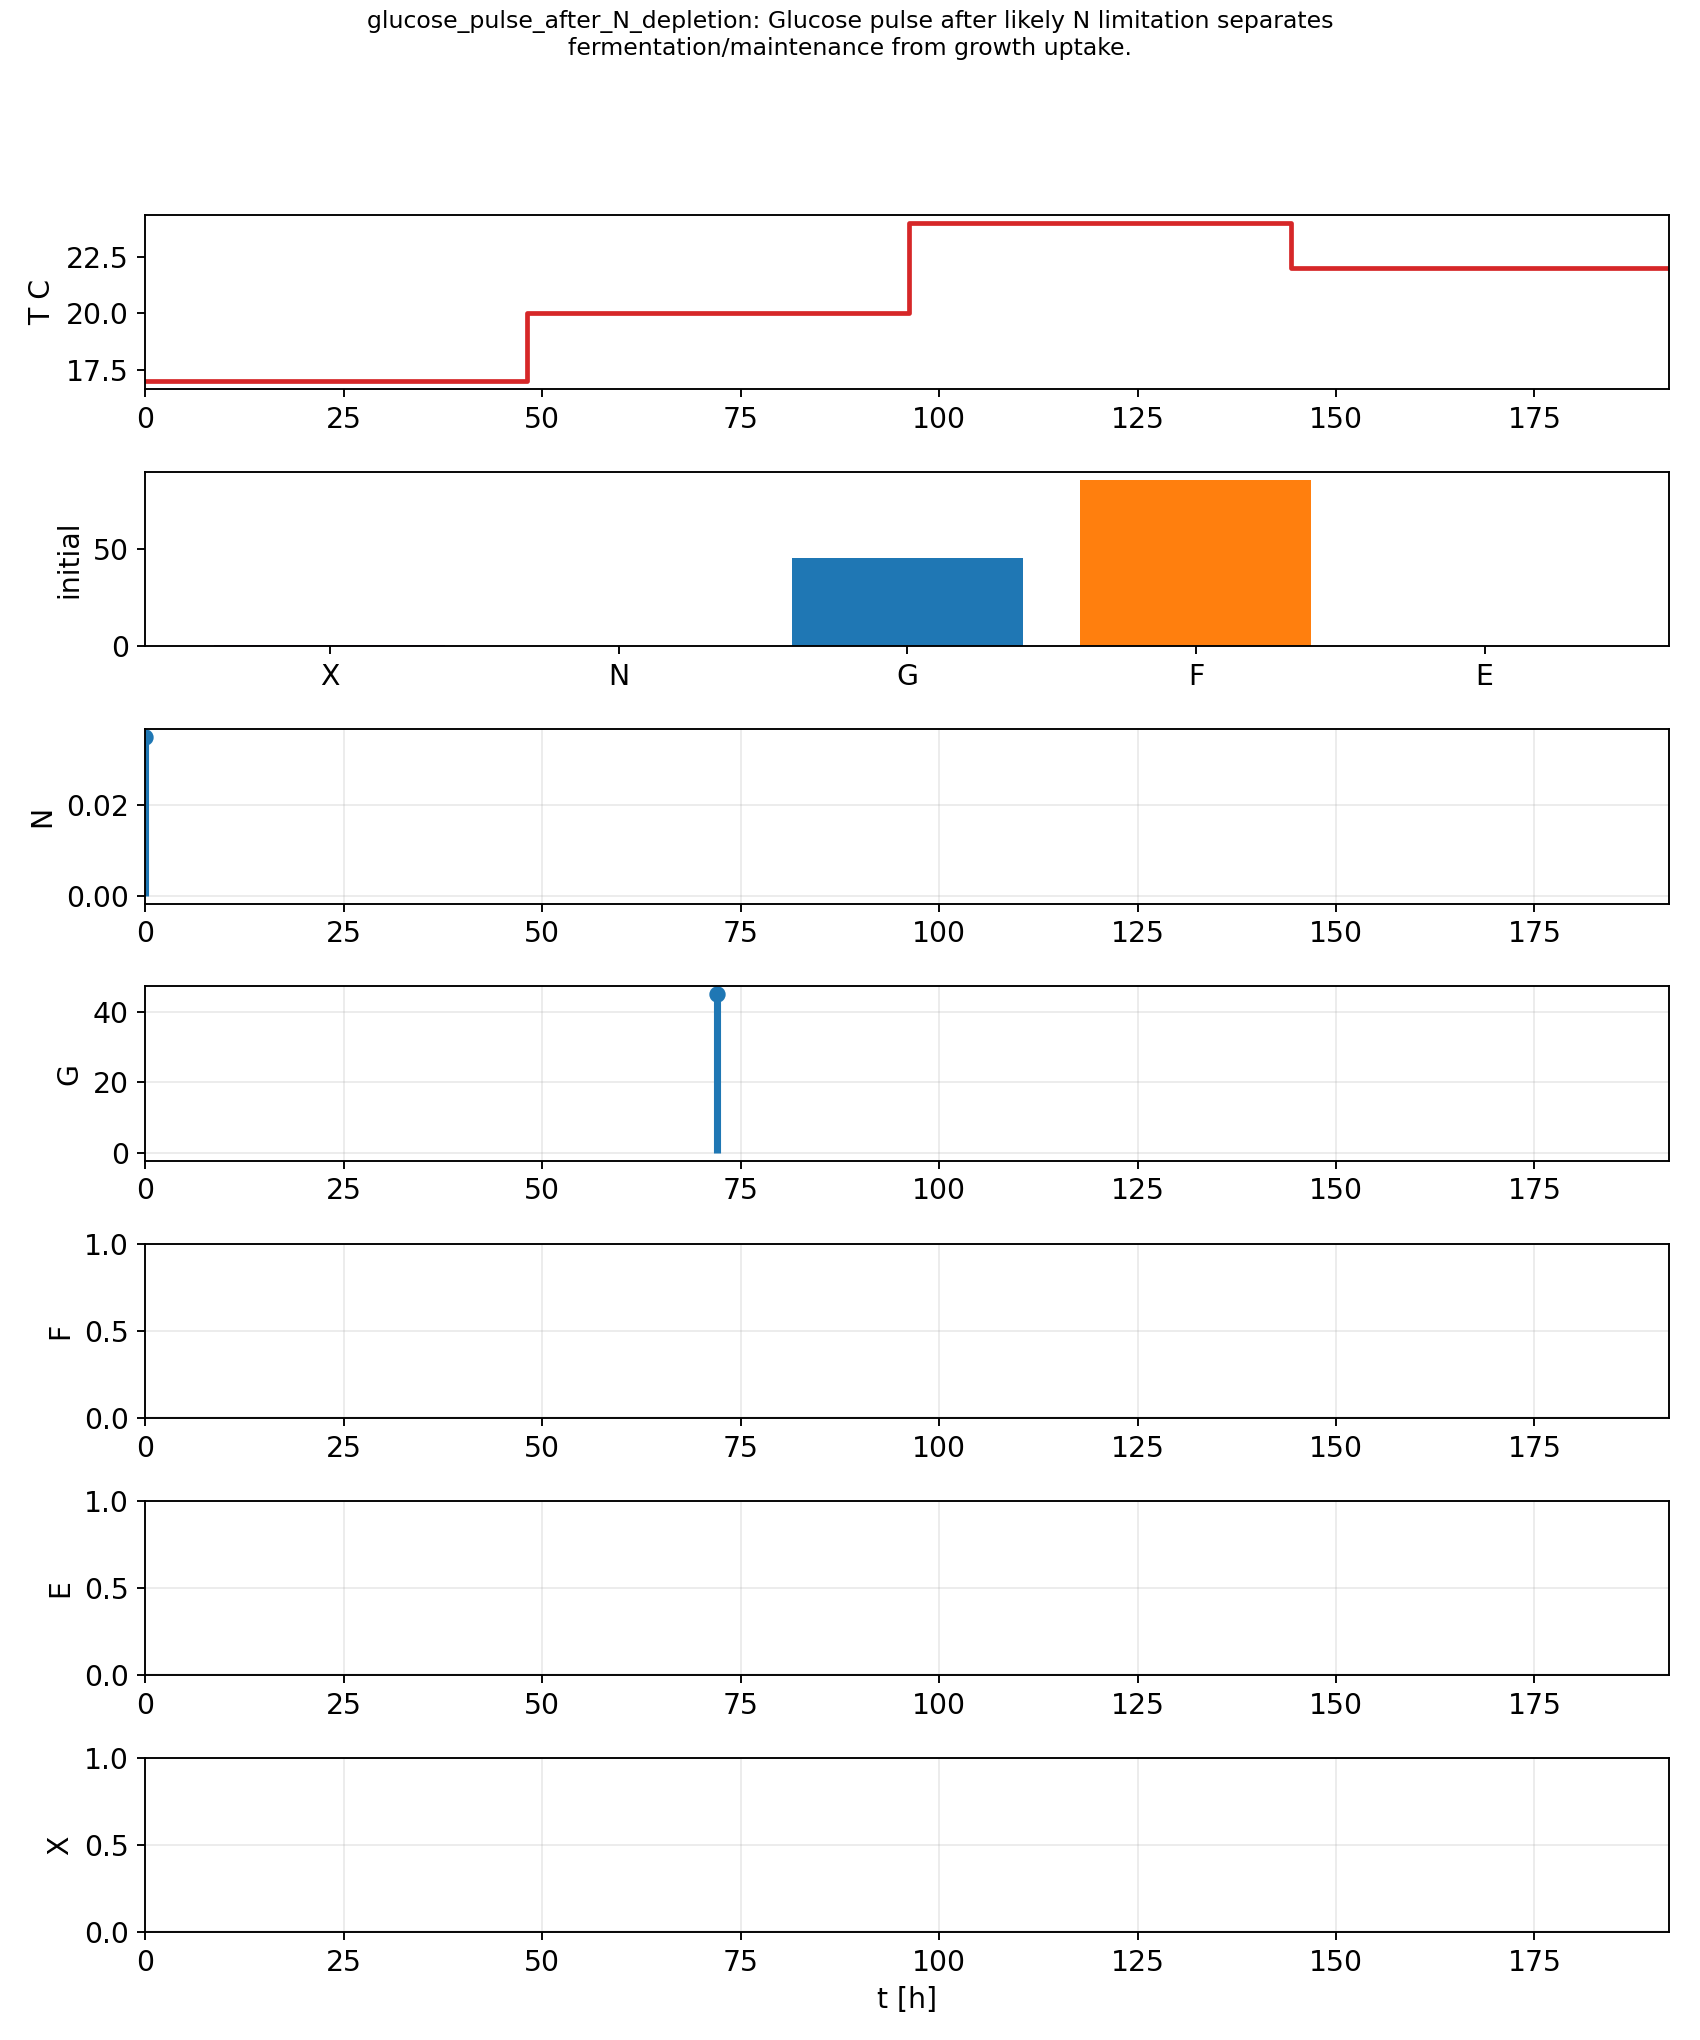

In [24]:
from IPython.display import Image, display

for name in joint_selected["candidate"]:
    path = JOINT_RESULTS / f"aroma_campaign_inputs_{name}.png"
    print(path.name)
    display(Image(filename=str(path)))

### 14.4 Interpretation for the experimental campaign

The recommended basis for the next campaign is the joint design, not the aroma-only design. The joint design estimates aroma synthesis parameters while accounting for uncertainty in the fermentation kinetics that drive growth, nitrogen limitation, sugar uptake, ethanol formation, death, and maintenance.

The selected nine-fermentation campaign is therefore:

1. `fructose_rich_iG_probe`
2. `cold_synthesis_hot_stripping`
3. `low_temp_growth_separation_plus_co2`
4. `combined_stress_long_horizon`
5. `yan_saturation_scan`
6. `glucose_rich_growth_yield`
7. `high_biomass_low_N_maintenance`
8. `ethanol_initial_challenge`
9. `glucose_pulse_after_N_depletion`

The practical interpretation is:

- Use temperature switches to decouple aroma synthesis windows from gas stripping/retention.
- Use sugar composition and sugar pulses to separate glucose and fructose kinetic directions and their downstream aroma effects.
- Use nitrogen ladders to improve \(s_N\), which is still the weakest practical direction after the joint campaign.
- Use ethanol and biomass perturbations to reduce confounding between ethanol inhibition, maintenance, death, and aroma loss/production.
- Keep gas-liquid partition coefficients fixed from UNIFAC/literature unless independent condensate or gas-phase data are added. With only a terminal condensate sample, estimating partition correction factors together with synthesis rates is still strongly confounded.

## 15. Pure D-optimality benchmark

The joint campaign above uses a hybrid score that preserves D-optimality pressure while explicitly protecting weak practical directions. To test whether that choice is too conservative, we benchmark pure D-optimality using the same successful candidate FIMs:

$$
\xi_{D} = \arg\max_{\xi} \log \det \left(F_{\mathrm{prior}} + \sum_{e \in \xi} F_e \right).
$$

Two D-opt checks are performed:

1. `dopt_greedy`: build a nine-experiment campaign from scratch using only \(\log\det(F_{\mathrm{post}})\).
2. `dopt_exchange_from_hybrid`: start from the selected hybrid campaign and accept one-for-one swaps only if they increase pure D-optimality.

This benchmark does not re-run Ipopt. It reuses the already computed candidate FIMs, so the comparison isolates the optimality criterion.

In [25]:
RUN_DOPT_BENCHMARK = False
DOPT_SCRIPT = FERM / "run_aroma_dopt_benchmark.py"

if RUN_DOPT_BENCHMARK:
    subprocess.run([sys.executable, str(DOPT_SCRIPT)], cwd=str(ROOT), check=True)

dopt_summary = pd.read_csv(JOINT_RESULTS / "aroma_dopt_benchmark_summary.csv")
dopt_selected = pd.read_csv(JOINT_RESULTS / "aroma_dopt_benchmark_selected.csv")
dopt_reduction = pd.read_csv(JOINT_RESULTS / "aroma_dopt_benchmark_parameter_reduction.csv")
dopt_exchange = pd.read_csv(JOINT_RESULTS / "aroma_dopt_benchmark_exchange_log.csv")

dopt_summary

,design,n_experiments,logdet,min_relative_eigenvalue,condition_number,trace_inv,mean_var_reduction,worst_var_reduction,worst_parameter,sN_var_reduction,qN_var_reduction,mu0_var_reduction,k_EA_growth_var_reduction,k_IAA_growth_var_reduction,k_EO_growth_var_reduction
0,hybrid_current,9,155.980425,0.000013,77161.985209,0.281606,0.973679,0.768944,sN,0.768944,0.931409,0.953276,0.990361,0.992743,0.984554
1,dopt_greedy,9,156.479511,0.000012,85169.457025,0.292098,0.966586,0.655153,sN,0.655153,0.907198,0.935281,0.990861,0.993047,0.985345
2,dopt_exchange_from_hybrid,9,156.479511,0.000012,85169.457025,0.292098,0.966586,0.655153,sN,0.655153,0.907198,0.935281,0.990861,0.993047,0.985345


In [26]:
dopt_exchange

,iteration,swap_out,swap_in,previous_logdet,new_logdet,gain_logdet,out_index
0,1,yan_saturation_scan,viable_biomass_step,155.980425,156.479511,0.499085,4


In [27]:
dopt_selected.sort_values(["design", "campaign_order"])

,design,campaign_order,candidate,family,horizon_h,temperature_c
18,dopt_exchange_from_hybrid,1,fructose_rich_iG_probe,sugar_initial,192.0,"18, 20, 24, 22"
19,dopt_exchange_from_hybrid,2,cold_synthesis_hot_stripping,aroma_partition,192.0,"15, 16, 24, 25"
20,dopt_exchange_from_hybrid,3,low_temp_growth_separation_plus_co2,legacy_plus,168.0,"15, 17, 20, 22"
21,dopt_exchange_from_hybrid,4,combined_stress_long_horizon,integrated,240.0,"15, 22, 25, 18"
22,dopt_exchange_from_hybrid,5,viable_biomass_step,biomass_input,168.0,"18, 22, 22, 18"
23,dopt_exchange_from_hybrid,6,glucose_rich_growth_yield,sugar_initial,168.0,"18, 22, 24, 20"
24,dopt_exchange_from_hybrid,7,high_biomass_low_N_maintenance,maintenance,168.0,"16, 18, 20, 18"
25,dopt_exchange_from_hybrid,8,ethanol_initial_challenge,ethanol,192.0,"18, 22, 25, 22"
26,dopt_exchange_from_hybrid,9,glucose_pulse_after_N_depletion,pulse_separation,192.0,"17, 20, 24, 22"
9,dopt_greedy,1,fructose_rich_iG_probe,sugar_initial,192.0,"18, 20, 24, 22"


In [28]:
key_parameters = ["sN", "qN", "mu0", "sF", "sG", "k_EA_growth", "k_IAA_growth", "k_EO_growth"]
(
    dopt_reduction[dopt_reduction["parameter"].isin(key_parameters)]
    .pivot(index="parameter", columns="design", values="var_reduction")
    .loc[key_parameters]
)

design,dopt_exchange_from_hybrid,dopt_greedy,hybrid_current
parameter,,,
sN,0.655153,0.655153,0.768944
qN,0.907198,0.907198,0.931409
mu0,0.935281,0.935281,0.953276
sF,0.959146,0.959146,0.955761
sG,0.979609,0.979609,0.977299
k_EA_growth,0.990861,0.990861,0.990361
k_IAA_growth,0.993047,0.993047,0.992743
k_EO_growth,0.985345,0.985345,0.984554


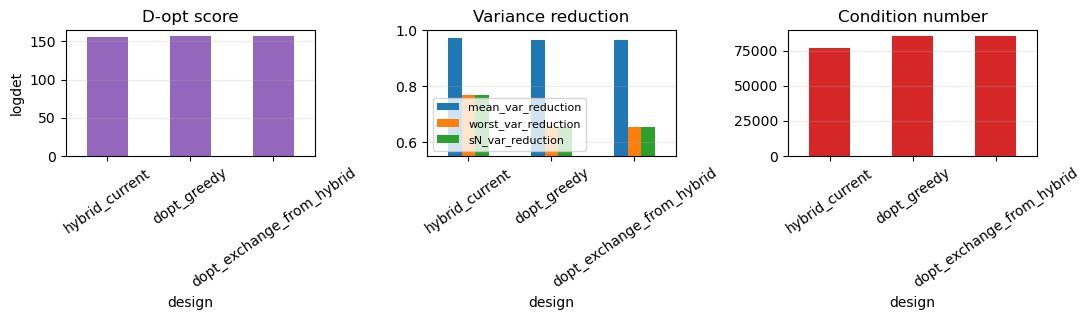

In [29]:
plot_metrics = dopt_summary.set_index("design")[[
    "logdet", "mean_var_reduction", "worst_var_reduction", "sN_var_reduction", "condition_number"
]]
fig, axes = plt.subplots(1, 3, figsize=(11, 3.3))
plot_metrics["logdet"].plot(kind="bar", ax=axes[0], color="tab:purple")
axes[0].set_title("D-opt score")
axes[0].set_ylabel("logdet")
plot_metrics[["mean_var_reduction", "worst_var_reduction", "sN_var_reduction"]].plot(kind="bar", ax=axes[1])
axes[1].set_ylim(0.55, 1.0)
axes[1].set_title("Variance reduction")
axes[1].legend(loc="lower left", fontsize=8)
plot_metrics["condition_number"].plot(kind="bar", ax=axes[2], color="tab:red")
axes[2].set_title("Condition number")
for ax in axes:
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=35)
fig.tight_layout()
plt.show()

### 15.1 D-opt benchmark interpretation

Pure D-optimality finds a local improvement in \(\log\det(F)\): replacing `yan_saturation_scan` with `viable_biomass_step` increases the final logdet from approximately `155.98` to `156.48`. The same final set is reached by greedy D-opt from scratch and by one-swap exchange from the hybrid seed.

However, this D-opt improvement sacrifices the weakest practical direction:

- \(s_N\) variance reduction drops from about `0.769` to `0.655`.
- \(q_N\) drops from about `0.931` to `0.907`.
- \(\mu_0\) drops from about `0.953` to `0.935`.
- The condition number worsens from about `77,162` to `85,169`.

Aroma synthesis parameters improve slightly under D-opt, but they were already strongly estimable. Therefore, pure D-optimality mainly buys a small global information gain by spending less design effort on the nitrogen saturation direction. Because \(s_N\) is the known practical bottleneck, the hybrid design remains the better default campaign unless the objective is strictly maximum determinant regardless of weak-parameter protection.

## 16. Symbolic UNIFAC trial

A full symbolic original-UNIFAC implementation was added as an experimental option. In this mode fructose is treated as glucose-equivalent, and \(K_{lg}\) is computed from the UNIFAC activity coefficient and literature vapor-pressure correlations directly inside Pyomo:

$$
K_i(T,x) = \frac{\gamma_i^\infty(T,x) P_i^{sat}(T)}{R T C_L}.
$$

This is physically more explicit than the fitted log-linear surrogate, but it makes every dynamic model solve much more nonlinear. The trial result was: model construction and expression evaluation work, but nominal simulation and sequential-FIM evaluation were too slow for the current DOE workflow. Therefore the surrogate remains the recommended operational mode for campaign design, while `symbolic_unifac` is retained for offline checks.

In [30]:
SYMBOLIC_UNIFAC_REPORT = FERM / "results" / "aroma_symbolic_unifac_trial_report.md"
print(SYMBOLIC_UNIFAC_REPORT.read_text(encoding="utf-8"))

# Symbolic UNIFAC trial

This trial tested replacing the fitted log-linear partition surrogate with the full original-UNIFAC activity-coefficient equations embedded symbolically in Pyomo.

## Implemented option

- Fructose is treated as glucose-equivalent for the liquid composition.
- Liquid components are water, ethanol, glucose-equivalent sugar, and a trace aroma species.
- The activity coefficient is computed with original UNIFAC group contributions:
  - ethyl acetate
  - isoamyl acetate
  - ethyl octanoate
- Vapor pressure is computed directly from the literature correlations selected by `thermo`:
  - ethyl acetate: `WAGNER_MCGARRY`
  - isoamyl acetate: `ANTOINE_WEBBOOK`
  - ethyl octanoate: `LANDOLT`

The symbolic Pyomo mode is selected with:

```powershell
python fermentation_model\run_aroma_campaign_doe.py `
  --partition-implementation symbolic_unifac `
  --partition-mode water_ethanol_total_sugar_as_glucose
```

The previous fitted surrogate remains the default:

```powershell

## 17. Eigenvalue robustness analysis

The previous diagnostics use marginal posterior variance reductions. A complementary check is the eigenvalue decomposition of the posterior FIM:

$$
F_{\mathrm{post}} v_j = \lambda_j v_j.
$$

Small \(\lambda_j\) values indicate weakly informed linear combinations of parameters. This analysis is useful because a parameter can have acceptable marginal variance while still participating in a weak correlated direction. The decomposition below is performed in the scaled parameter coordinates used by Pyomo DoE.

In [31]:
RUN_EIGEN_ANALYSIS = False
EIGEN_SCRIPT = FERM / "run_aroma_eigen_analysis.py"

if RUN_EIGEN_ANALYSIS:
    subprocess.run([sys.executable, str(EIGEN_SCRIPT)], cwd=str(ROOT), check=True)

eigen_summary = pd.read_csv(JOINT_RESULTS / "aroma_eigen_summary.csv")
eigen_spectrum = pd.read_csv(JOINT_RESULTS / "aroma_eigen_spectrum.csv")
eigen_top = pd.read_csv(JOINT_RESULTS / "aroma_weak_eigendirection_top_loadings.csv")
eigen_summary

,design,n_directions,min_relative_eigenvalue,condition_number,numeric_rank,effective_rank
0,hybrid_current,21,0.000013,77161.985209,21,2.885911
1,dopt_exchange_from_hybrid,21,0.000012,85169.457025,21,2.888707


In [32]:
eigen_top[eigen_top["direction_rank_weak_to_strong"].le(5)]

,design,direction_rank_weak_to_strong,eigenvalue,relative_eigenvalue,parameter,group,loading,abs_loading,loading_sq
0,dopt_exchange_from_hybrid,1,15.210172,0.000012,sN,fermentation,0.689278,0.689278,0.475104
1,dopt_exchange_from_hybrid,1,15.210172,0.000012,k_EO_growth,synthesis,-0.681650,0.681650,0.464646
2,dopt_exchange_from_hybrid,1,15.210172,0.000012,k_IAA_growth,synthesis,-0.177919,0.177919,0.031655
3,dopt_exchange_from_hybrid,1,15.210172,0.000012,k_EA_growth,synthesis,-0.147730,0.147730,0.021824
4,dopt_exchange_from_hybrid,1,15.210172,0.000012,qXF,fermentation,0.057370,0.057370,0.003291
5,dopt_exchange_from_hybrid,2,17.429301,0.000013,m0,fermentation,0.937301,0.937301,0.878533
6,dopt_exchange_from_hybrid,2,17.429301,0.000013,k_EO_growth,synthesis,0.235342,0.235342,0.055386
7,dopt_exchange_from_hybrid,2,17.429301,0.000013,sN,fermentation,0.209776,0.209776,0.044006
8,dopt_exchange_from_hybrid,2,17.429301,0.000013,qXG,fermentation,0.093118,0.093118,0.008671
9,dopt_exchange_from_hybrid,2,17.429301,0.000013,qXF,fermentation,0.093097,0.093097,0.008667


aroma_eigen_spectrum.png


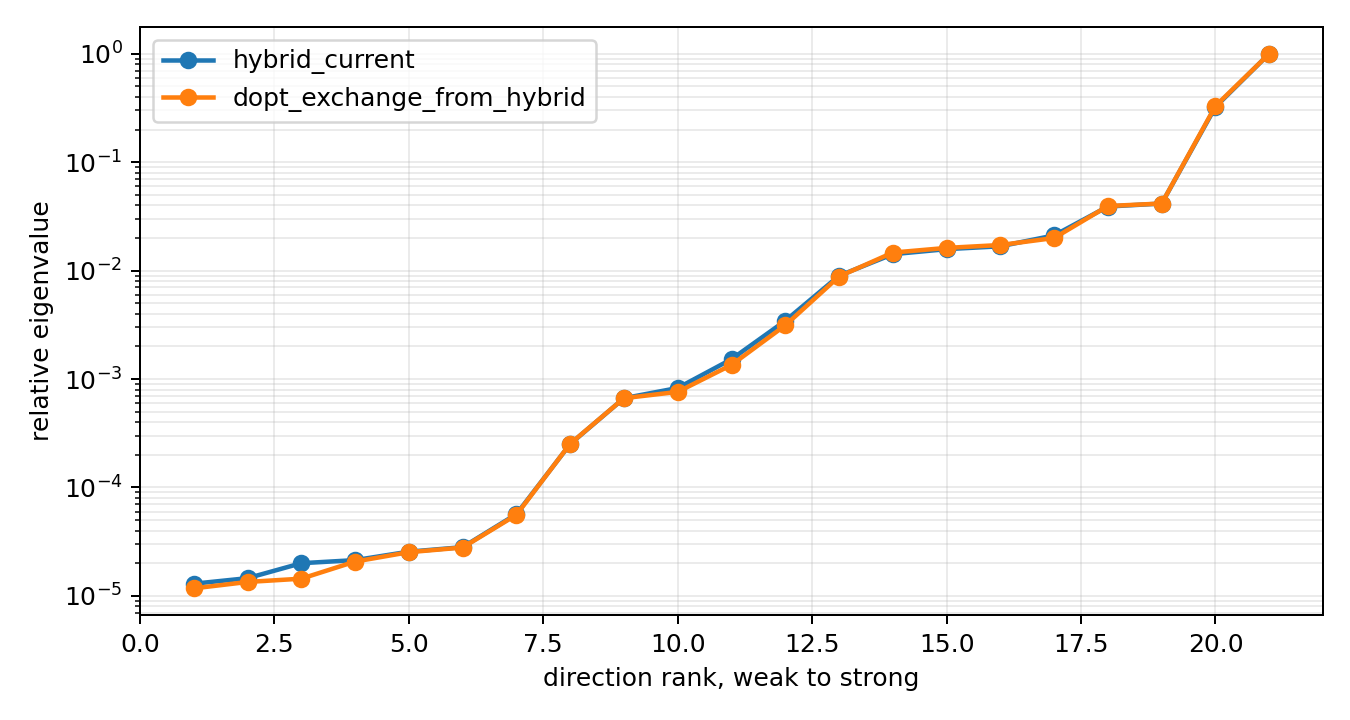

aroma_weak_eigendirection_loadings.png


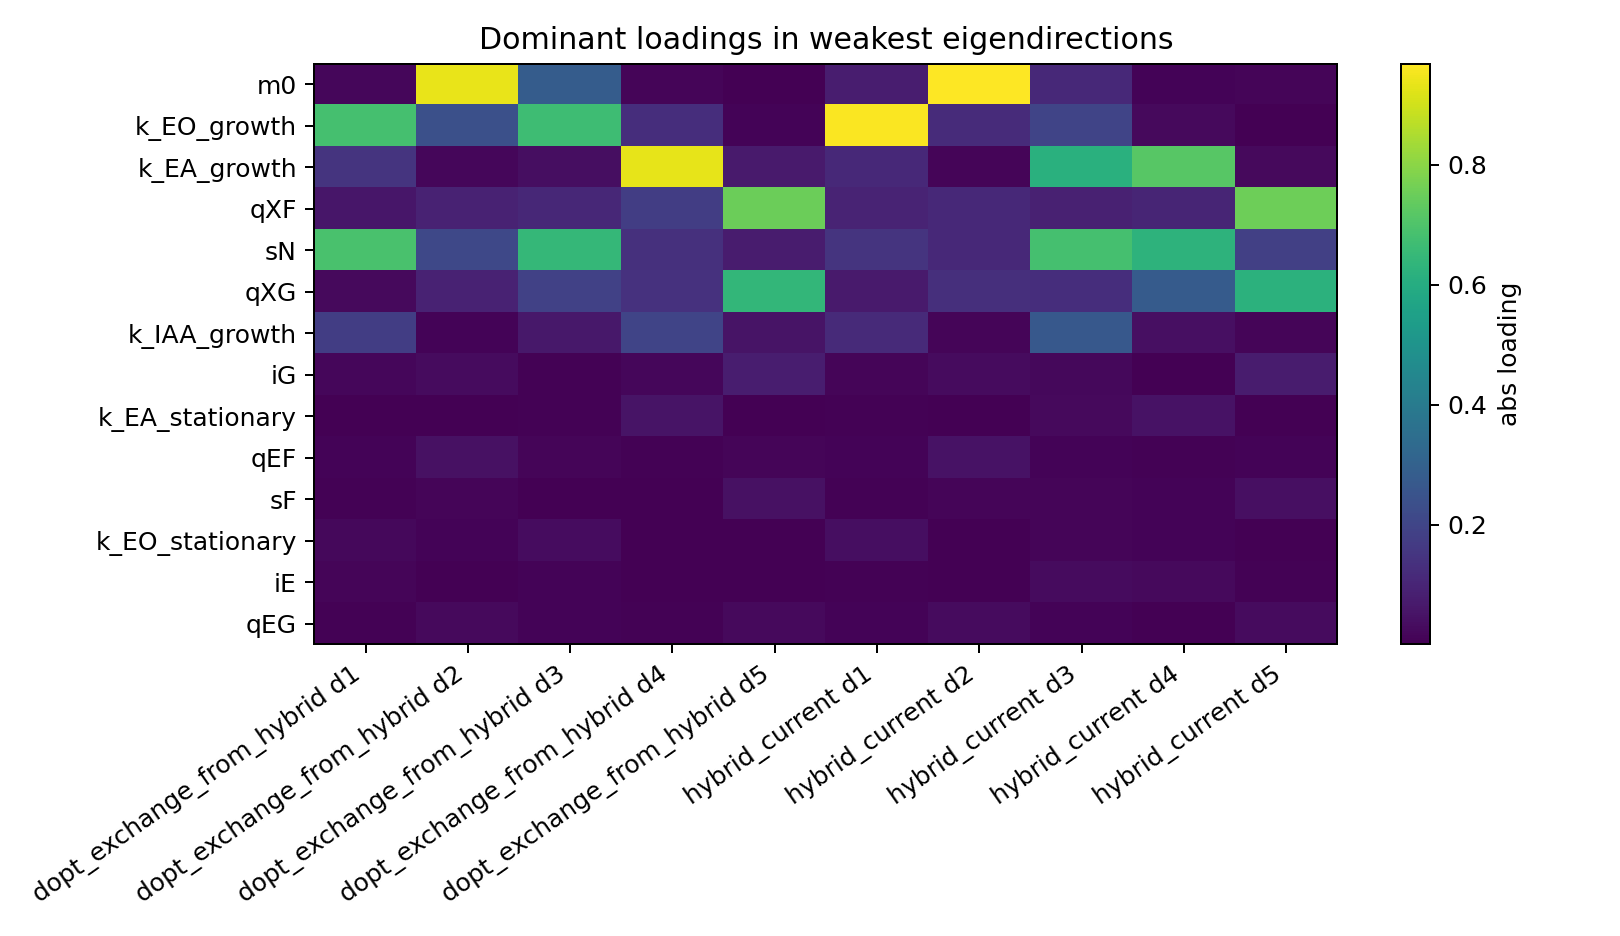

In [33]:
from IPython.display import Image, display
for image_name in ["aroma_eigen_spectrum.png", "aroma_weak_eigendirection_loadings.png"]:
    print(image_name)
    display(Image(filename=str(JOINT_RESULTS / image_name)))

### 17.1 Interpretation

The posterior FIM is numerically full rank for both the hybrid campaign and the D-opt exchange campaign. Therefore, there is no obvious structurally unexcited direction under the current local model and measurement plan.

The hybrid campaign is still preferable for robustness: it has a slightly larger weakest relative eigenvalue and a lower condition number than the D-opt exchange campaign. The weakest directions are not single-parameter failures; they are correlated fermentation-aroma combinations. In the hybrid design, the first weak directions involve `k_EO_growth`, `m0`, `sN`, `k_EA_growth`, and the sugar uptake pair `qXG/qXF`.

This supports the earlier conclusion: the design is usable, but not perfectly isotropic. It is robust enough as a model-based campaign proposal, while the most important validation risks remain nitrogen/growth coupling, maintenance/biomass behavior, and growth-phase aroma yields.

## 18. Operational calendar constraints and batch execution

The campaign design above was computed in relative fermentation time. The confirmed operational constraints are:

- Lab work is Monday-Friday.
- Manual sampling and manual additions should occur between 09:00 and 16:00.
- Up to four manual samples per fermentation can be taken in a single day.
- Temperature setpoints can be automatically programmed, so temperature changes can remain at nominal model times.
- Only one dosing channel among `N`, `G`, `F`, and `E` can be automated.
- The nine fermentations will be executed as three batches of three fermentations.

For the current planning assumption, batch 1 starts Monday 15 June 2026 at 08:00, batch 2 starts Monday 29 June 2026 at 08:00, and batch 3 starts Monday 13 July 2026 at 08:00.

The operational recommendation is to automate `E`. This is because the only large manual pulse shift in the selected design is the ethanol pulse of `combined_stress_long_horizon`; automating `N`, `G`, or `F` does not remove that conflict.

In [34]:
RUN_OPERATIONAL_SCHEDULE = False
RUN_BATCH_PRIORITIZATION = False
OPERATIONAL_SCRIPT = FERM / "run_operational_campaign_schedule.py"
BATCH_SCRIPT = FERM / "run_batch_prioritization.py"
OPERATIONAL_RESULTS = FERM / "results" / "operational_campaign_schedule"

if RUN_BATCH_PRIORITIZATION:
    subprocess.run([sys.executable, str(BATCH_SCRIPT)], cwd=str(ROOT), check=True)

if RUN_OPERATIONAL_SCHEDULE:
    subprocess.run([
        sys.executable,
        str(OPERATIONAL_SCRIPT),
        "--batch-mode", "recommended",
        "--temperature-mode", "automatic",
        "--automated-channel", "E",
        "--batch-starts", "2026-06-15 08:00;2026-06-29 08:00;2026-07-13 08:00",
    ], cwd=str(ROOT), check=True)

batch_sequence = pd.read_csv(OPERATIONAL_RESULTS / "recommended_batch_sequence_metrics.csv")
batch1_ranking = pd.read_csv(OPERATIONAL_RESULTS / "batch1_combo_ranking_selected9.csv")
automation_comparison = pd.read_csv(OPERATIONAL_RESULTS / "automation_channel_comparison.csv")
operational_load = pd.read_csv(OPERATIONAL_RESULTS / "operational_daily_load.csv")
operational_pulses = pd.read_csv(OPERATIONAL_RESULTS / "operational_pulse_schedule.csv")
operational_sampling = pd.read_csv(OPERATIONAL_RESULTS / "operational_sampling_schedule.csv")
operational_temperature = pd.read_csv(OPERATIONAL_RESULTS / "operational_temperature_schedule.csv")
batch_sequence[["batch", "batch_experiments", "n_experiments", "logdet", "mean_var_reduction", "worst_var_reduction", "sN_var_reduction", "condition_number"]]

,batch,batch_experiments,n_experiments,logdet,mean_var_reduction,worst_var_reduction,sN_var_reduction,condition_number
0,1,fructose_rich_iG_probe | low_temp_growth_separ...,3,129.708546,0.927167,0.650190,0.650190,86443.782221
1,2,cold_synthesis_hot_stripping | combined_stress...,6,149.394019,0.965031,0.730844,0.730844,100750.465374
2,3,high_biomass_low_N_maintenance | ethanol_initi...,9,155.980425,0.973679,0.768944,0.768944,77161.985209


In [35]:
automation_comparison

,automated_channel,large_manual_pulse_shifts,max_abs_manual_pulse_shift_h,max_total_manual_events_per_day,max_manual_samples_per_day,max_manual_pulses_per_day
0,none,1,16.0,15,12,3
1,N,1,16.0,14,12,3
2,G,1,16.0,15,12,3
3,F,1,16.0,15,12,3
4,E,0,8.0,15,12,3


In [36]:
batch1_ranking.head(10)[[
    "experiments", "hybrid_score", "logdet", "mean_var_reduction", "worst_var_reduction", "sN_var_reduction", "condition_number"
]]

,experiments,hybrid_score,logdet,mean_var_reduction,worst_var_reduction,sN_var_reduction,condition_number
0,fructose_rich_iG_probe | low_temp_growth_separ...,134.399177,138.549783,0.930722,0.503613,0.503613,128675.405383
1,fructose_rich_iG_probe | combined_stress_long_...,134.268452,139.452928,0.931759,0.463103,0.463103,144648.893877
2,fructose_rich_iG_probe | cold_synthesis_hot_st...,132.791713,135.930811,0.931126,0.541207,0.541207,113238.579884
3,fructose_rich_iG_probe | cold_synthesis_hot_st...,132.777994,137.437707,0.933166,0.505224,0.505224,170745.361701
4,fructose_rich_iG_probe | cold_synthesis_hot_st...,132.754498,138.174263,0.924990,0.513852,0.513852,261281.834915
5,fructose_rich_iG_probe | glucose_rich_growth_y...,131.659176,136.385799,0.929839,0.488660,0.488660,147135.335960
6,fructose_rich_iG_probe | cold_synthesis_hot_st...,131.636561,135.656673,0.924574,0.535817,0.535817,161311.194885
7,fructose_rich_iG_probe | low_temp_growth_separ...,131.563788,135.449399,0.929423,0.515767,0.515767,126448.838199
8,low_temp_growth_separation_plus_co2 | combined...,131.408173,135.283114,0.929529,0.497819,0.497819,105167.148550
9,fructose_rich_iG_probe | combined_stress_long_...,130.961735,134.414006,0.925281,0.582312,0.582312,194010.050656


In [37]:
operational_load

,date,manual_samples,manual_pulses,manual_temperature_changes,total_manual_events
0,2026-06-15,12,0,0,12
1,2026-06-16,12,2,0,14
2,2026-06-17,12,3,0,15
3,2026-06-18,12,2,0,14
4,2026-06-19,6,0,0,6
5,2026-06-22,3,0,0,3
6,2026-06-23,1,0,0,1
7,2026-06-29,12,0,0,12
8,2026-06-30,12,1,0,13
9,2026-07-01,12,2,0,14


In [38]:
operational_pulses.sort_values("shift_h")[[
    "batch", "candidate", "channel", "amount", "nominal_time_h", "adjusted_time_h", "shift_h", "shift_class", "adjustment_rule", "adjusted_calendar_time"
]]

,batch,candidate,channel,amount,nominal_time_h,adjusted_time_h,shift_h,shift_class,adjustment_rule,adjusted_calendar_time
8,1,low_temp_growth_separation_plus_co2,N,0.060,64.0,56.0,-8.0,moderate,nearest_workday_09_11_14_or_16,2026-06-17 16:00:00
18,2,glucose_rich_growth_yield,N,0.060,36.0,32.0,-4.0,minor,nearest_workday_09_11_14_or_16,2026-06-30 16:00:00
10,2,combined_stress_long_horizon,N,0.050,60.0,56.0,-4.0,minor,nearest_workday_09_11_14_or_16,2026-07-01 16:00:00
0,1,fructose_rich_iG_probe,N,0.080,0.0,0.0,0.0,minor,initial_formulation_or_inoculation,2026-06-15 08:00:00
23,3,ethanol_initial_challenge,N,0.070,0.0,0.0,0.0,minor,initial_formulation_or_inoculation,2026-07-13 08:00:00
17,2,glucose_rich_growth_yield,N,0.080,0.0,0.0,0.0,minor,initial_formulation_or_inoculation,2026-06-29 08:00:00
25,3,glucose_pulse_after_N_depletion,N,0.035,0.0,0.0,0.0,minor,initial_formulation_or_inoculation,2026-07-13 08:00:00
9,2,combined_stress_long_horizon,N,0.050,0.0,0.0,0.0,minor,initial_formulation_or_inoculation,2026-06-29 08:00:00
13,2,combined_stress_long_horizon,E,20.000,120.0,120.0,0.0,minor,automated_E_nominal_time,2026-07-04 08:00:00
6,1,low_temp_growth_separation_plus_co2,N,0.070,0.0,0.0,0.0,minor,initial_formulation_or_inoculation,2026-06-15 08:00:00


In [39]:
(
    operational_sampling
    .groupby(["batch", "candidate", "date"])
    .size()
    .rename("n_samples_day")
    .reset_index()
    .groupby(["batch", "candidate"])
    .agg(
        max_samples_single_day=("n_samples_day", "max"),
        n_sampling_days=("date", "nunique"),
    )
    .reset_index()
)

,batch,candidate,max_samples_single_day,n_sampling_days
0,1,fructose_rich_iG_probe,4,7
1,1,low_temp_growth_separation_plus_co2,4,6
2,1,yan_saturation_scan,4,6
3,2,cold_synthesis_hot_stripping,4,7
4,2,combined_stress_long_horizon,4,9
5,2,glucose_rich_growth_yield,4,6
6,3,ethanol_initial_challenge,4,7
7,3,glucose_pulse_after_N_depletion,4,7
8,3,high_biomass_low_N_maintenance,4,6


In [40]:
(
    operational_sampling
    .groupby(["batch", "candidate"])
    .agg(
        start_datetime=("start_datetime", "first"),
        nominal_horizon_h=("nominal_horizon_h", "first"),
        operational_final_h=("operational_final_h", "first"),
        n_manual_samples=("sample_time_h", "count"),
        final_calendar_time=("calendar_time", "last"),
    )
    .reset_index()
)

,batch,candidate,start_datetime,nominal_horizon_h,operational_final_h,n_manual_samples,final_calendar_time
0,1,fructose_rich_iG_probe,2026-06-15 08:00:00,192.0,193.0,20,2026-06-23 09:00:00
1,1,low_temp_growth_separation_plus_co2,2026-06-15 08:00:00,168.0,169.0,19,2026-06-22 09:00:00
2,1,yan_saturation_scan,2026-06-15 08:00:00,144.0,169.0,19,2026-06-22 09:00:00
3,2,cold_synthesis_hot_stripping,2026-06-29 08:00:00,192.0,193.0,20,2026-07-07 09:00:00
4,2,combined_stress_long_horizon,2026-06-29 08:00:00,240.0,241.0,22,2026-07-09 09:00:00
5,2,glucose_rich_growth_yield,2026-06-29 08:00:00,168.0,169.0,19,2026-07-06 09:00:00
6,3,ethanol_initial_challenge,2026-07-13 08:00:00,192.0,193.0,20,2026-07-21 09:00:00
7,3,glucose_pulse_after_N_depletion,2026-07-13 08:00:00,192.0,193.0,20,2026-07-21 09:00:00
8,3,high_biomass_low_N_maintenance,2026-07-13 08:00:00,168.0,169.0,19,2026-07-20 09:00:00


operational_daily_load.png


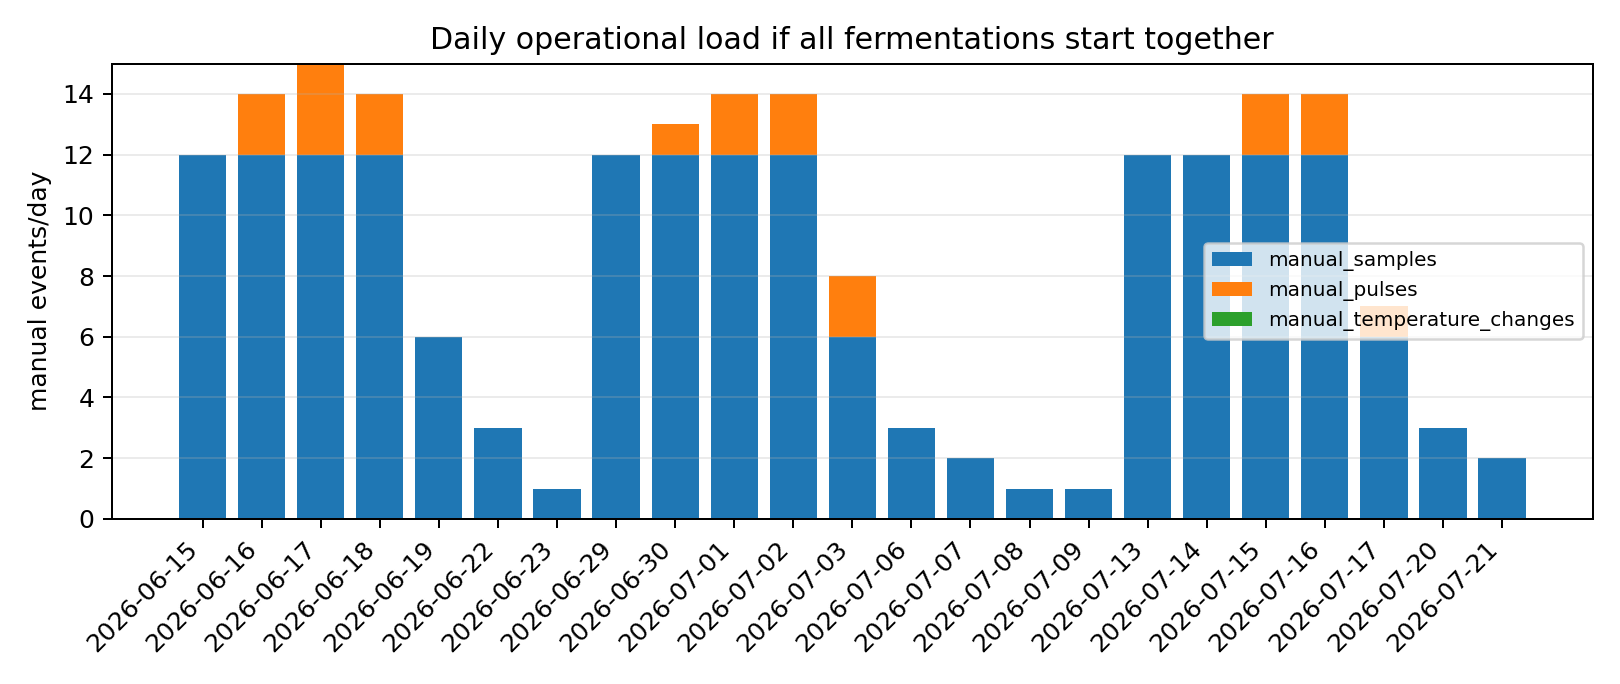

operational_sampling_pulse_timeline.png


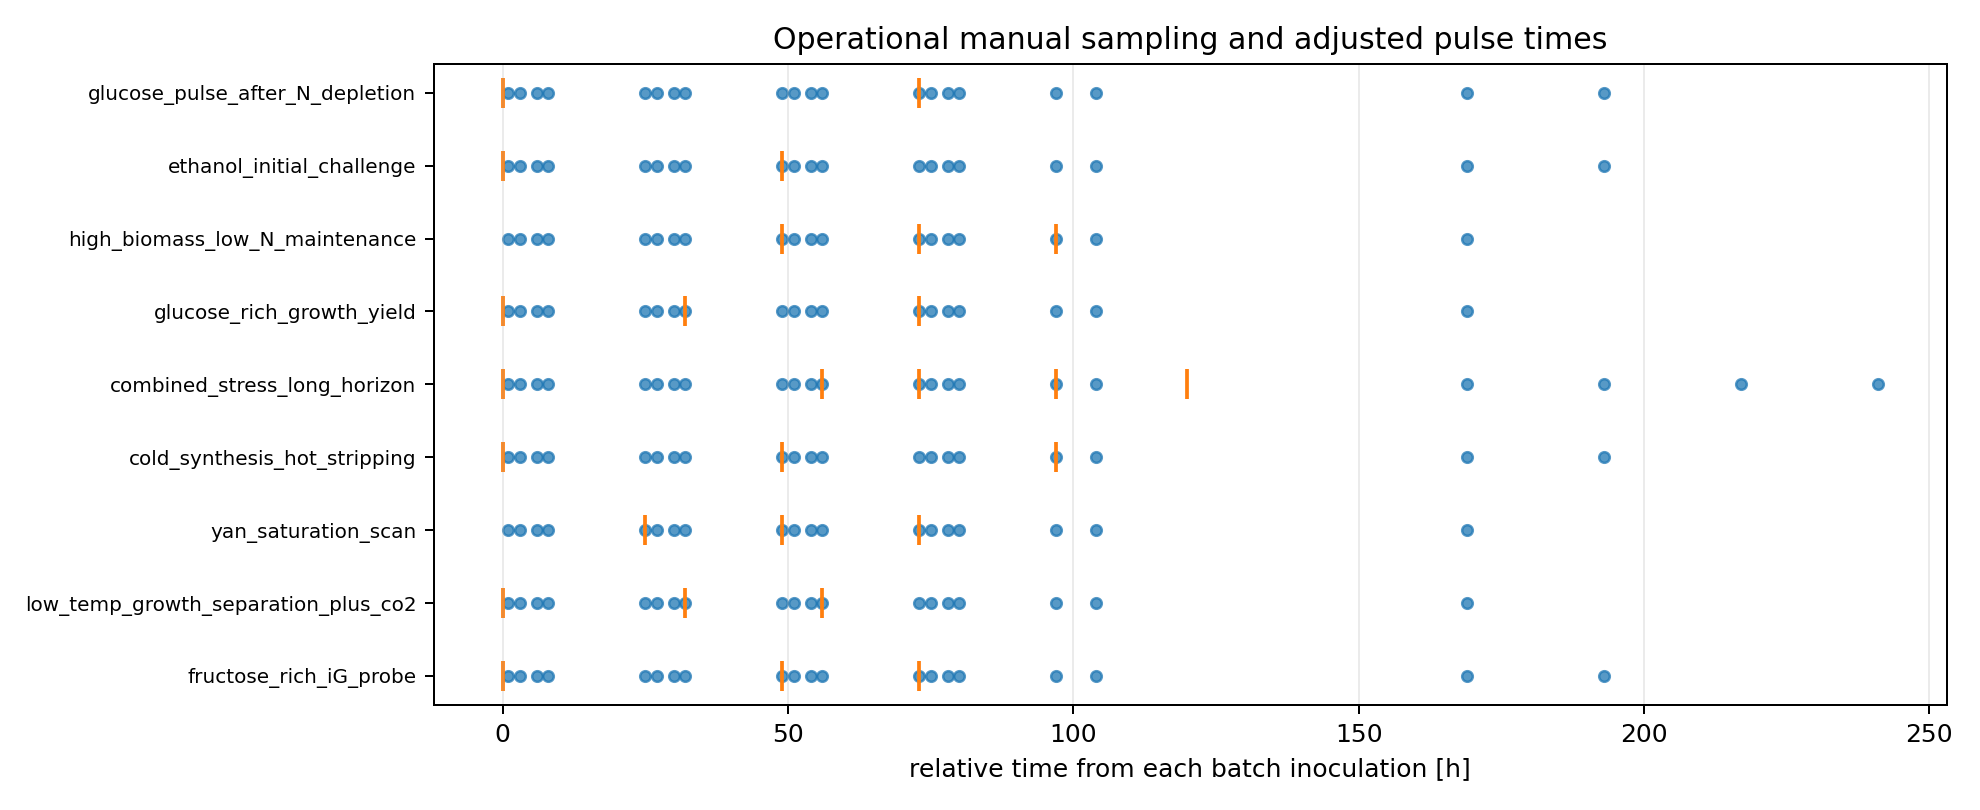

In [41]:
for image_name in ["operational_daily_load.png", "operational_sampling_pulse_timeline.png"]:
    print(image_name)
    display(Image(filename=str(OPERATIONAL_RESULTS / image_name)))

### 18.1 Batch-order interpretation

It is technically useful to prioritize a first batch rather than execute the nine fermentations as one closed block. The first three experiments should act as a model-discrimination and prior-updating batch.

The recommended first batch is:

1. `fructose_rich_iG_probe`
2. `low_temp_growth_separation_plus_co2`
3. `yan_saturation_scan`

This is not the maximum-logdet first batch, but it is the better adaptive first batch because it includes `yan_saturation_scan`, which directly probes the `sN/qN` bottleneck. After this first batch, recalibrate the model, inspect curve quality, update the FIM/prior, and decide whether batch 2 remains unchanged.

Recommended batch 2:

1. `cold_synthesis_hot_stripping`
2. `combined_stress_long_horizon`
3. `glucose_rich_growth_yield`

Recommended batch 3:

1. `high_biomass_low_N_maintenance`
2. `ethanol_initial_challenge`
3. `glucose_pulse_after_N_depletion`

With `E` automated, there are no large pulse shifts left. The remaining non-automated pulses have at most moderate shifts under the 09:00-16:00 action window. The sampling plan uses up to four samples per fermentation per day in the early informative window, then reduces frequency later.